# Dataset 1: Daily Activities and Sports Dataset

# 0. Fuentes

La base de datos se puede obtener en el siguiente enlace:

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace:

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

Las actividaes son:

The 19 activities are: 

- sitting (A1), 
- standing (A2), 
- lying on back and on right side (A3 and A4), 
- ascending and descending stairs (A5 and A6), 
- standing in an elevator still (A7) 
- and moving around in an elevator (A8), 
- walking in a parking lot (A9), 
- walking on a treadmill with a speed of 4 km/h (in flat and 15 deg inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12), 
- exercising on a stepper (A13), 
- exercising on a cross trainer (A14), 
- cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17), 
- jumping (A18), 
- and playing basketball (A19).

# 1. Primera entrega: EDA y pre-procesamiento

## 1.1.    Cargar los datos

Llamamos a las librerías para importar los datos:

- pandas:
- os: 

In [1]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

In [3]:
from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "dataset/dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

## 1.2. Dimensiones y primeras 5 filas

Dimensiones

In [7]:
dsa_df.shape

(1140000, 48)

Primeras 5 filas

In [9]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 1.3. Identifica y elimina los datos ausentes

In [11]:
dsa_df.isnull().sum()

T_xacc            0
T_yacc            0
T_zacc            0
T_xgyro           0
T_ygyro           0
T_zgyro           0
T_xmag            0
T_ymag            0
T_zmag            0
RA_xacc           0
RA_yacc           0
RA_zacc           0
RA_xgyro          0
RA_ygyro          0
RA_zgyro          0
RA_xmag           0
RA_ymag           0
RA_zmag           0
LA_xacc           0
LA_yacc           0
LA_zacc           0
LA_xgyro          0
LA_ygyro          0
LA_zgyro          0
LA_xmag           0
LA_ymag           0
LA_zmag           0
RL_xacc           0
RL_yacc           0
RL_zacc           0
RL_xgyro          0
RL_ygyro          0
RL_zgyro          0
RL_xmag           0
RL_ymag           0
RL_zmag           0
LL_xacc           0
LL_yacc           0
LL_zacc           0
LL_xgyro          0
LL_ygyro          0
LL_zgyro          0
LL_xmag           0
LL_ymag           0
LL_zmag           0
activity_label    0
person_id         0
segment           0
dtype: int64

## 1.4. Presenta los tipos de datos de cada atributo de cada base de datos

In [13]:
dsa_df.dtypes

T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag           float64
LL_xacc           float64
LL_yacc           float64
LL_zacc     

## 1.5. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos

In [5]:
pd.set_option('display.max_columns', None)  
dsa_df.describe().T

,count,mean,std,min,25%,50%,75%,max
T_xacc,1140000.000,7.766,5.638,-99.715,6.907,8.830,9.691,93.694
T_yacc,1140000.000,-0.811,2.623,-49.941,-1.510,-0.390,0.414,41.013
T_zacc,1140000.000,2.769,3.538,-62.664,0.900,2.704,4.405,120.530
T_xgyro,1140000.000,-0.003,0.794,-27.851,-0.163,0.000,0.165,27.671
T_ygyro,1140000.000,0.014,0.691,-23.598,-0.102,0.017,0.131,14.379
T_zgyro,1140000.000,-0.003,0.311,-12.067,-0.097,-0.003,0.089,19.262
T_xmag,1140000.000,-0.598,0.356,-1.423,-0.825,-0.690,-0.493,1.022
T_ymag,1140000.000,0.062,0.340,-1.023,-0.179,0.022,0.282,1.031
T_zmag,1140000.000,-0.273,0.373,-1.081,-0.602,-0.309,0.041,0.963
RA_xacc,1140000.000,4.261,5.821,-49.535,0.095,4.143,8.505,71.652


## 1.6. Presenta la distribución de clases de cada base de datos

Por convención a las actividaes se les asigna un label alfanumérico. A continuación se presenta la correspondencia entre estos y las actividades que representan:

- sitting (A1),
- standing (A2),
- lying on back and on right side (A3 and A4),
- ascending and descending stairs (A5 and A6),
- standing in an elevator still (A7) and moving around (A8),
- walking in a parking lot (A9),
- walking on a treadmill with a speed of 4 km/h (in flat and 151 inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12),
- exercising on a stepper (A13),
- exercising on a cross trainer (A14), cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17),
- jumping (A18),
- playing basketball (A19).

In [17]:
dsa_class_distribution = dsa_df['activity_label'].value_counts()
dsa_class_distribution

activity_label
a01    60000
a11    60000
a18    60000
a17    60000
a16    60000
a15    60000
a14    60000
a13    60000
a12    60000
a10    60000
a02    60000
a09    60000
a08    60000
a07    60000
a06    60000
a05    60000
a04    60000
a03    60000
a19    60000
Name: count, dtype: int64

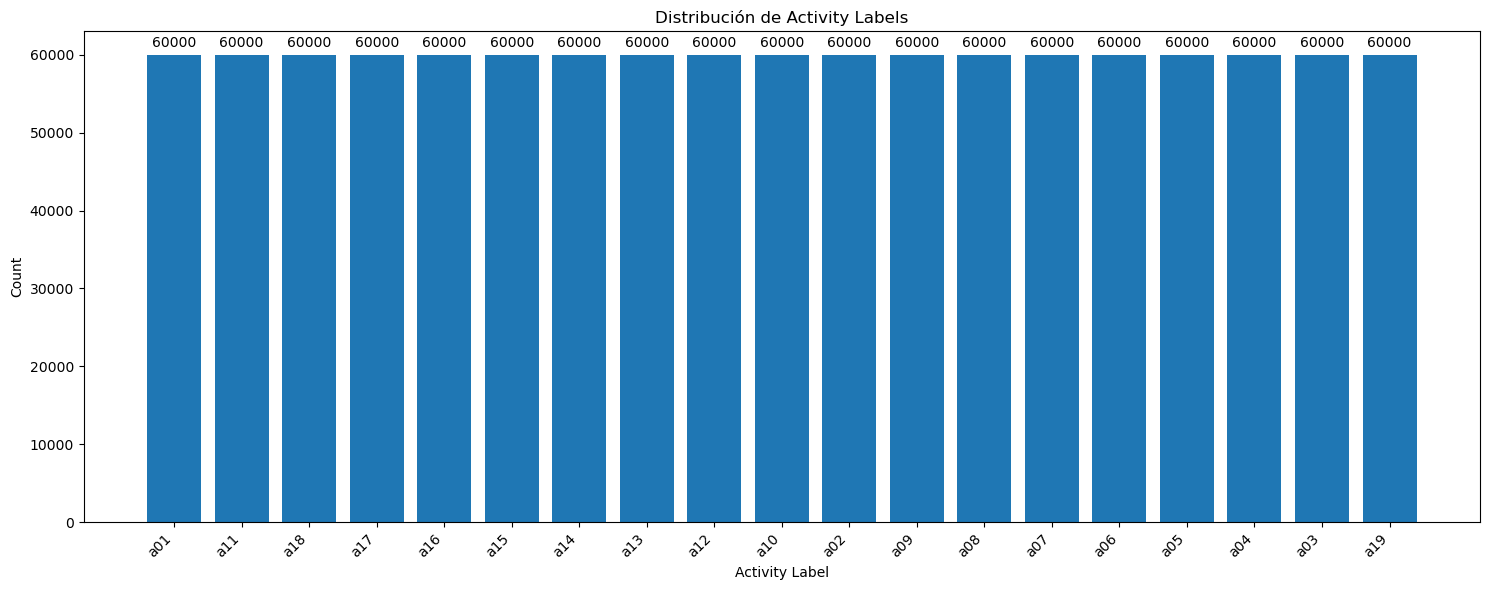

In [7]:
import matplotlib.pyplot as plt

dsa_class_distribution = dsa_df['activity_label'].value_counts()

plt.figure(figsize=(15, 6))
bars = plt.bar(dsa_class_distribution.index, dsa_class_distribution.values)

plt.xlabel('Activity Label')
plt.ylabel('Count')
plt.title('Distribución de Activity Labels')

# Agregar la cantidad exacta en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height * 1.01, f'{int(height)}', ha='center', va='bottom')

# Rotar etiquetas del eje X y ajustar el tamaño de la fuente
plt.xticks(rotation=45, ha='right', fontsize=10)

# Ajustar los márgenes para que las etiquetas no se recorten
plt.subplots_adjust(bottom=0.25)

plt.tight_layout()
plt.show()


## 1.7. Presenta la correlación entre atributos de cada base de datos

In [5]:
non_sensor_columns = ["activity_label", "person_id", "segment"]

only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

dsa_corr_matrix = only_sensor_columns.iloc[:, :].corr(method = "pearson")
dsa_corr_matrix

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
T_xacc,1.000,0.053,-0.055,-0.027,-0.069,0.003,-0.591,-0.185,0.152,0.364,...,-0.177,-0.593,0.237,-0.230,-0.017,0.006,0.003,0.228,0.018,0.172
T_yacc,0.053,1.000,0.067,-0.118,-0.012,-0.038,-0.134,-0.460,-0.155,-0.071,...,-0.299,-0.090,-0.069,-0.514,-0.021,-0.044,0.173,0.126,0.206,0.328
T_zacc,-0.055,0.067,1.000,0.007,-0.079,0.011,0.339,-0.040,-0.261,-0.044,...,-0.027,0.021,-0.094,-0.004,0.026,-0.036,0.029,-0.152,0.019,0.038
T_xgyro,-0.027,-0.118,0.007,1.000,0.056,-0.013,0.002,0.010,-0.004,-0.014,...,0.008,0.044,0.062,0.058,-0.009,0.084,-0.309,-0.032,0.026,-0.006
T_ygyro,-0.069,-0.012,-0.079,0.056,1.000,0.043,0.003,-0.003,-0.001,0.026,...,-0.001,0.064,-0.069,0.013,0.024,-0.069,0.098,0.008,-0.009,0.004
T_zgyro,0.003,-0.038,0.011,-0.013,0.043,1.000,-0.001,0.025,-0.000,0.043,...,-0.004,-0.040,-0.028,-0.014,-0.106,-0.065,-0.036,0.053,-0.077,0.006
T_xmag,-0.591,-0.134,0.339,0.002,0.003,-0.001,1.000,0.237,-0.196,-0.148,...,0.211,0.269,-0.078,0.257,0.010,-0.030,-0.009,-0.404,-0.034,-0.226
T_ymag,-0.185,-0.460,-0.040,0.010,-0.003,0.025,0.237,1.000,-0.001,0.003,...,0.825,0.067,0.029,0.378,-0.003,0.006,-0.050,0.011,0.020,-0.852
T_zmag,0.152,-0.155,-0.261,-0.004,-0.001,-0.000,-0.196,-0.001,1.000,0.186,...,-0.047,0.003,0.057,0.073,0.010,-0.031,0.008,0.101,-0.612,-0.017
RA_xacc,0.364,-0.071,-0.044,-0.014,0.026,0.043,-0.148,0.003,0.186,1.000,...,0.008,-0.414,0.267,-0.027,-0.022,0.013,-0.037,0.302,-0.311,0.023


## 1.8. Presenta el histograma de los atributos de cada base de datos

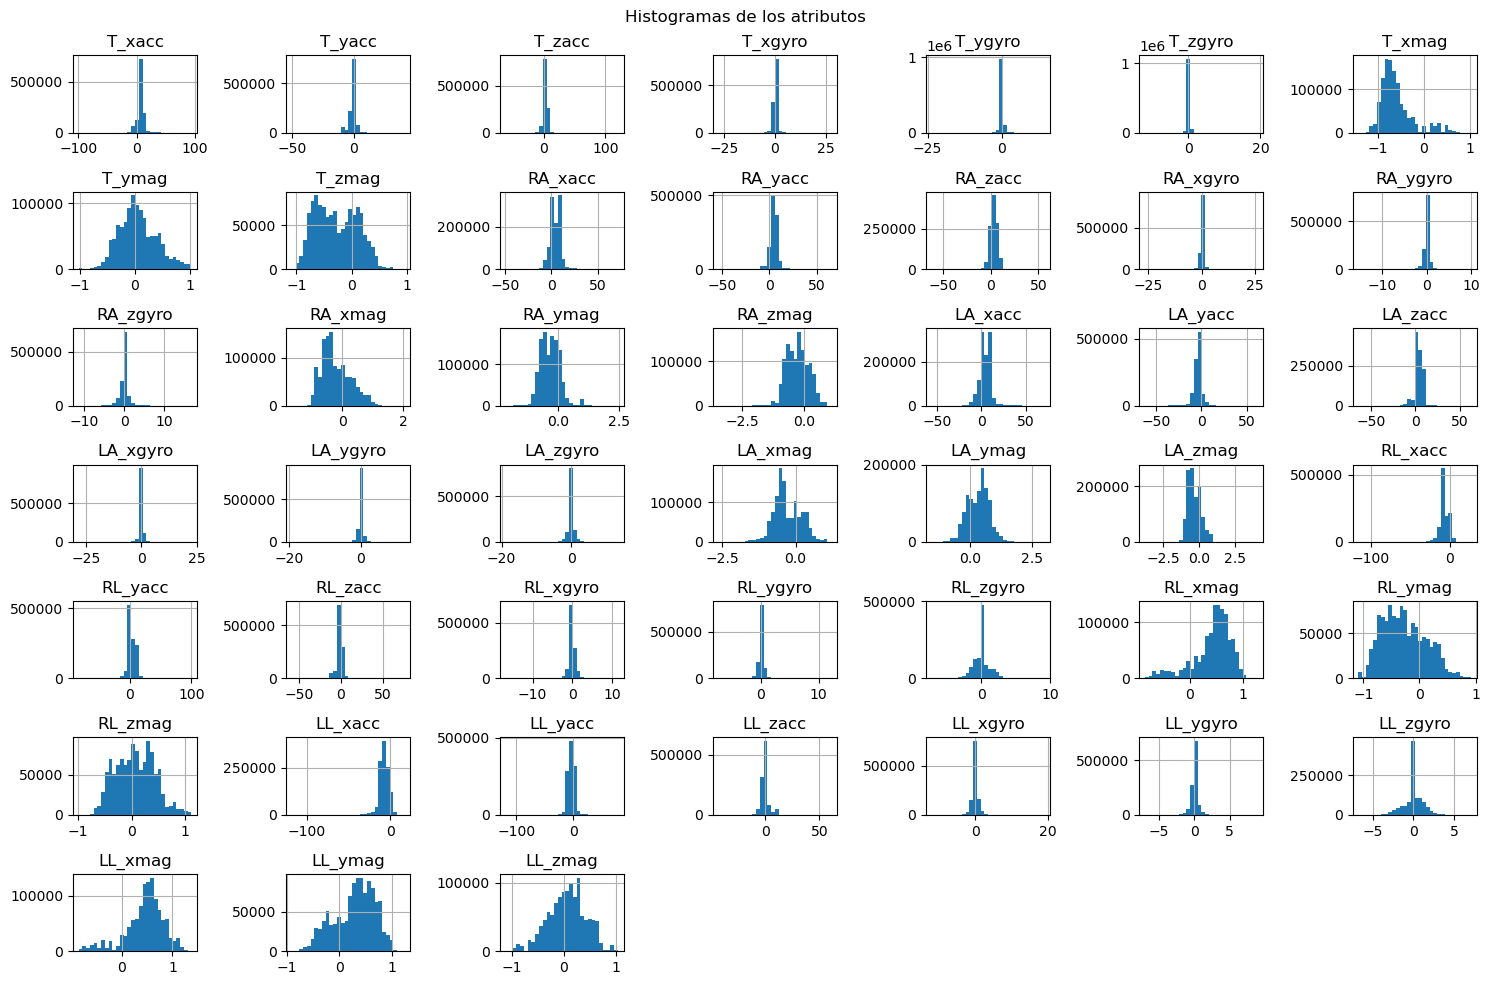

In [173]:
import matplotlib.pyplot as plt

# Crear el histograma
only_sensor_columns.hist(bins=30, figsize=(15, 10))

# Configurar los límites y el título
plt.xlim(-10, 10)
plt.suptitle("Histogramas de los atributos")

# Ajustar el diseño
plt.tight_layout()

# Guardar la imagen en 4K (3840x2160 píxeles, aprox. dpi=300)
plt.savefig("histogramas_4k.png", dpi=300, bbox_inches='tight')

# Mostrar la imagen en pantalla
plt.show()


## 1.9. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos

KeyboardInterrupt: 

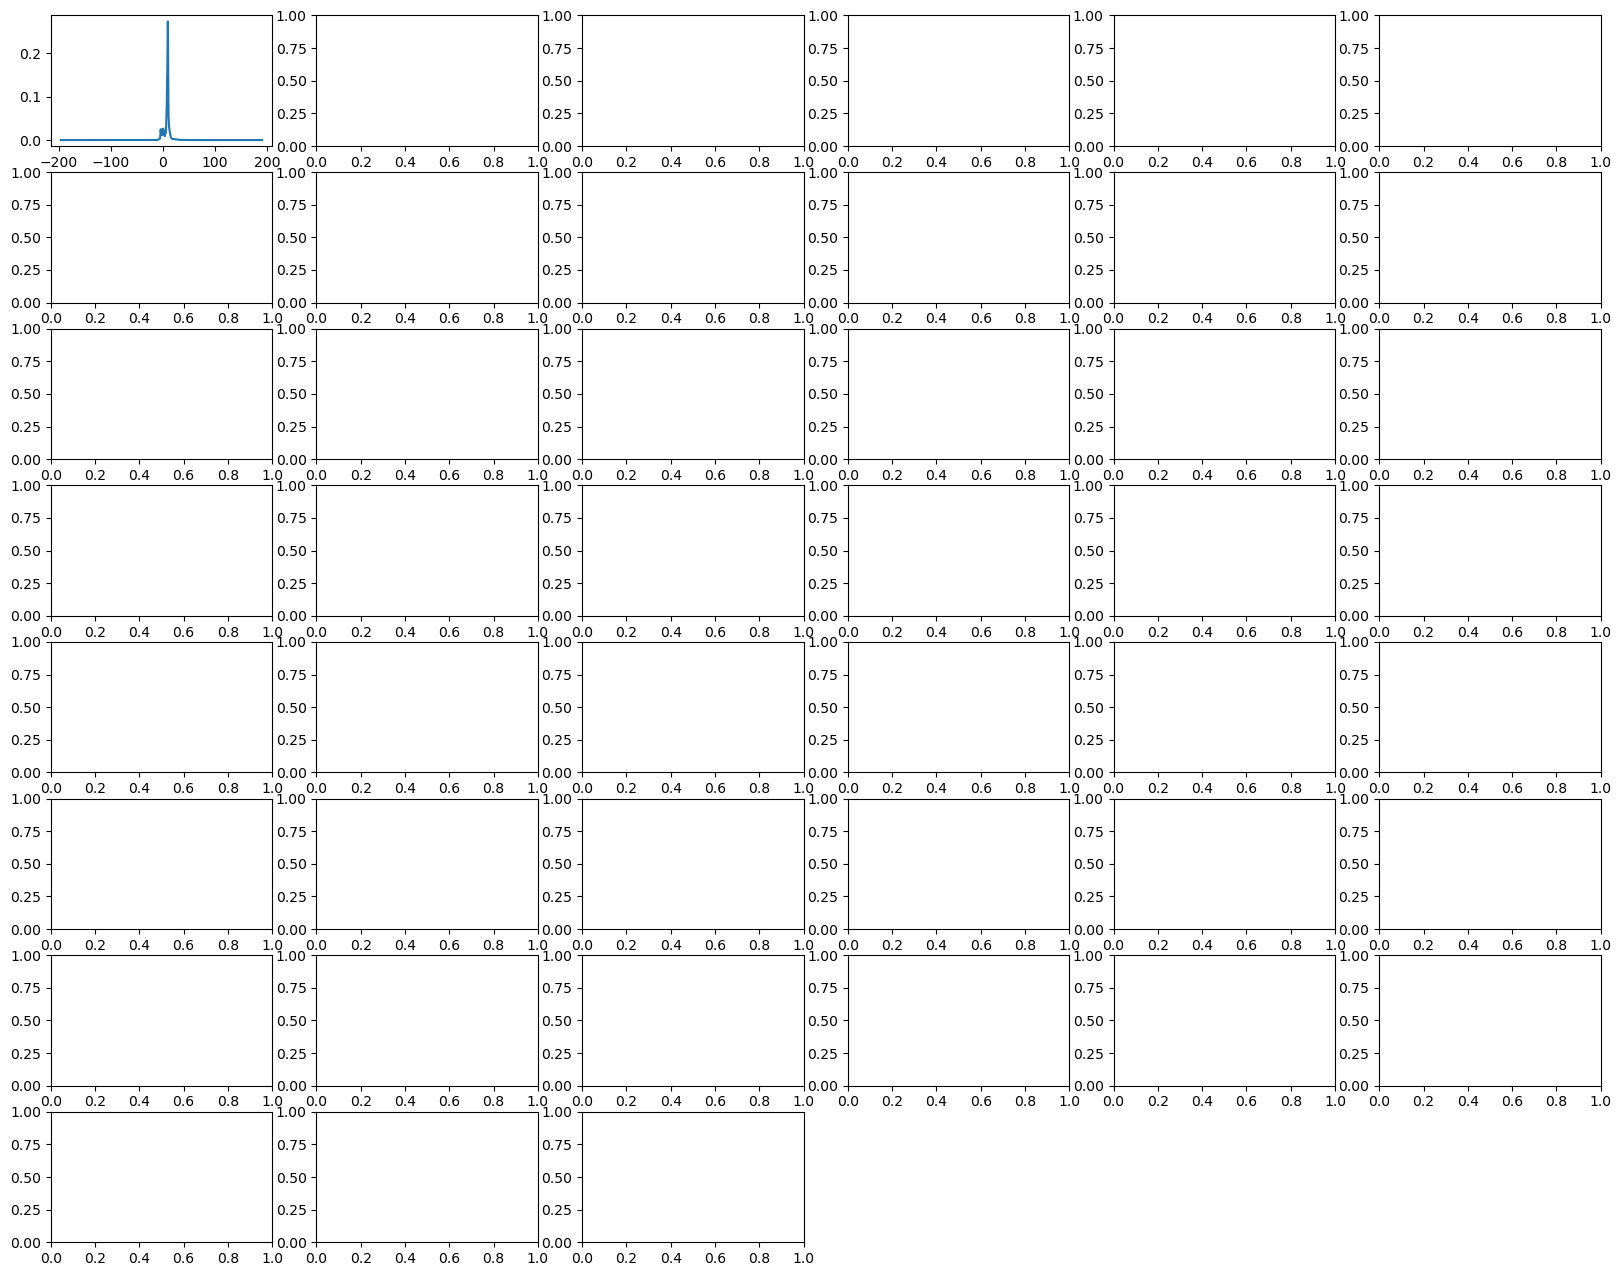

In [57]:
only_sensor_columns.plot(kind='density', subplots=True, layout=(10, 6), figsize=(20, 20), sharex=False)


plt.suptitle("Diagramas de Densidad de los Atributos", fontsize=16)
plt.tight_layout()
plt.show()

## 1.10. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos

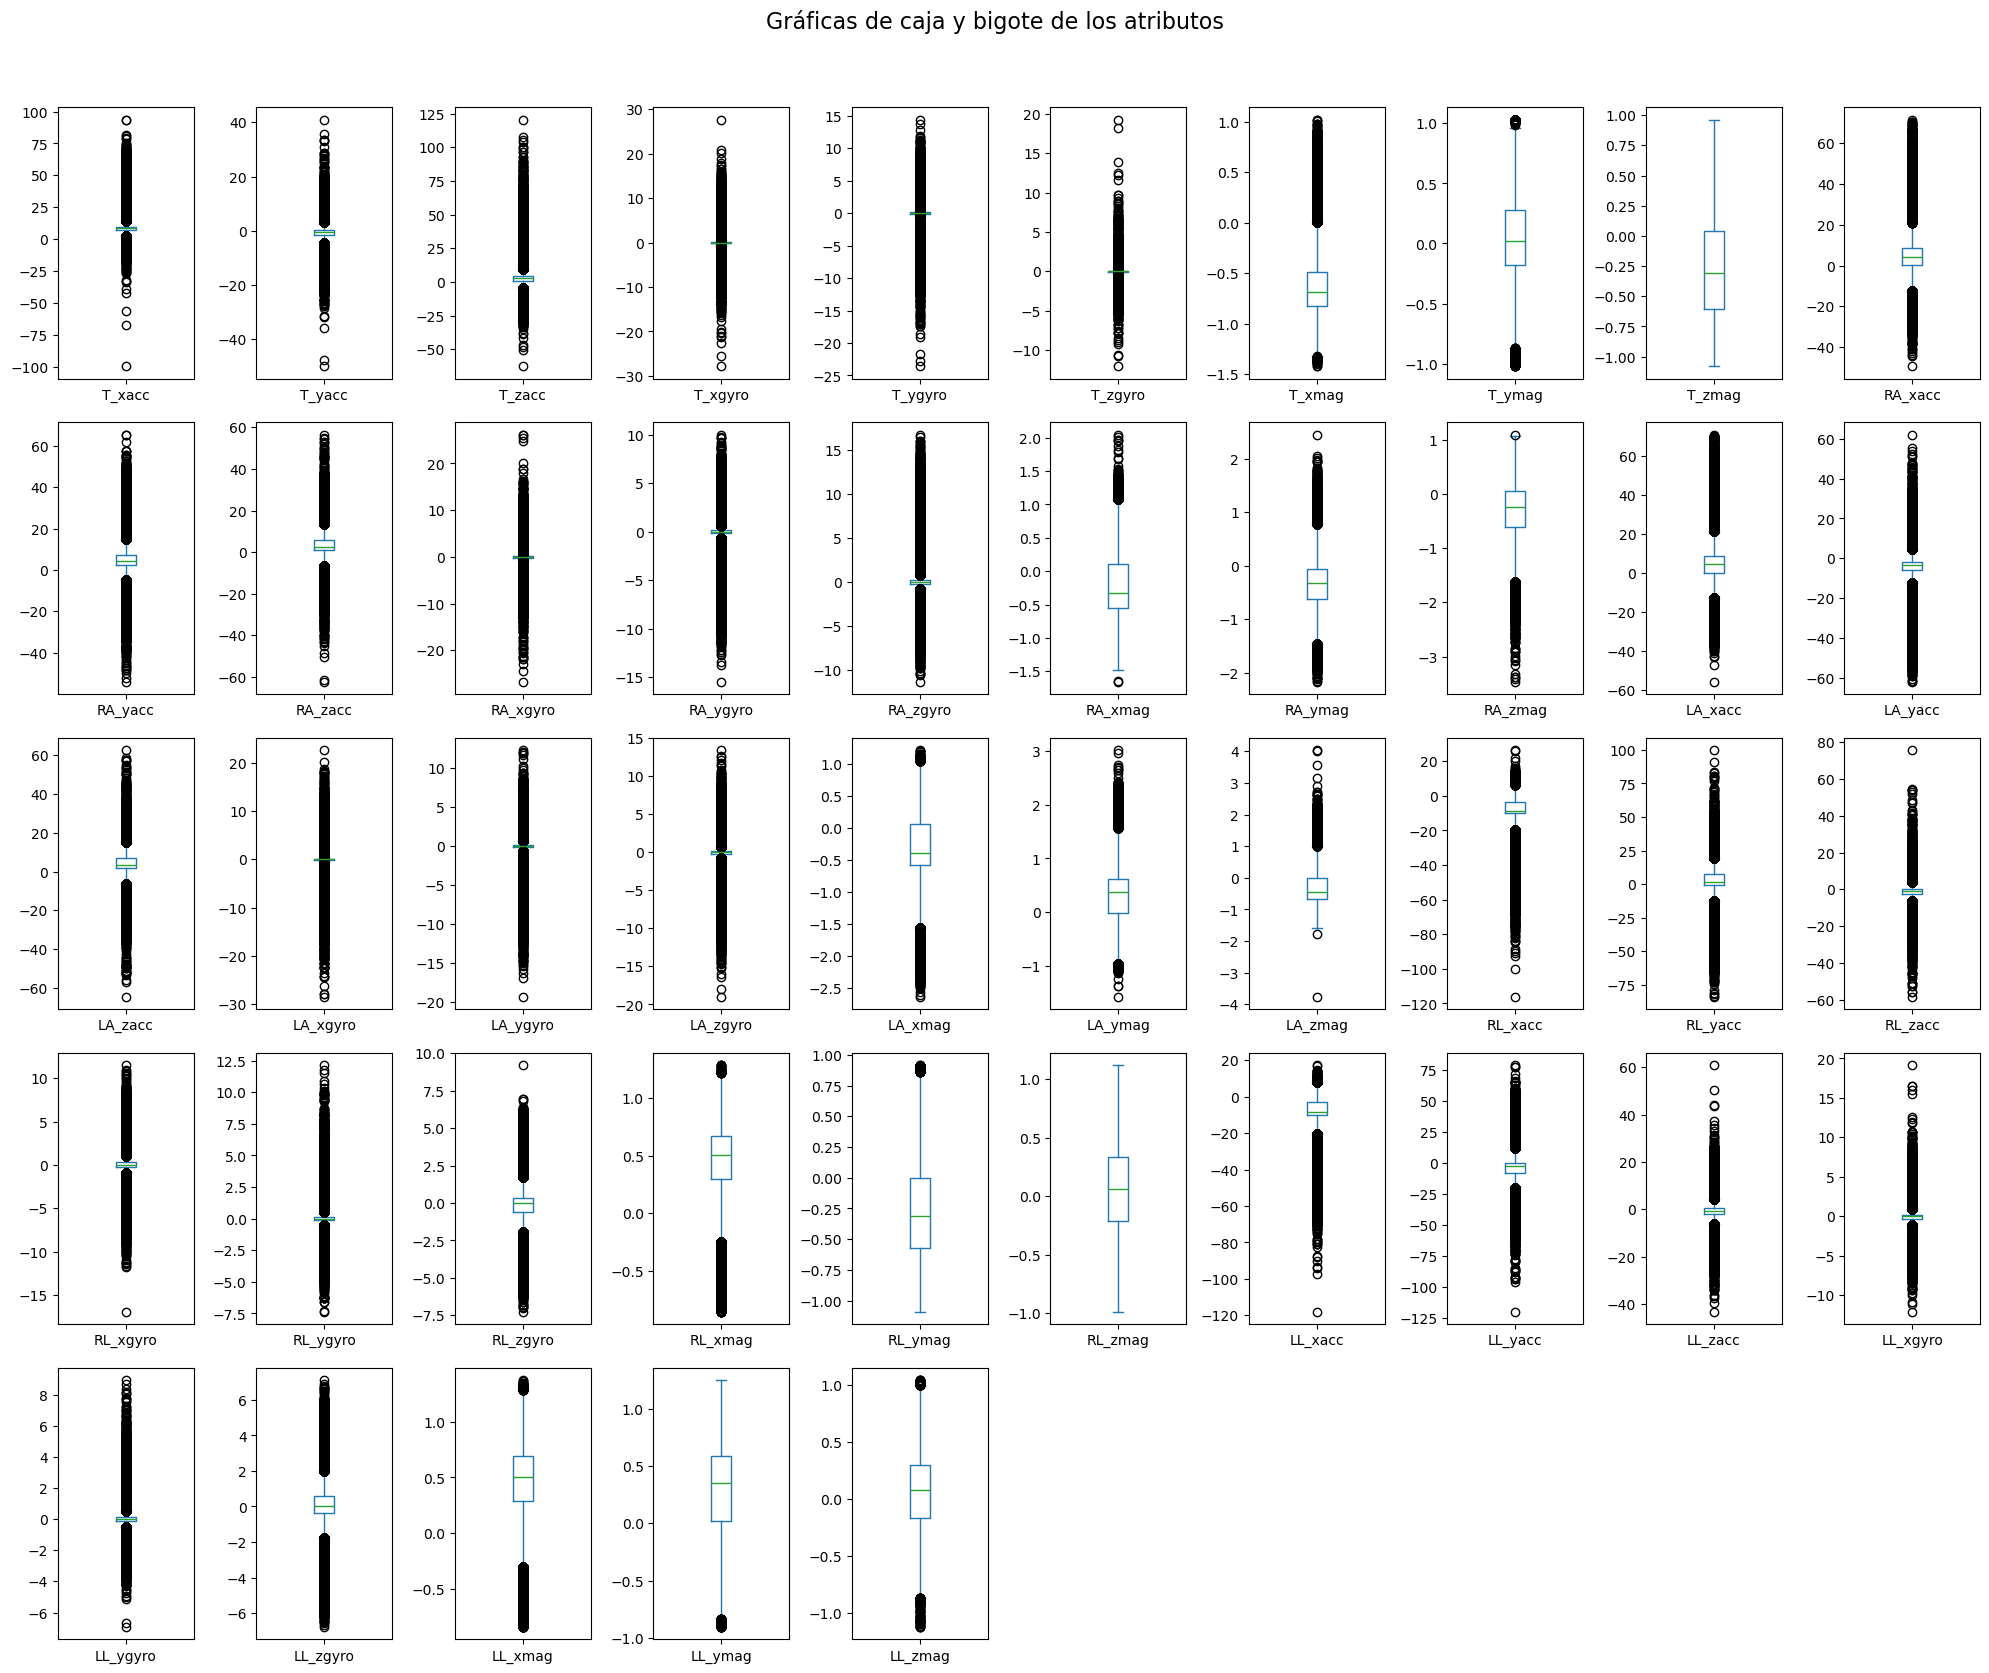

In [175]:
import matplotlib.pyplot as plt

# Crear las gráficas de caja y bigote
only_sensor_columns.plot(kind='box', subplots=True, layout=(6, 10), figsize=(20, 20), sharex=False)

# Configurar el título
plt.suptitle("Gráficas de caja y bigote de los atributos", fontsize=16)

# Ajustar el diseño para que no se sobrepongan los elementos
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar la imagen en alta resolución (por ejemplo, 300 DPI)
plt.savefig("boxplots_4k.png", dpi=300, bbox_inches='tight')

# Mostrar la gráfica en pantalla
plt.show()

## 1.11. Genera la matriz de correlación de los atributos para cada una de las bases de datos

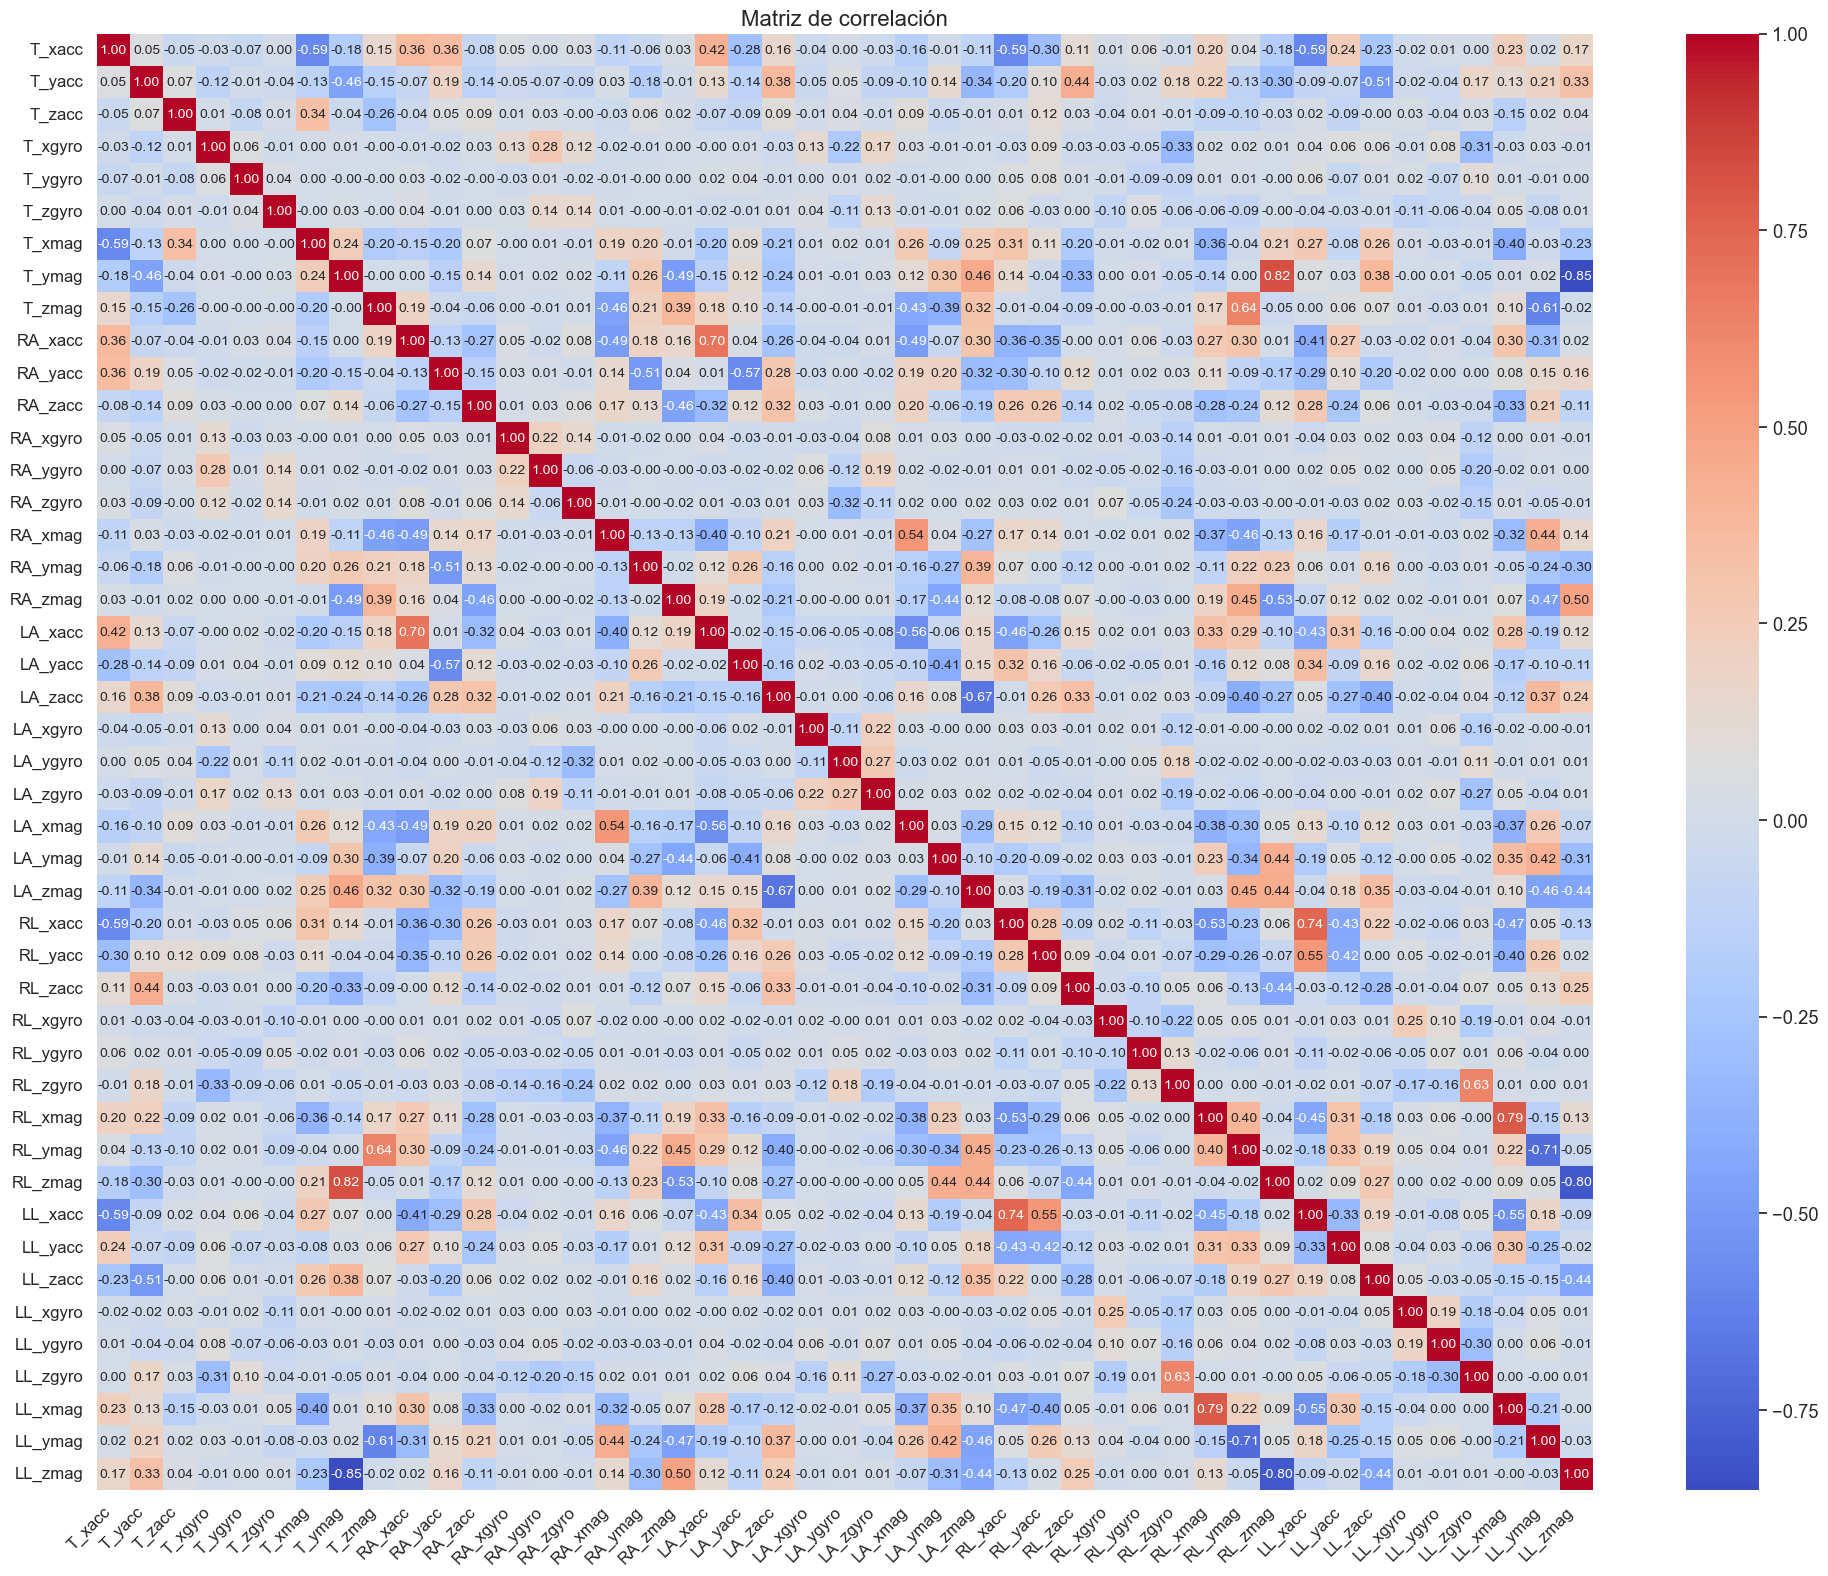

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.2)

plt.figure(figsize=(20, 16))  

sns.heatmap(
    dsa_corr_matrix, 
    annot=True,        # Show numerical values
    fmt=".2f",         
    cmap="coolwarm",
    annot_kws={"size": 10}  # Increase font size for the numbers in cells
)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.title('Matriz de correlación', fontsize=16)

plt.tight_layout()

# plt.savefig("correlation_matrix_pearson_daily.png", dpi=300, bbox_inches="tight")

plt.show()


In [39]:
threshold = 0.8
high_corr_pairs = []

for i in range(len(dsa_corr_matrix.columns)):
    for j in range(i+1, len(dsa_corr_matrix.columns)):
        corr_value = dsa_corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append((dsa_corr_matrix.columns[i], dsa_corr_matrix.columns[j], corr_value))

for col1, col2, corr_value in high_corr_pairs:
    print(f"Las columnas '{col1}' y '{col2}' tienen una correlación de {corr_value:.2f}")


Las columnas 'T_ymag' y 'RL_zmag' tienen una correlación de 0.82
Las columnas 'T_ymag' y 'LL_zmag' tienen una correlación de -0.85


## 1.12. Genera la matriz de dispersión de los atributos para cada base de datos

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(only_sensor_columns, figsize=(12, 10), diagonal='hist')

plt.suptitle("Matriz de dispersión de los atributos", fontsize=16)
plt.show()

## 1.13. Aplica escalamiento, normalización o estandarización

Este proceso se realizará después de la extracción de características en la sección: **2.4. Escalamiento, normalización o estandarización de características**

## 1.14. Tratamiento de datos anómalos

Como se pudo observar en las gráficas de caja y bigotes, el dataset contiene muchos datos anómalos. Estos datos anómalos son valores inusualmente extremos y que se generan a causa de ruido en la medición, al ser externos al fenómeno mismo, queremos eliminarlos para evitar ajustarnos a las mediciones de un ejemplo en partícular y en su lugar ajustarnos al patrón general de los datos. 

Dado que muchos de los sensores están correlacionados, se elige la Mahalanobis Distance como medida de distancia para determinar si un valor está tan alejado de los demás como para ser considerado un outlier. 

Para eliminar outliers, eliminamos los valores que estén muy alejados según su distancia Mahalanobis por cada clase. 

In [15]:
non_sensor_columns = ["activity_label", "person_id", "segment"]
only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

In [21]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt


only_sensor_columns_filtered = only_sensor_columns.apply(lambda col: medfilt(col, kernel_size=3))

dsaa_no_outlier = pd.concat([dsa_df[non_sensor_columns], only_sensor_columns_filtered], axis=1)

# Visualizar el DataFrame final
dsaa_no_outlier

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489


In [27]:
dsaa_no_outlier.describe()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
count,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,...,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000,1140000.000
mean,7.670,-0.803,2.699,0.002,0.024,-0.003,-0.598,0.062,-0.273,4.220,...,0.069,-7.215,-3.186,-0.534,-0.018,0.024,0.001,0.458,0.296,0.065
std,5.151,2.489,2.997,0.643,0.511,0.261,0.356,0.340,0.373,5.572,...,0.361,5.266,4.812,3.054,0.705,0.402,1.120,0.380,0.384,0.357
min,-66.980,-26.959,-21.403,-13.829,-16.179,-6.851,-1.415,-1.016,-1.062,-37.793,...,-0.986,-49.937,-31.213,-24.213,-8.155,-4.278,-5.702,-0.844,-0.901,-1.125
25%,6.952,-1.466,0.905,-0.149,-0.091,-0.092,-0.825,-0.179,-0.602,0.101,...,-0.215,-9.802,-7.159,-2.046,-0.288,-0.110,-0.327,0.293,0.020,-0.171
50%,8.844,-0.388,2.664,0.001,0.018,-0.003,-0.690,0.023,-0.309,4.129,...,0.062,-8.680,-2.201,-0.823,-0.004,0.000,-0.001,0.508,0.352,0.081
75%,9.673,0.387,4.309,0.155,0.121,0.084,-0.493,0.282,0.041,8.498,...,0.336,-2.712,0.000,0.225,0.166,0.132,0.555,0.690,0.585,0.298
max,50.026,13.884,40.889,20.229,11.900,12.470,1.008,1.030,0.921,69.217,...,1.115,11.182,28.508,19.674,9.798,8.004,5.777,1.371,1.242,1.037


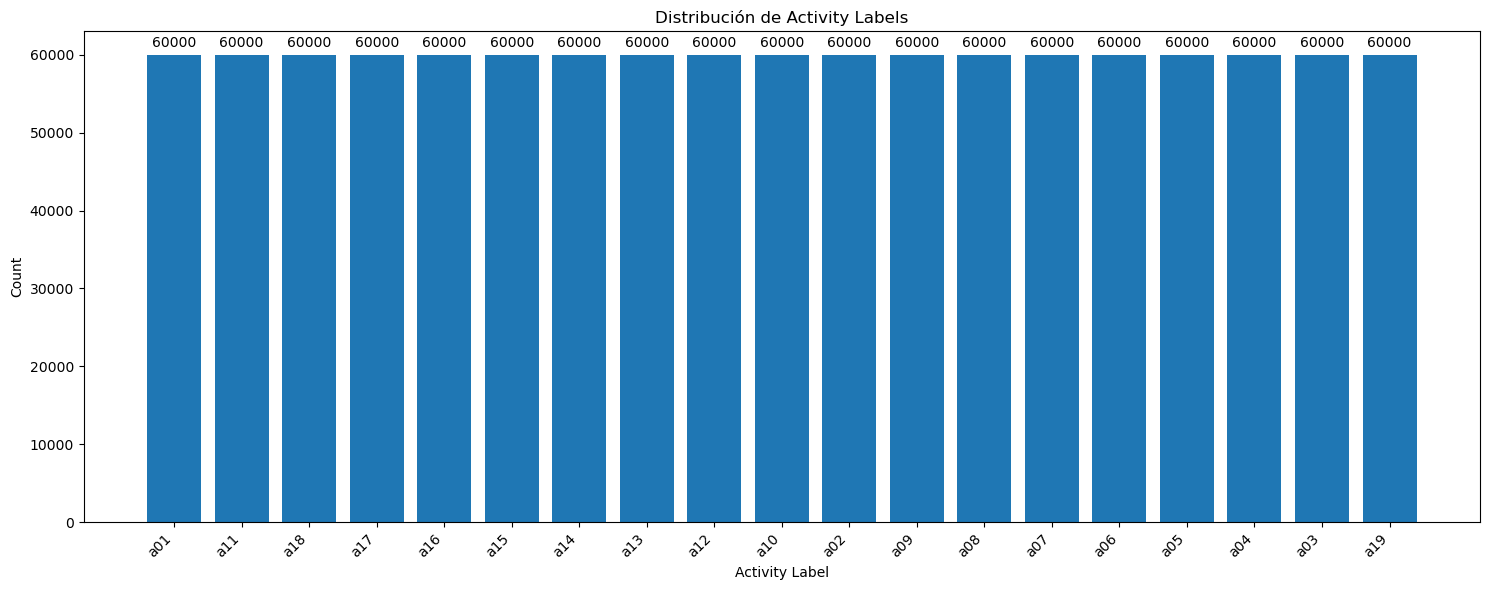

In [23]:
import matplotlib.pyplot as plt

dsa_class_distribution = dsaa_no_outlier['activity_label'].value_counts()

distr = dsa_class_distribution

plt.figure(figsize=(15, 6))
bars = plt.bar(distr.index, distr.values)

plt.xlabel('Activity Label')
plt.ylabel('Count')
plt.title('Distribución de Activity Labels')

# Agregar la cantidad exacta en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height * 1.01, f'{int(height)}', ha='center', va='bottom')

# Rotar etiquetas del eje X y ajustar el tamaño de la fuente
plt.xticks(rotation=45, ha='right', fontsize=10)

# Ajustar los márgenes para que las etiquetas no se recorten
plt.subplots_adjust(bottom=0.25)

plt.tight_layout()
plt.show()

In [114]:
dsaa_no_outlier.dtypes

activity_label     object
person_id          object
segment            object
T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag     

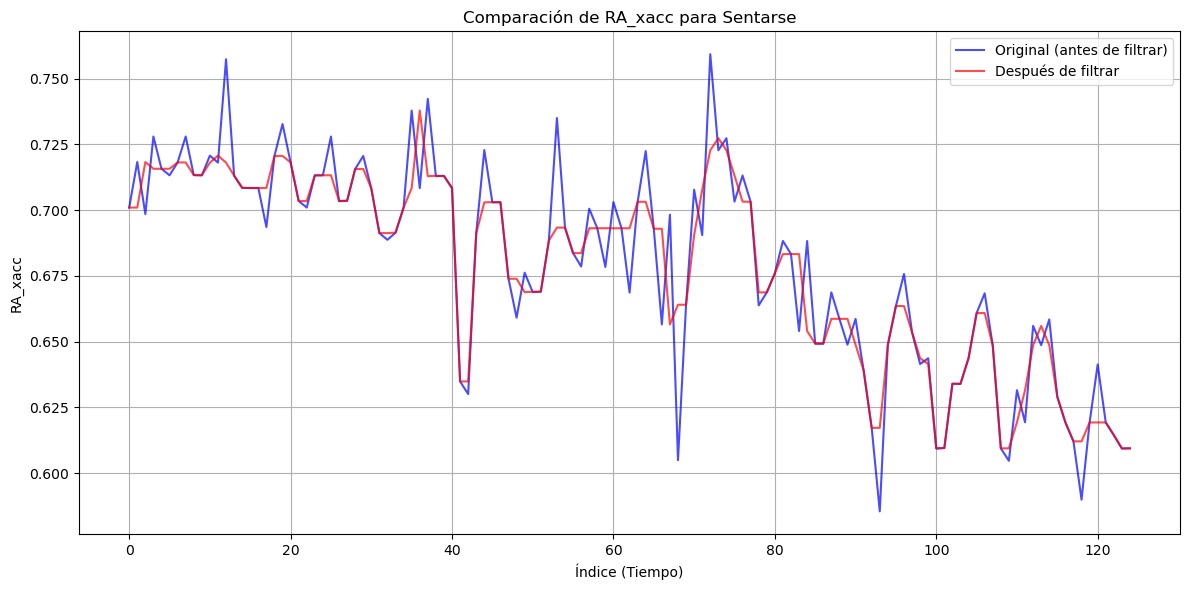

In [124]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a01p1s01.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para Sentarse')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


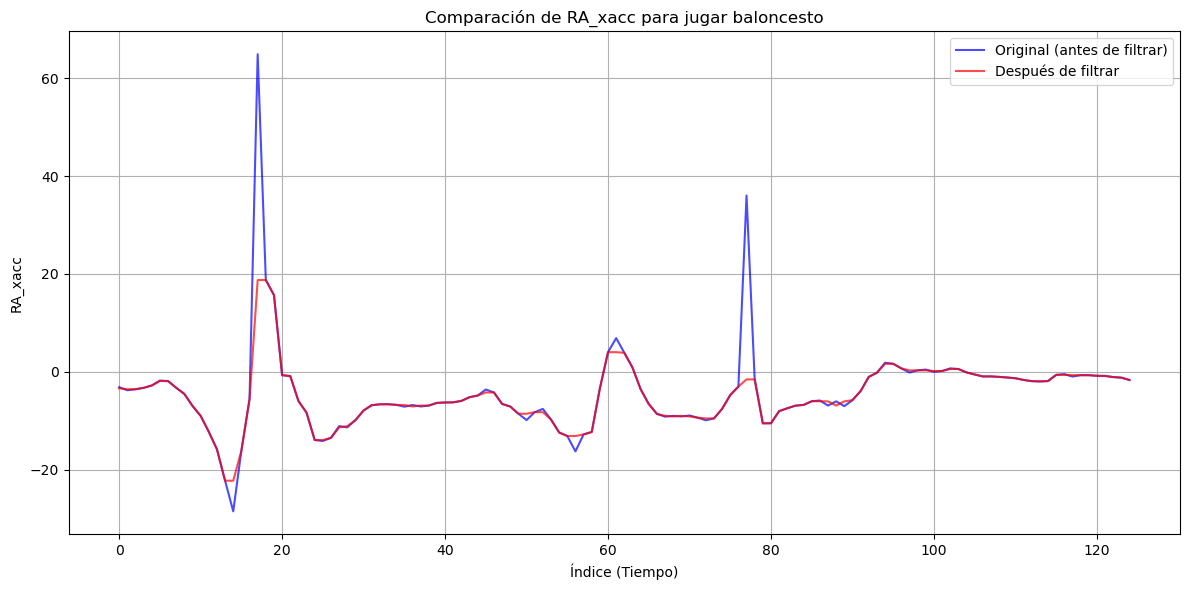

In [130]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a19p1s03.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para jugar baloncesto')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Intentamos por segmentos de 5s en lugar de por clase:

In [70]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsaa_no_outlier

dsaa_no_outlier3 = segmentar_por_3s(df_unsegmented)
dsaa_no_outlier3

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,segment_index,segment_3s
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058,0,a01p10
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058,0,a01p10
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058,0,a01p10
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058,0,a01p10
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,99,a19p899
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,99,a19p899
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489,99,a19p899
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489,99,a19p899


In [72]:
non_sensor_columns_3s = ["activity_label", "person_id", "segment", "segment_index", "segment_3s"]
only_sensor_columns_3s = df_segmented.drop(non_sensor_columns_3s, axis="columns")

In [76]:
only_sensor_columns_3s.dtypes

T_xacc      float64
T_yacc      float64
T_zacc      float64
T_xgyro     float64
T_ygyro     float64
T_zgyro     float64
T_xmag      float64
T_ymag      float64
T_zmag      float64
RA_xacc     float64
RA_yacc     float64
RA_zacc     float64
RA_xgyro    float64
RA_ygyro    float64
RA_zgyro    float64
RA_xmag     float64
RA_ymag     float64
RA_zmag     float64
LA_xacc     float64
LA_yacc     float64
LA_zacc     float64
LA_xgyro    float64
LA_ygyro    float64
LA_zgyro    float64
LA_xmag     float64
LA_ymag     float64
LA_zmag     float64
RL_xacc     float64
RL_yacc     float64
RL_zacc     float64
RL_xgyro    float64
RL_ygyro    float64
RL_zgyro    float64
RL_xmag     float64
RL_ymag     float64
RL_zmag     float64
LL_xacc     float64
LL_yacc     float64
LL_zacc     float64
LL_xgyro    float64
LL_ygyro    float64
LL_zgyro    float64
LL_xmag     float64
LL_ymag     float64
LL_zmag     float64
dtype: object

In [78]:
dsaa_no_outlier3.columns

Index(['activity_label', 'person_id', 'segment', 'T_xacc', 'T_yacc', 'T_zacc',
       'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
       'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro',
       'RA_xmag', 'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc',
       'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
       'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro',
       'RL_xmag', 'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc',
       'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag',
       'segment_index', 'segment_3s'],
      dtype='object')

# 2 Segunda entrega: extracción de características

## 2.1. Segmentación por ventanas de tiempo

El dataset viene con las ventanas de tiempo pre-armadas como 5 segundos. Pero nosotros queremos reducirlo hasta 3 segundos. Para esto tendremos que volver a segmentar las mediciones de las actividades. 

Los sensores están a 25Hz y el dataset original los tiene en grupos de 5s, lo que significa que cada grupo de 5s tiene un total de: (5s)(25Hz) = 125 mediciones. Dado que tenemos 60 segmentos de 5s en nuestro dataset original, la cantidad total de mediciones que tenemos para una misma actividad ejecutada por una misma persona son: (60 segmentos)(125 mediciones/segmento) = 7500 mediciones en total.

Si queremos pasarlo a 3 segundos, tendremos ventanas de: (3s)(25Hz) = 75 mediciones. La cantidad total de segmentos que tendremos de una misma actividad ejectuada por una misma persona serán de: (7500 mediciones) / (75 mediciones por segmento) = 100 segmentos.

Nótese que las mediciones encajan perfectamente en las ventanas de tiempo.

Observamos que cada actividad ejecutada por cada persona tiene exactamente 100 segmentos, por lo que se realizaó de manera correcta la segmnetación.

In [80]:
dsaa_no_outlier3.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

## 2.2. Extracción de características

In [82]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

Ahora generamos el dataset con las features de cada ejemplo y sus labels.

In [84]:
import numpy as np
import pandas as pd

df_to_extract_features = dsaa_no_outlier3

numeric_features_list = []
labels = []

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Concatenate numeric features and labels
examples_db = pd.concat([df_numeric, df_labels], axis=1)

# Optionally, check the data types to confirm
examples_db

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_y,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,0.302,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,0.303,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,0.304,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,0.304,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,0.304,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,0.380,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.709,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.172,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.365,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19


In [86]:
examples_db.dtypes

T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_mean_mag     float64
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
Length: 241, dtype: object

Esperamos tener 15,200 filas, esto porque los ejemplos son:

- (18 personas) (9 actividades) (100 ejemplos usando ventanas de 3s) = 15,200 ejemplos

Esperamos tener 240 columnas de características + 1 columna de la etiqueta de la actividad

- (16 características por sensor) (15 sensores) + 1 label = 240 features + 1 label = 241 columnas

In [88]:
examples_db.shape

(15200, 241)

Histograma de las características

In [120]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Drop 'activity' column if it exists, keeping only numeric columns
examples_db_numeric = examples_db.drop(columns=["activity"], errors="ignore")

# Number of numeric columns
num_features = len(examples_db_numeric.columns)

# We'll create an n x n grid, where n is the ceiling of the square root of the number of features
n = math.ceil(math.sqrt(num_features))

# Increase the figure size depending on how many features you have
figsize = (6 * n, 4 * n)

# Create the histograms in a grid layout
axes = examples_db_numeric.hist(
    bins=10,
    figsize=figsize,
    layout=(n, n),     # n rows, n columns
    sharex=False,
    sharey=False
)

# If axes is a 2D numpy array, flatten it so we can iterate easily
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = [axes]

# Adjust each subplot for better readability
for ax in axes:
    # Rotate the x-axis labels
    ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    # Optionally reduce title font size
    ax.set_title(ax.get_title(), fontsize=9)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.4, hspace=0.4)

# Add a main title
plt.suptitle("Histogramas de las características", fontsize=16, y=1.02)

# Use tight_layout with a rect so the suptitle doesn't overlap subplots
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


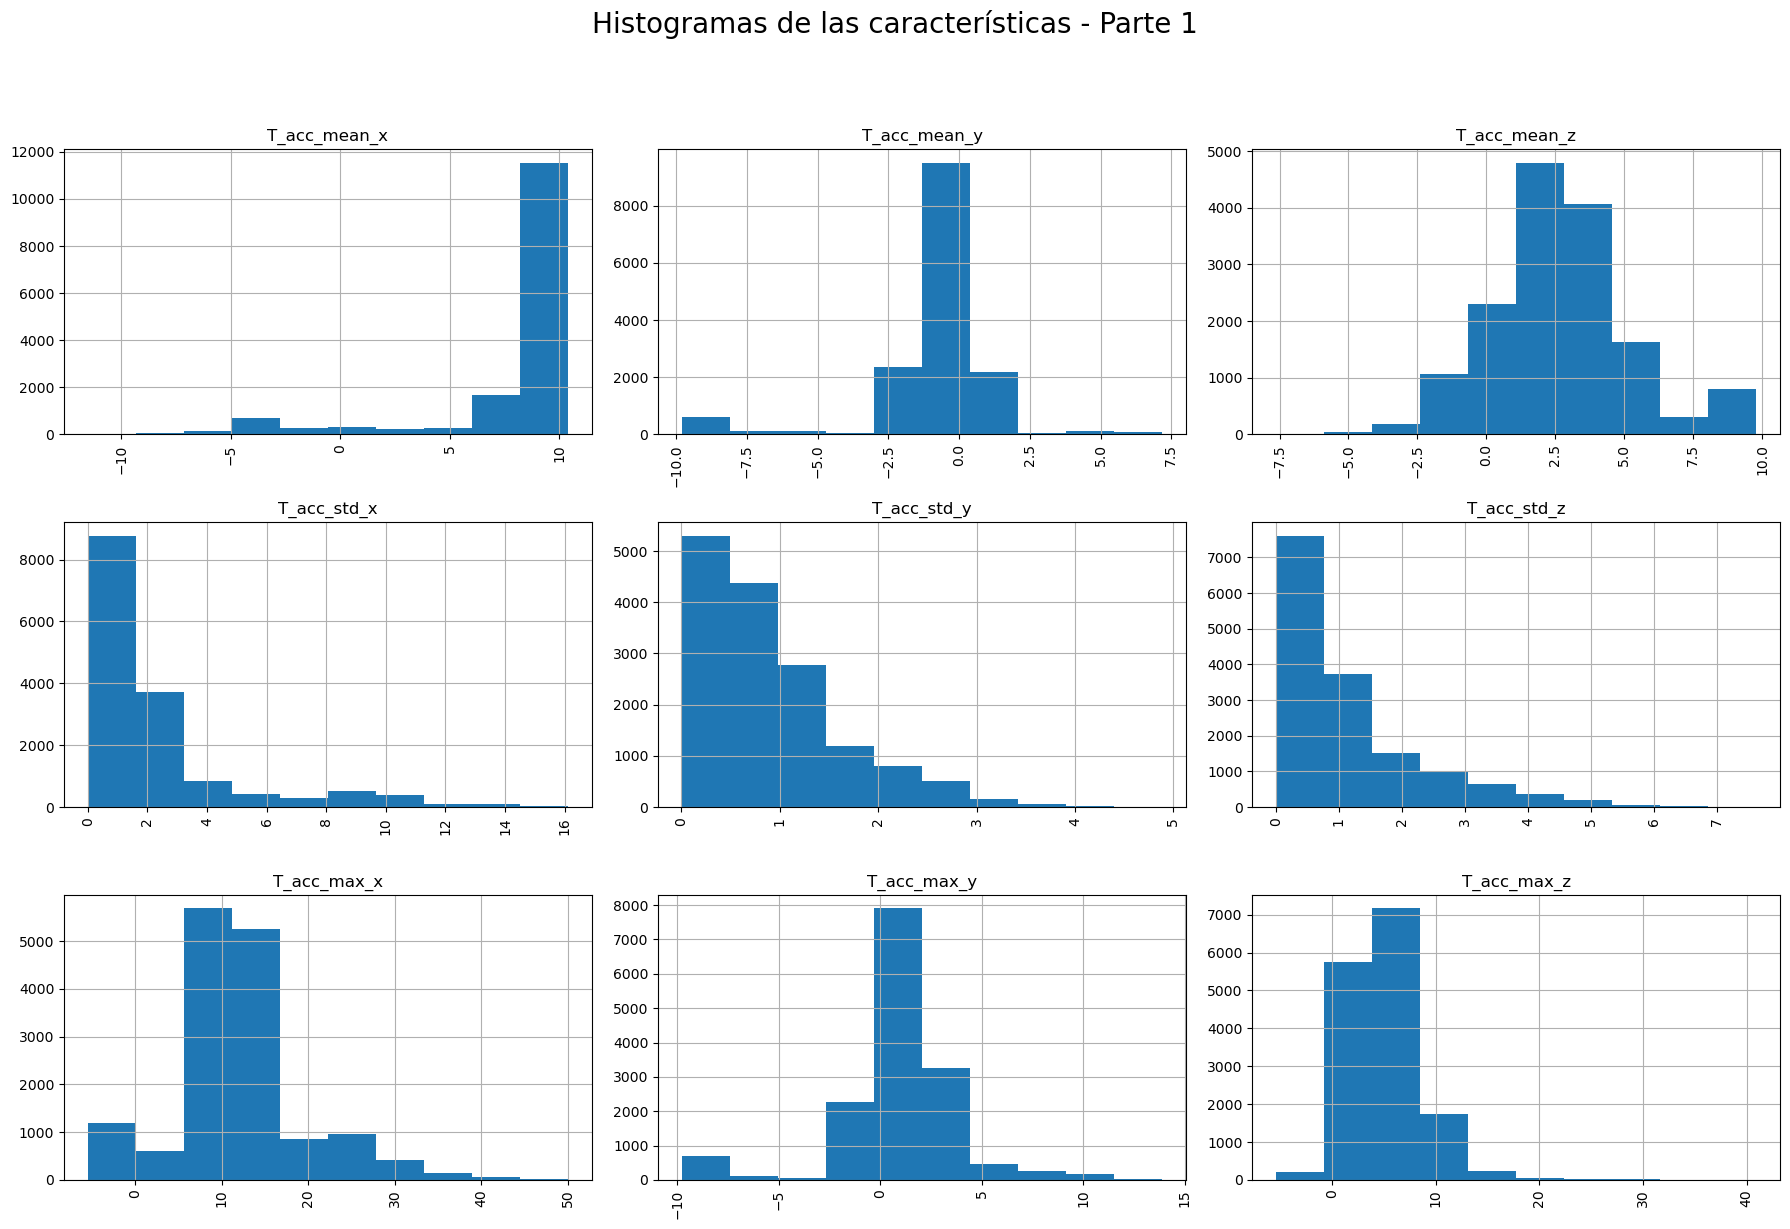

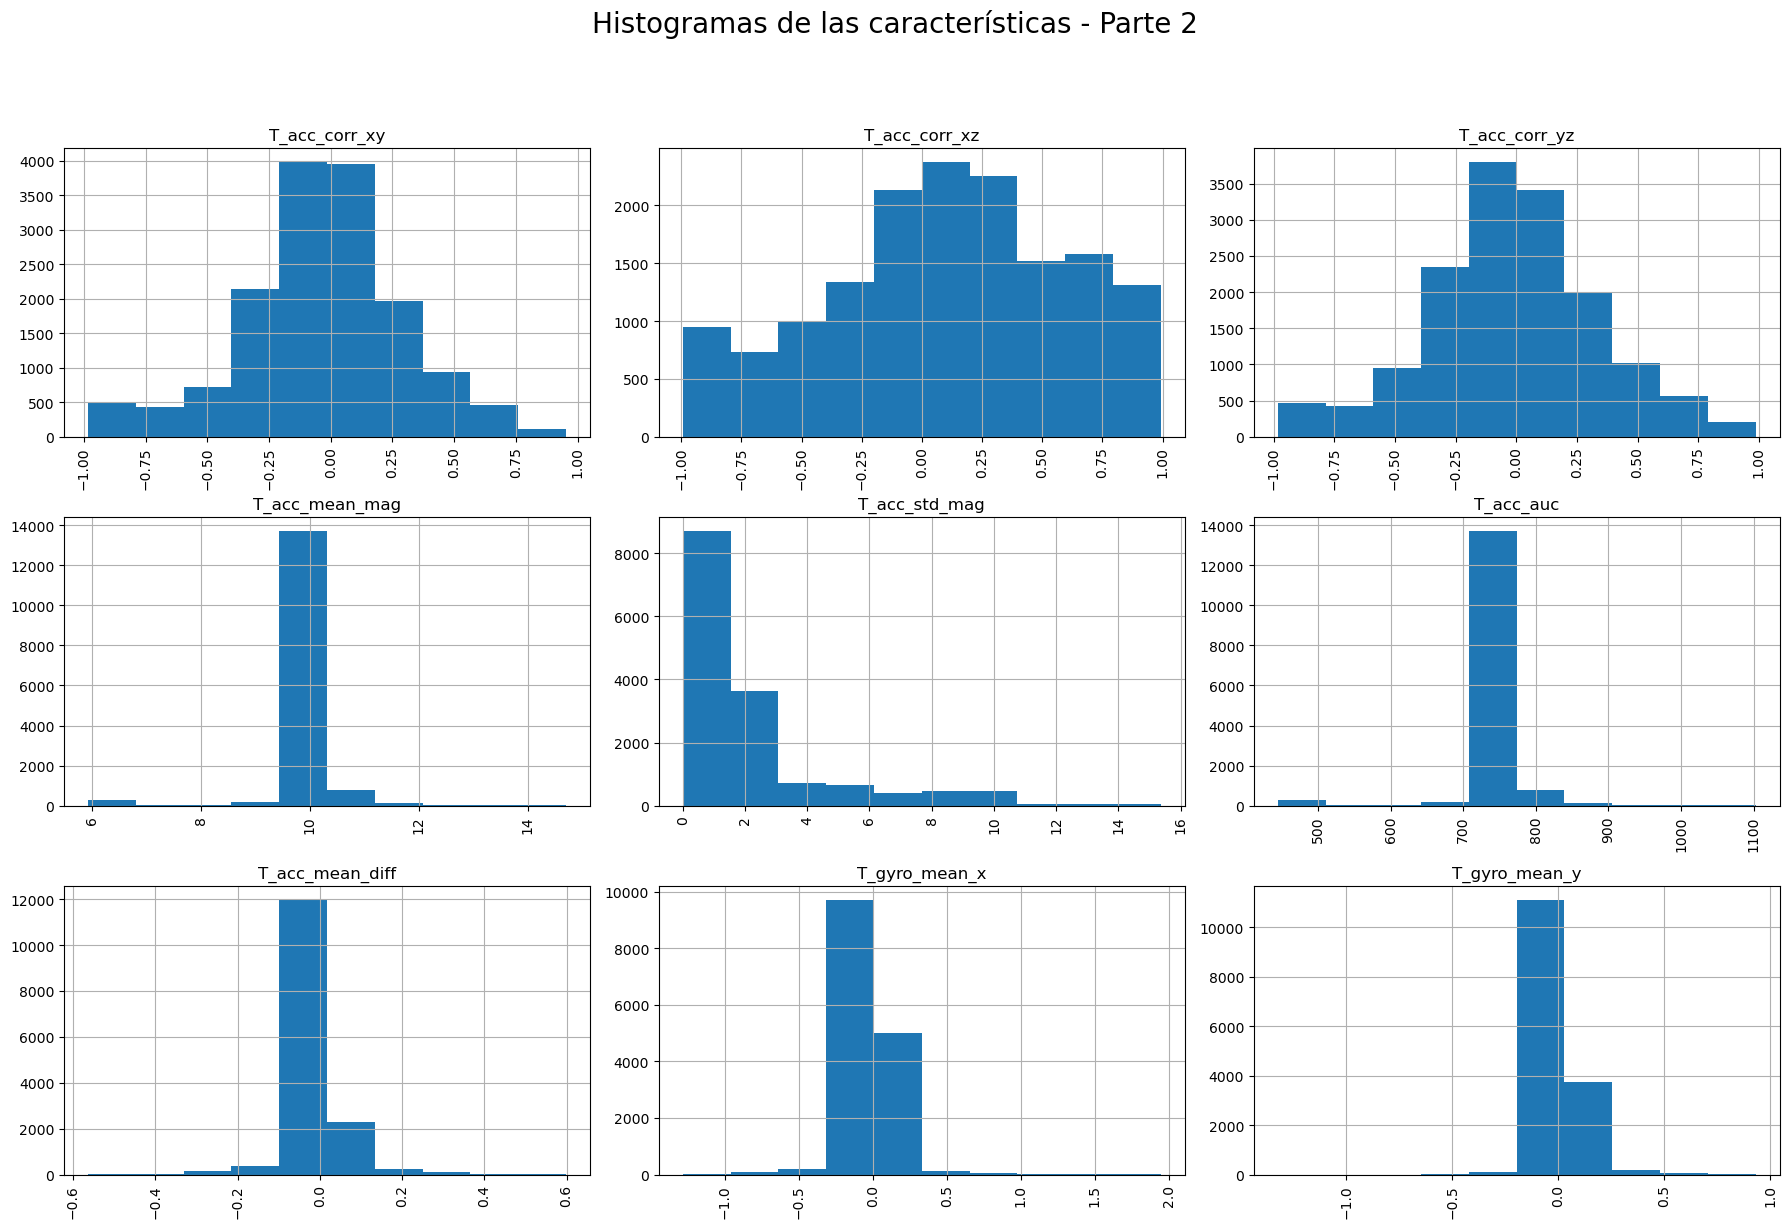

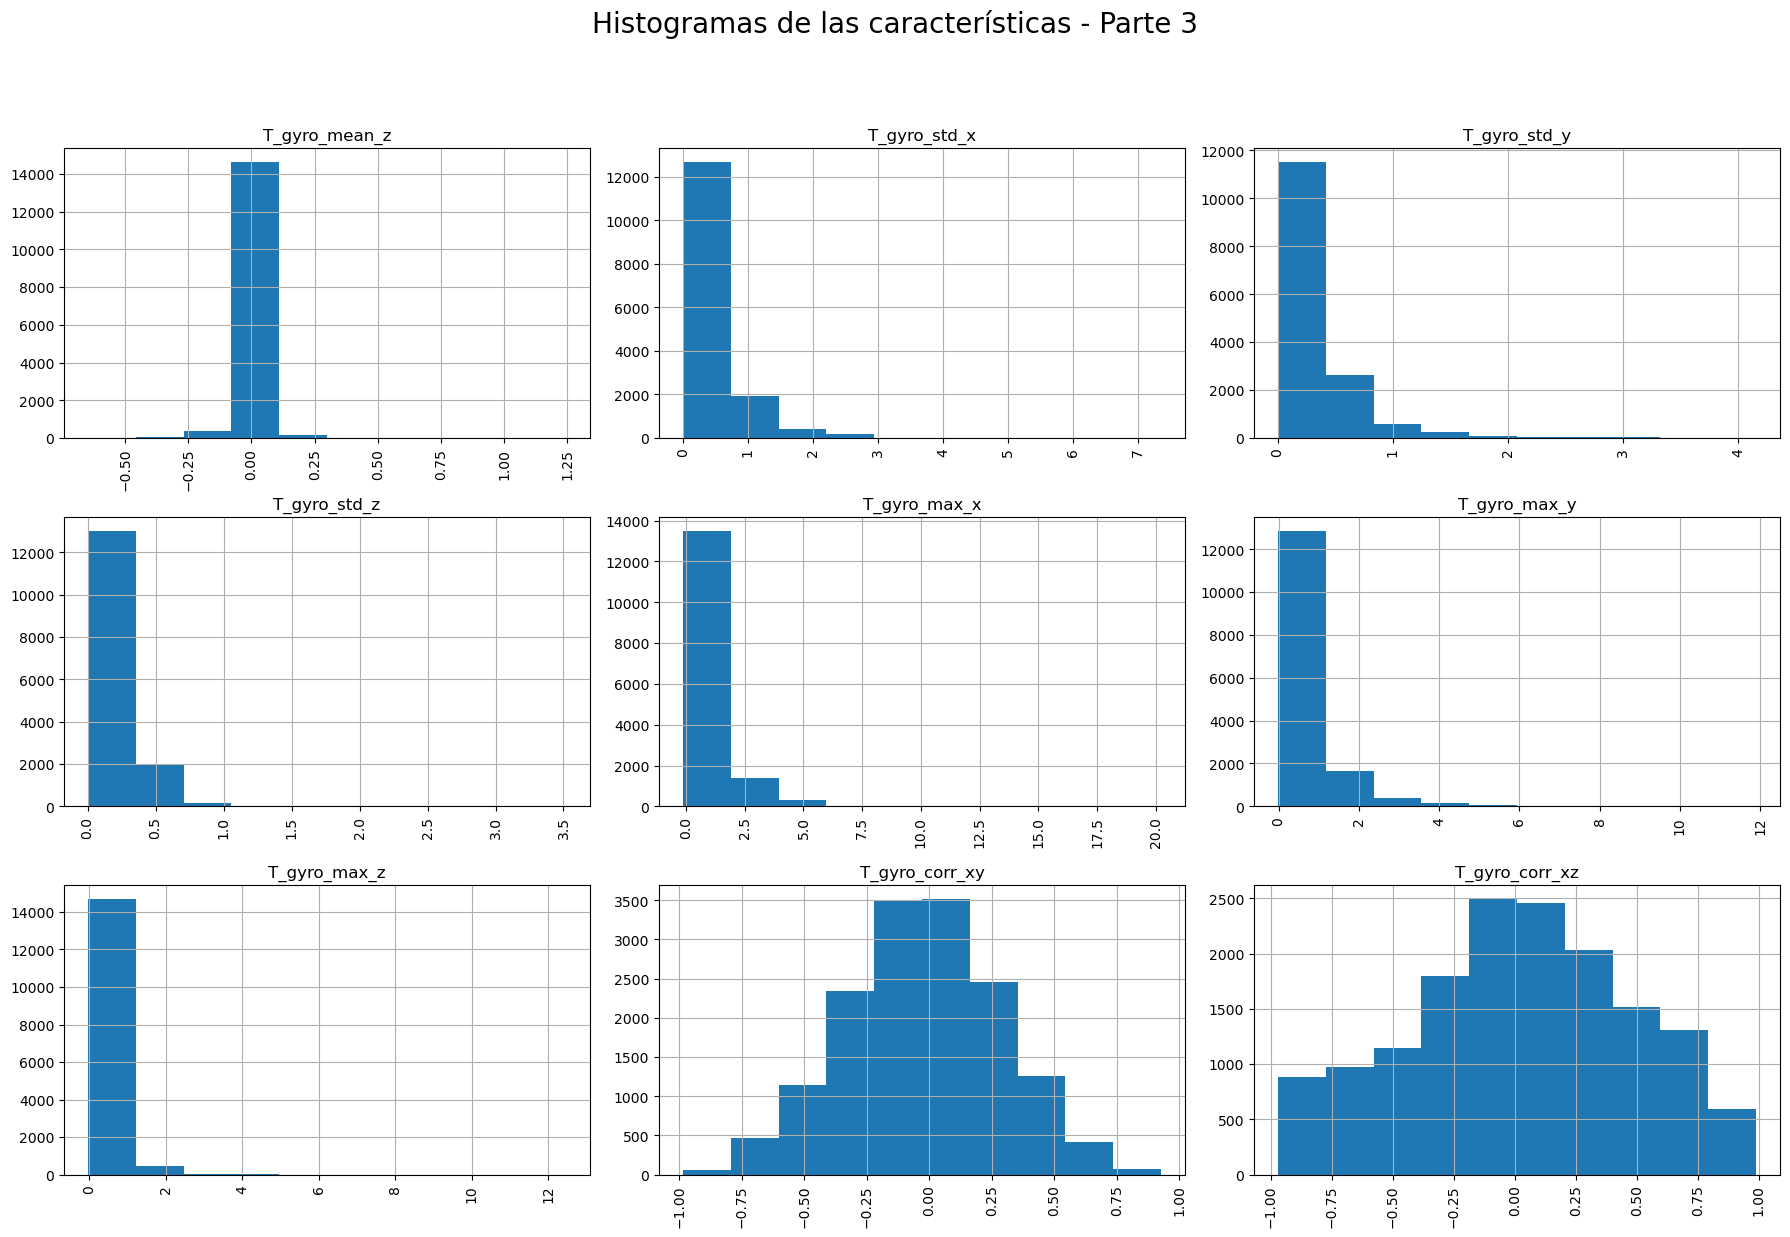

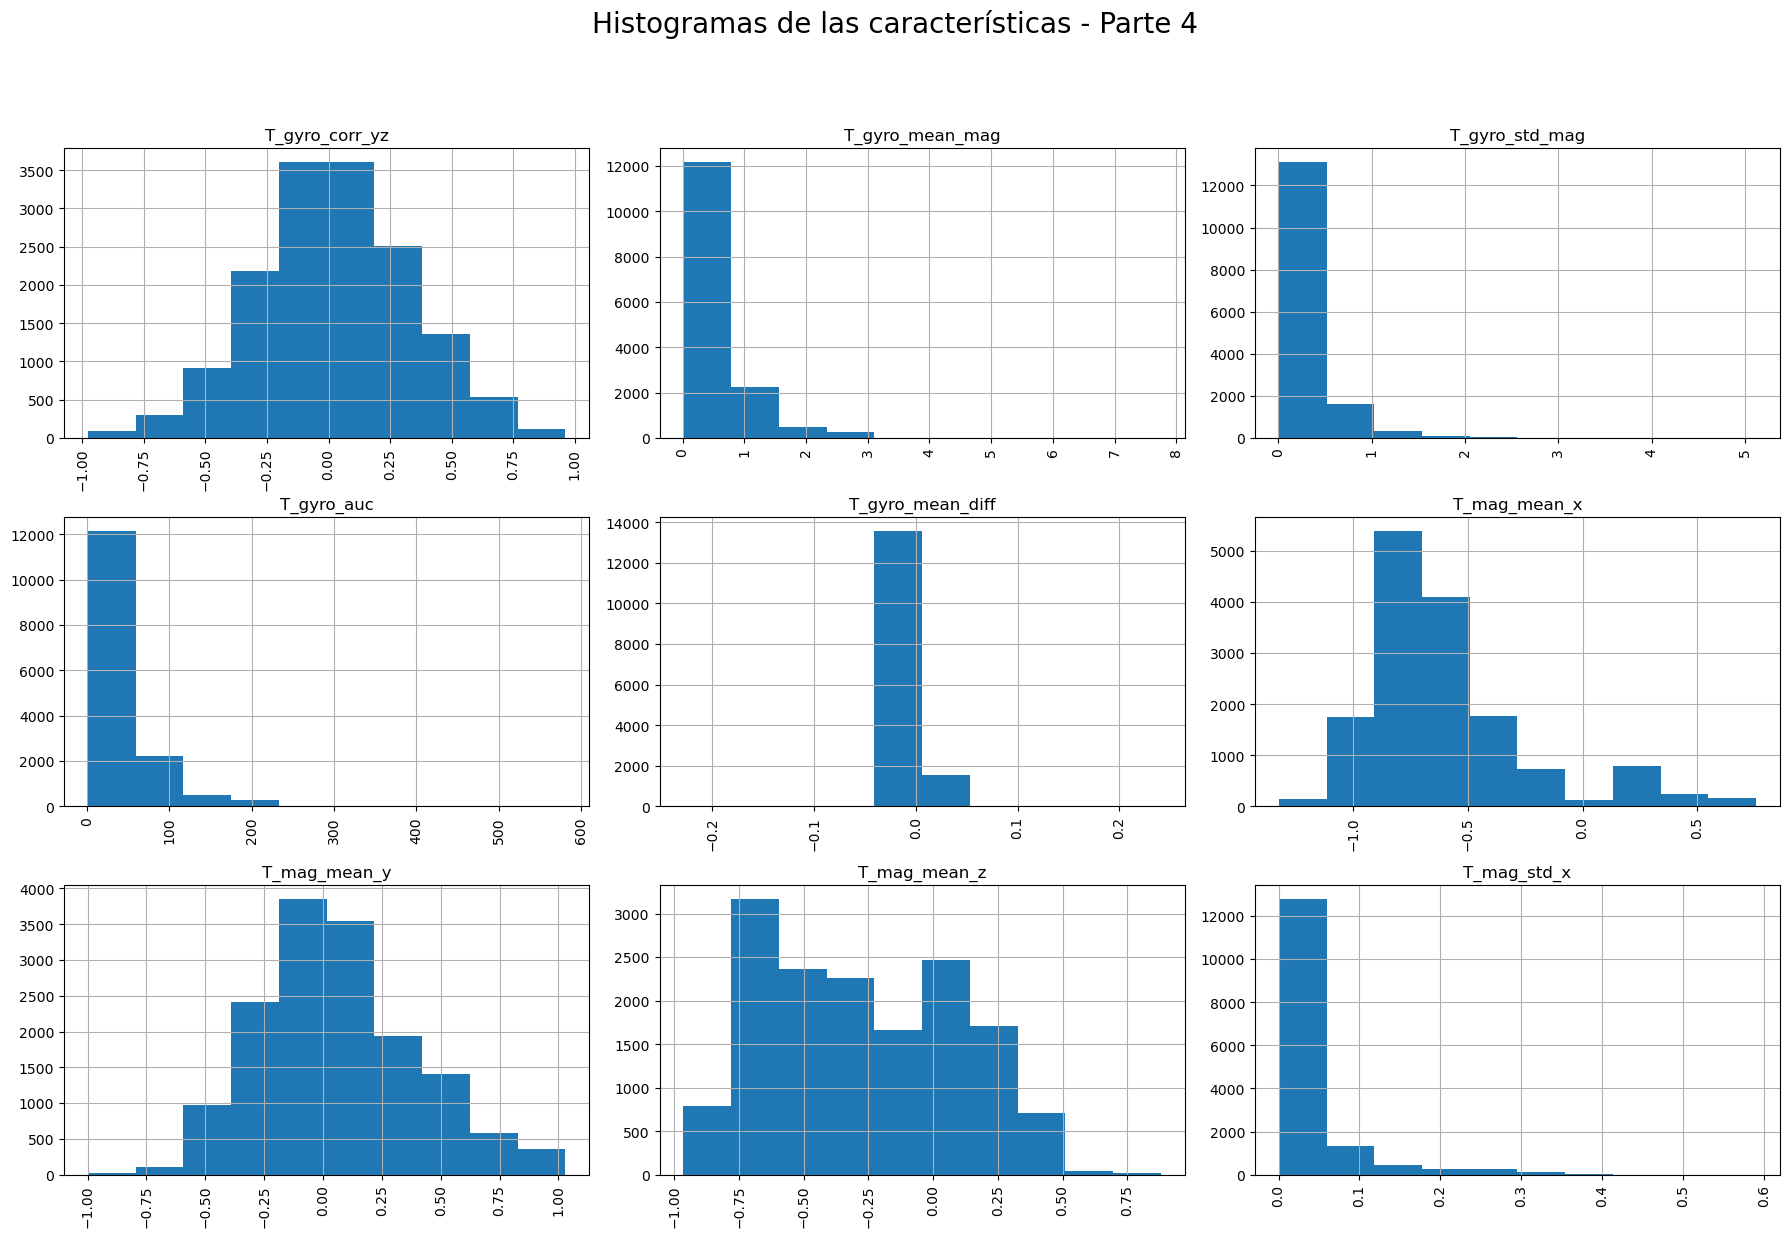

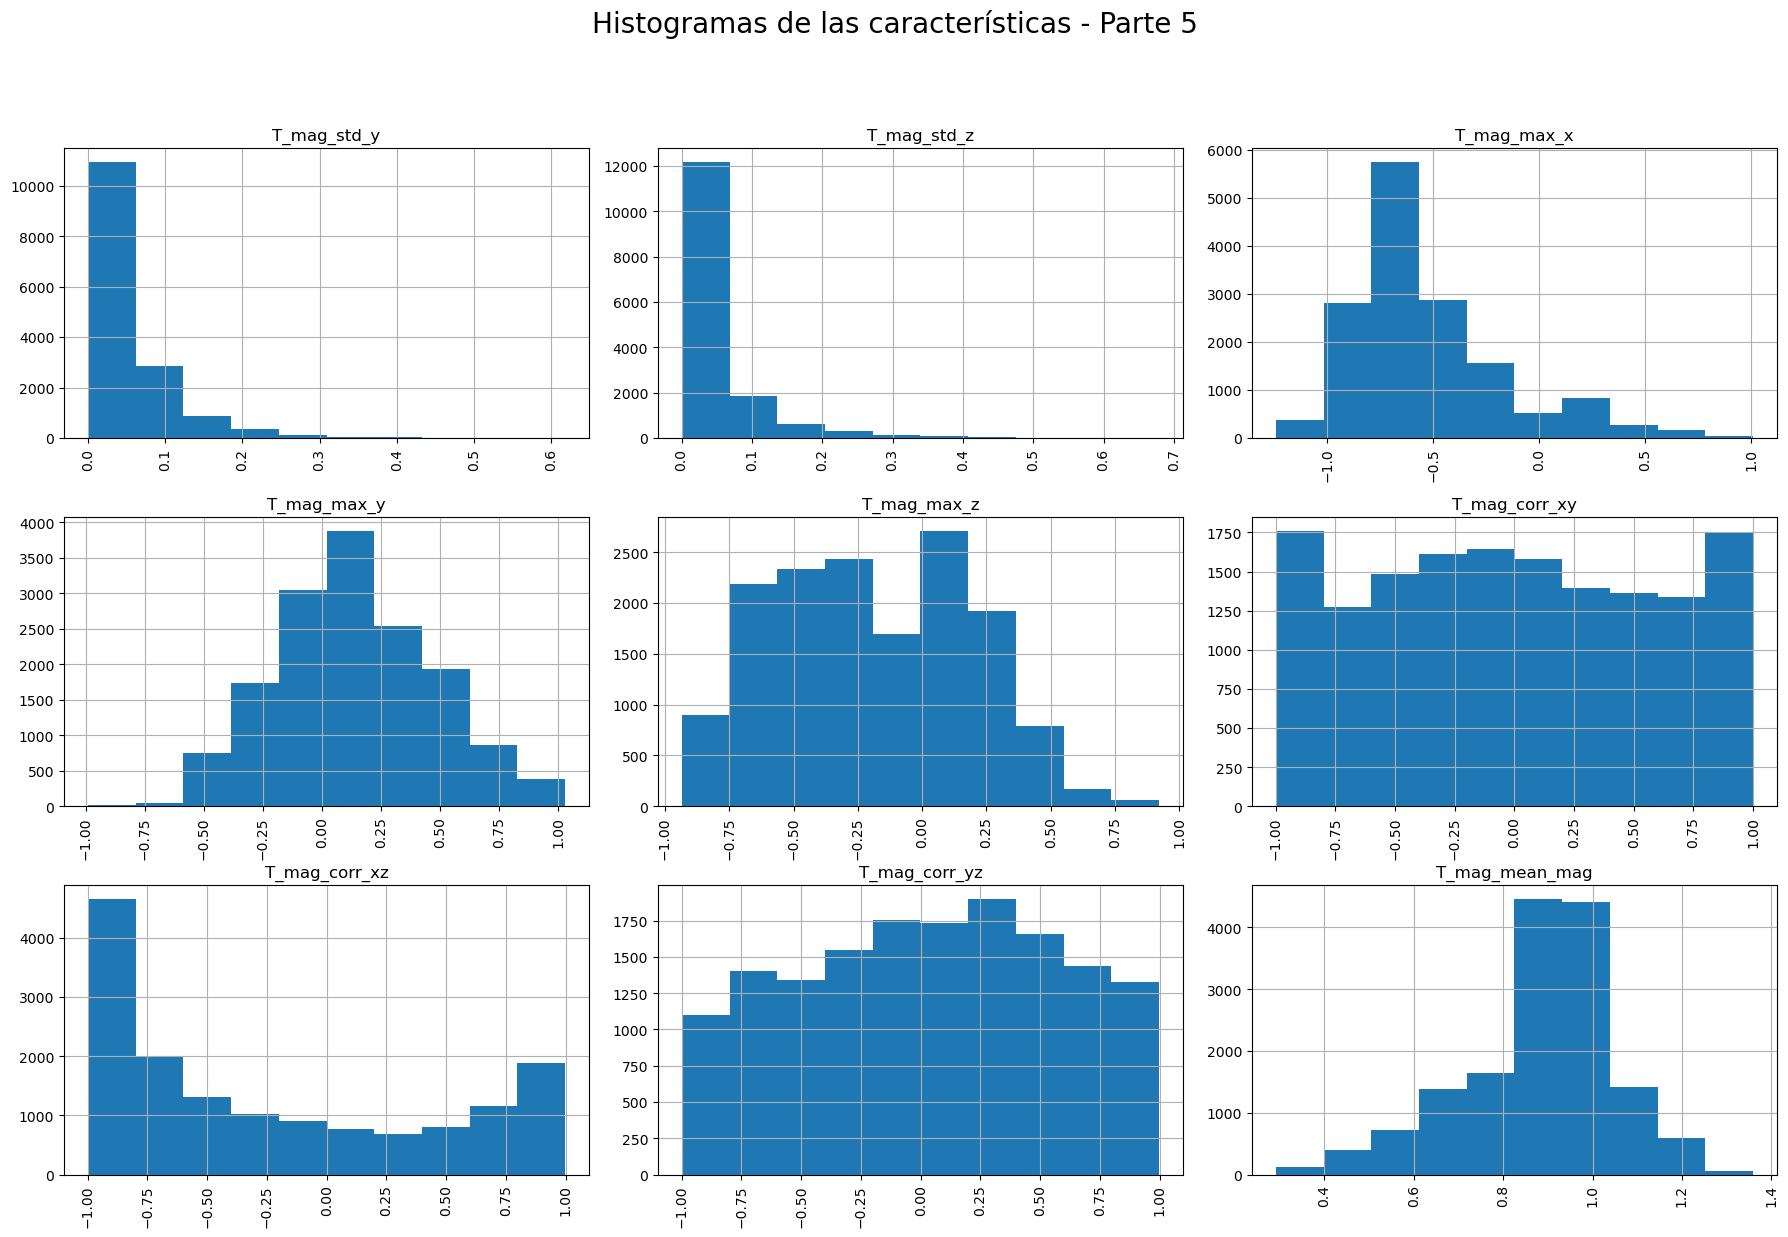

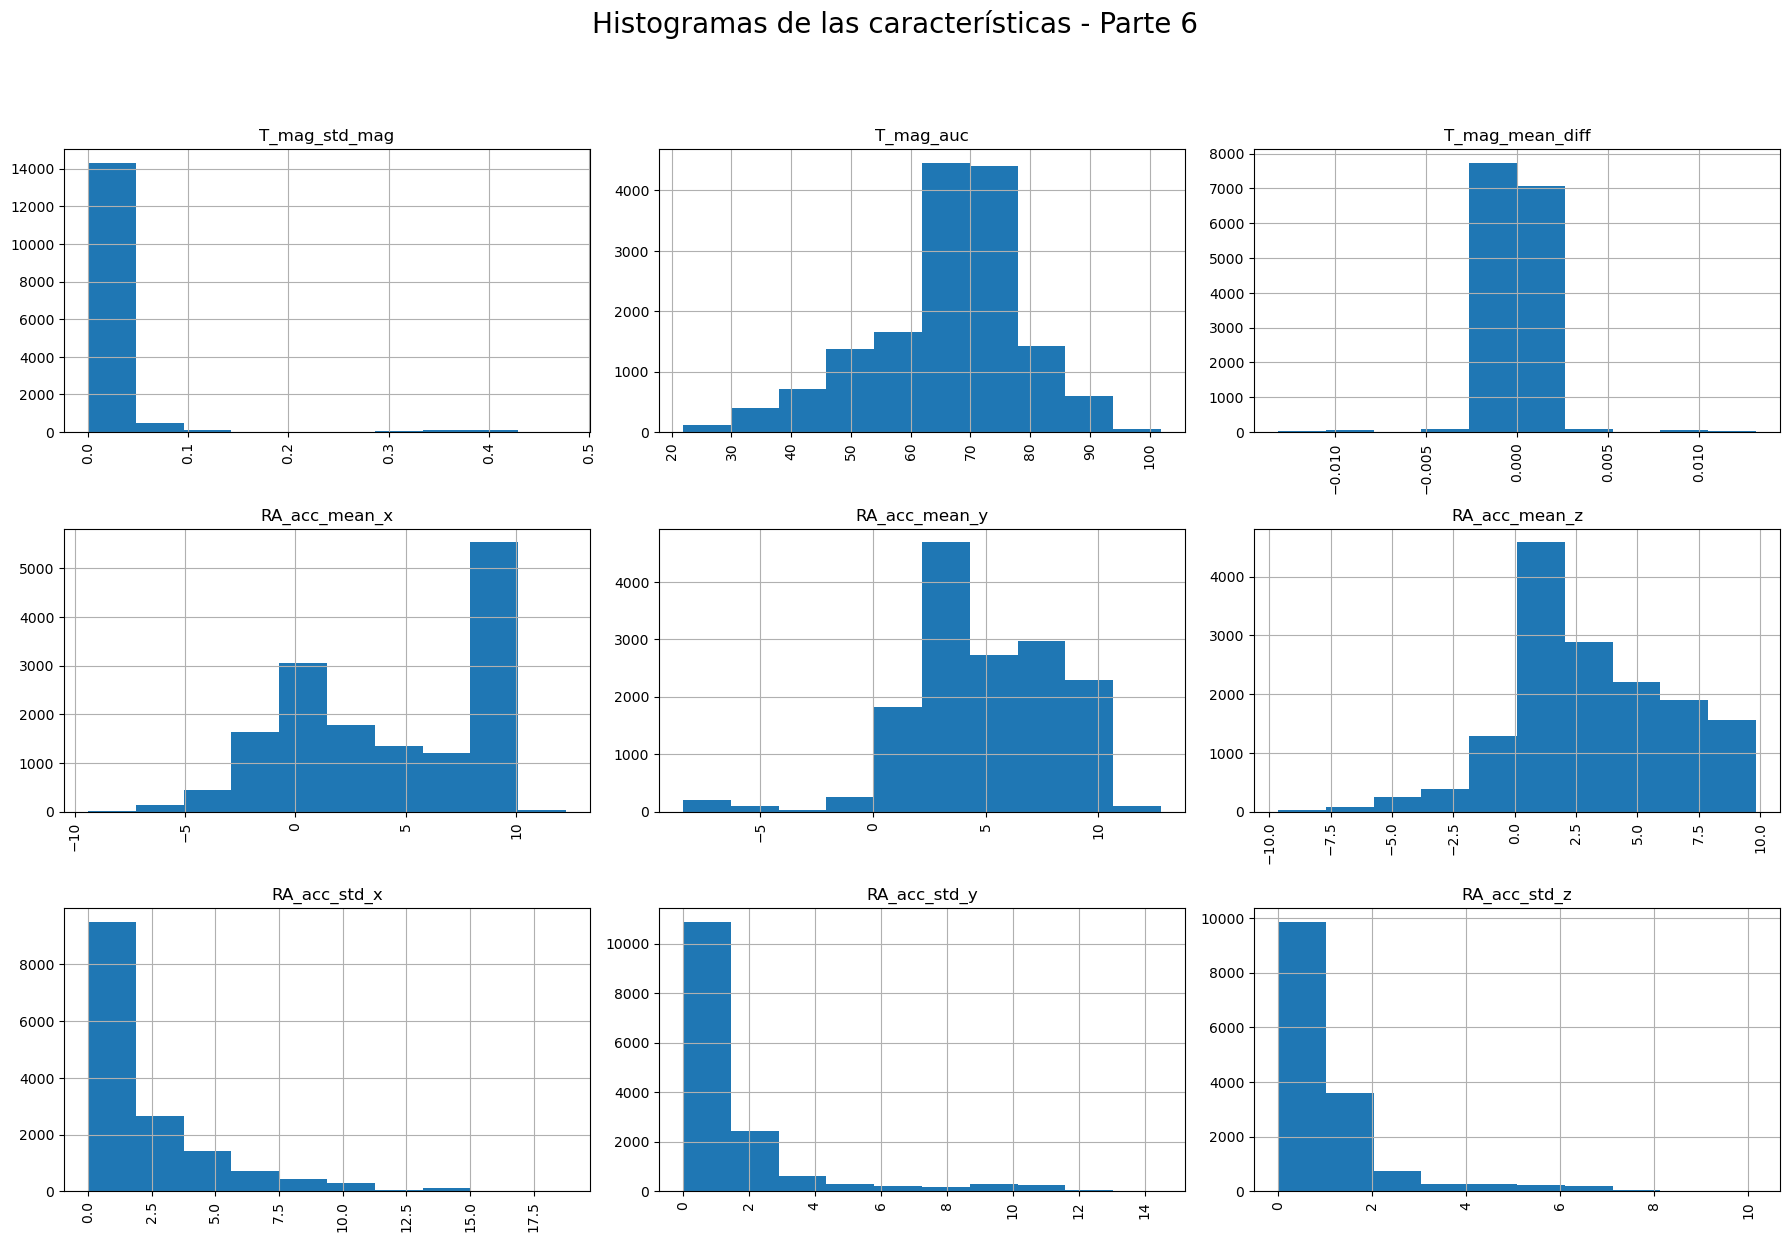

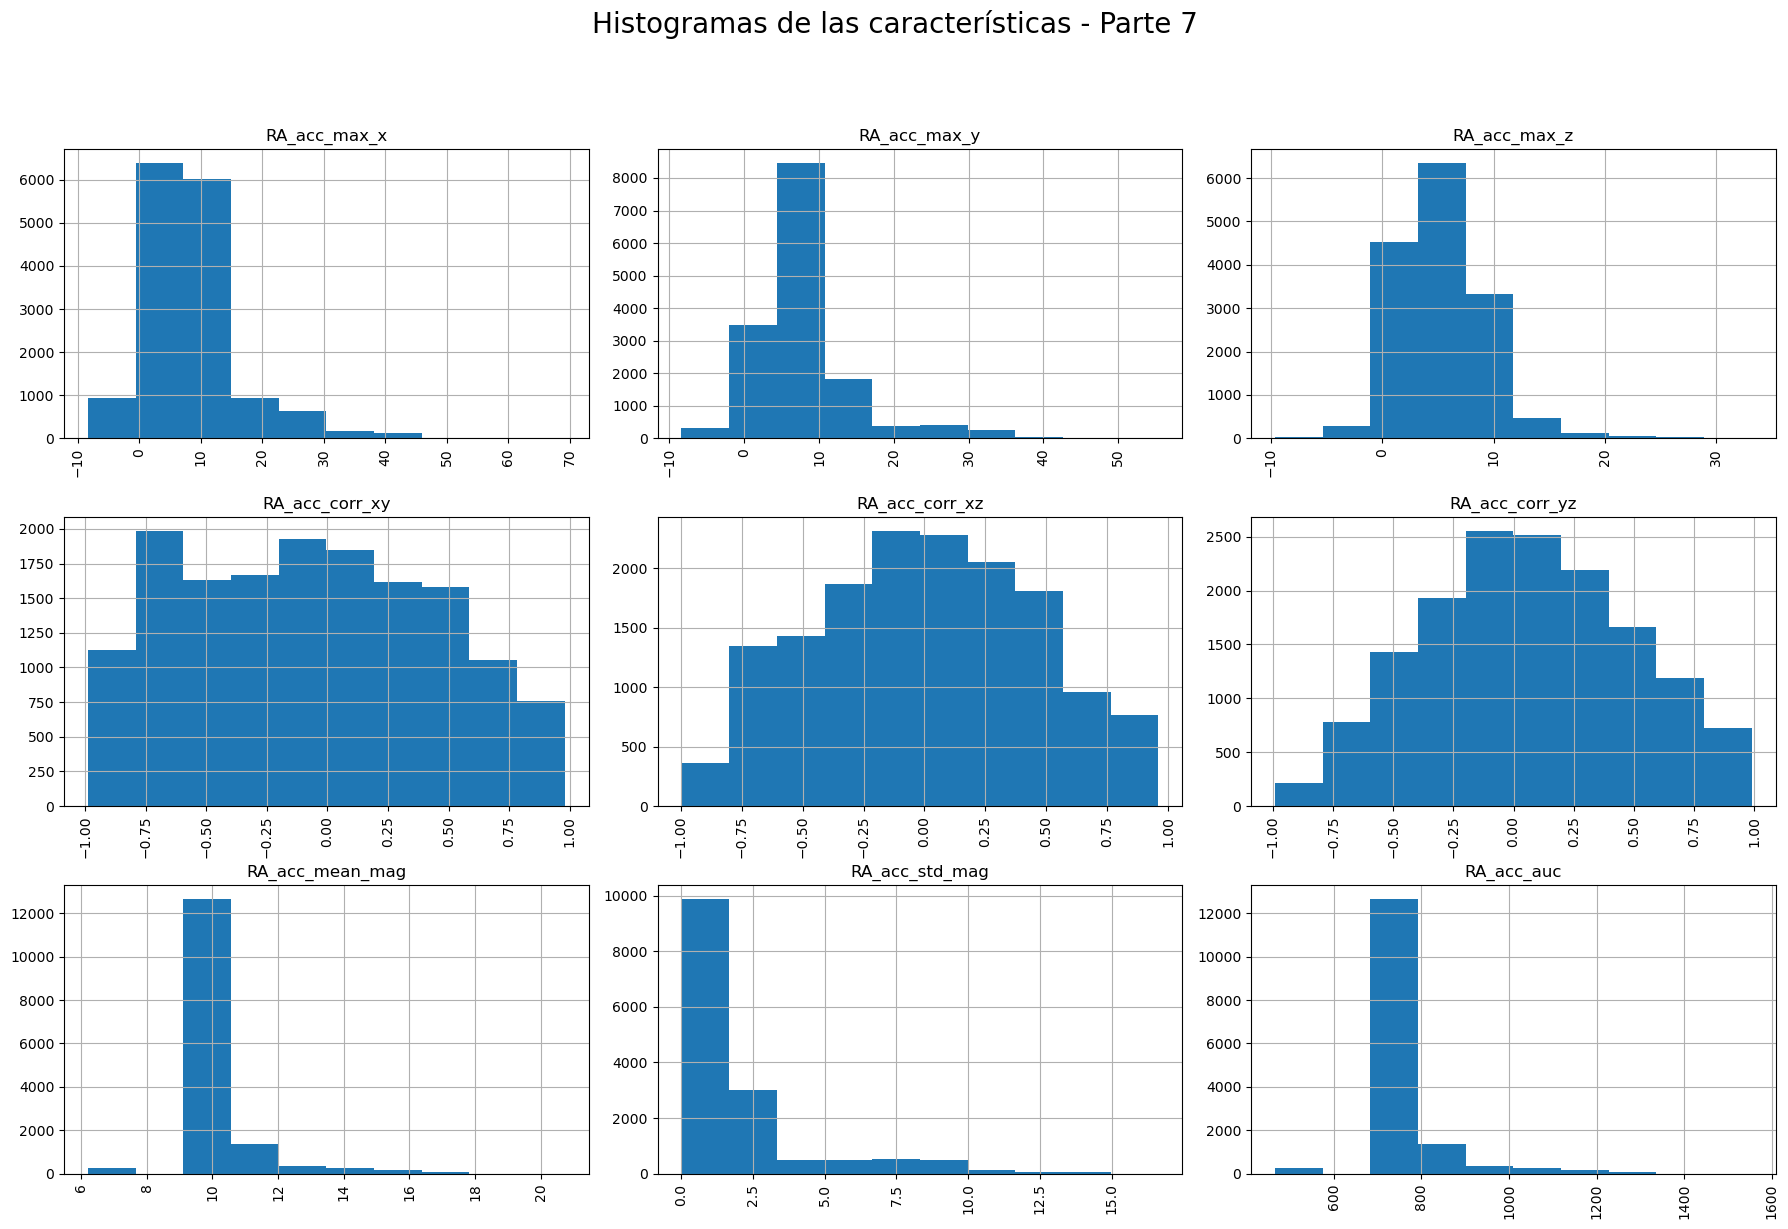

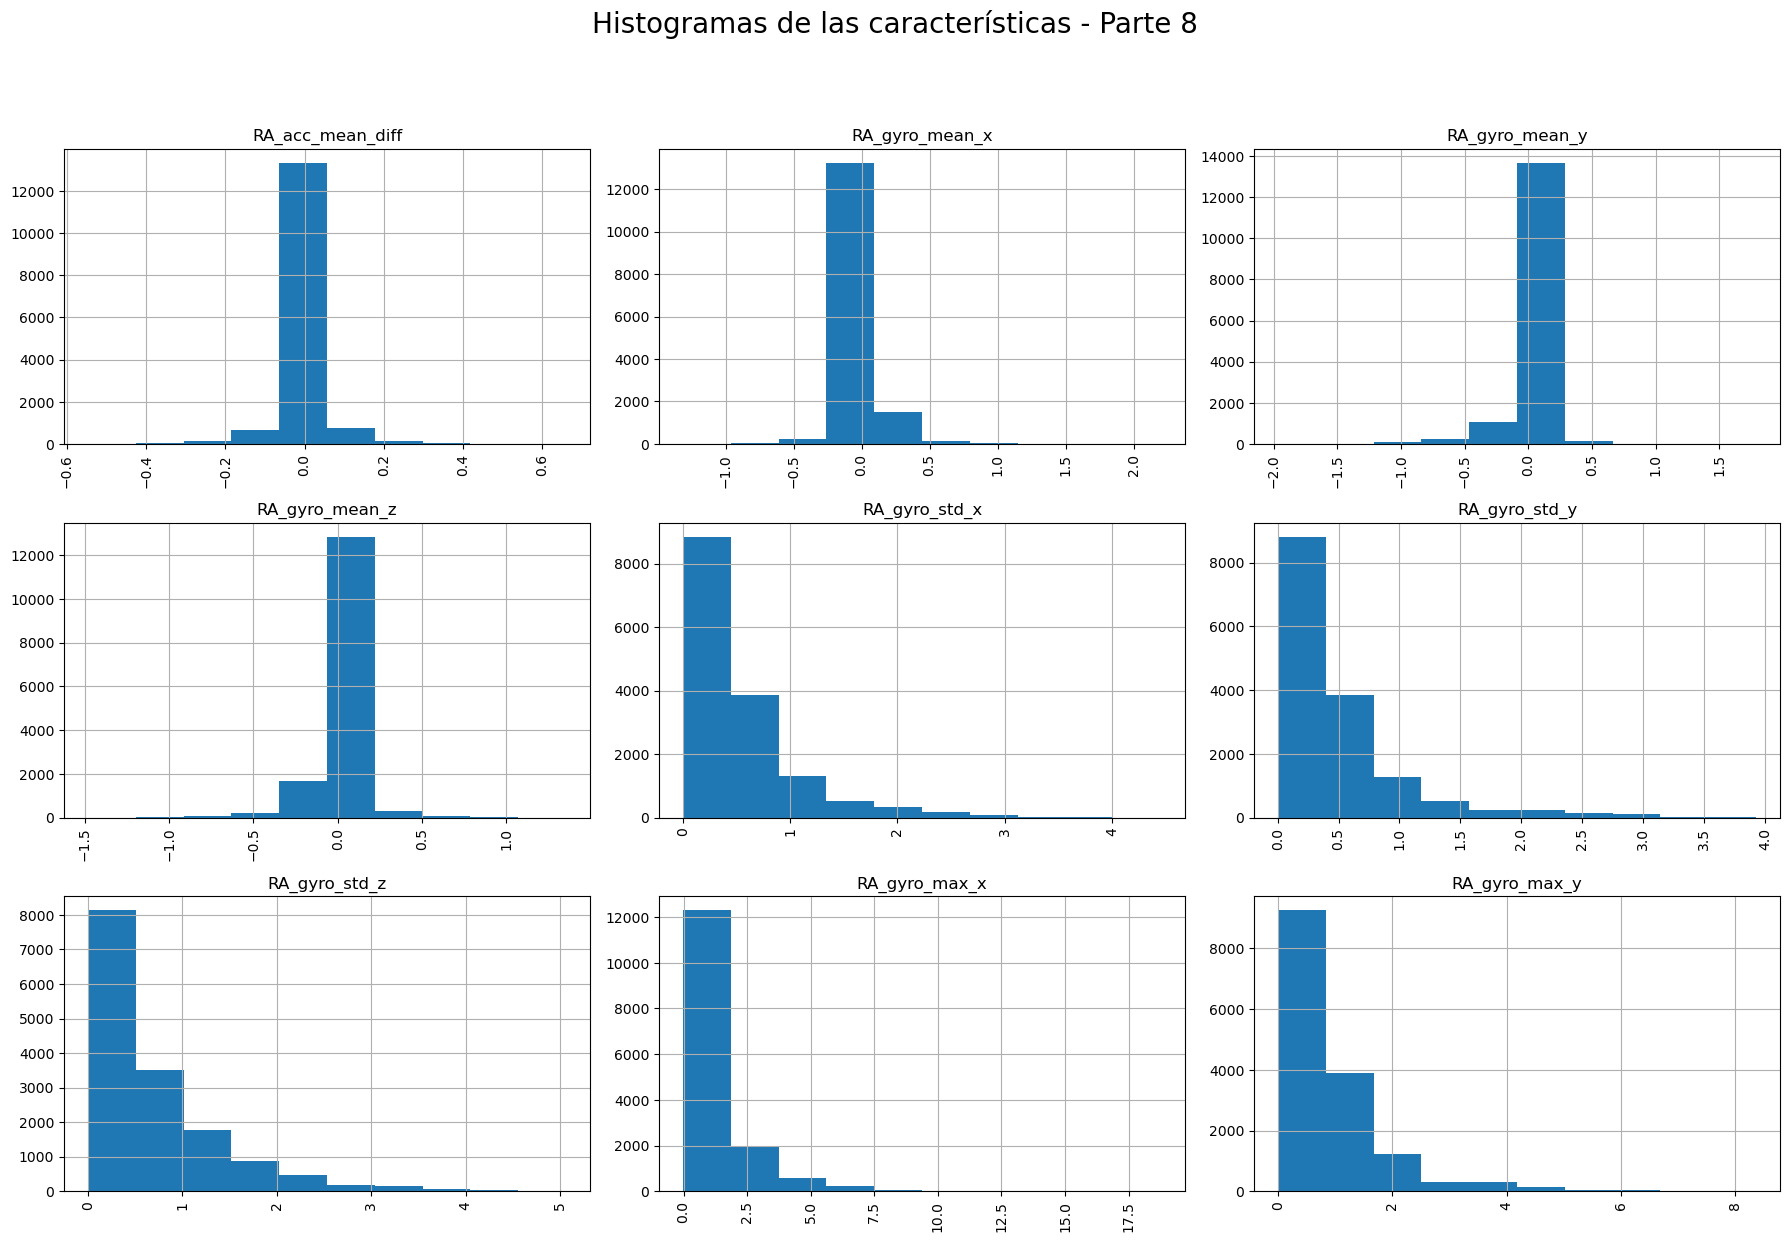

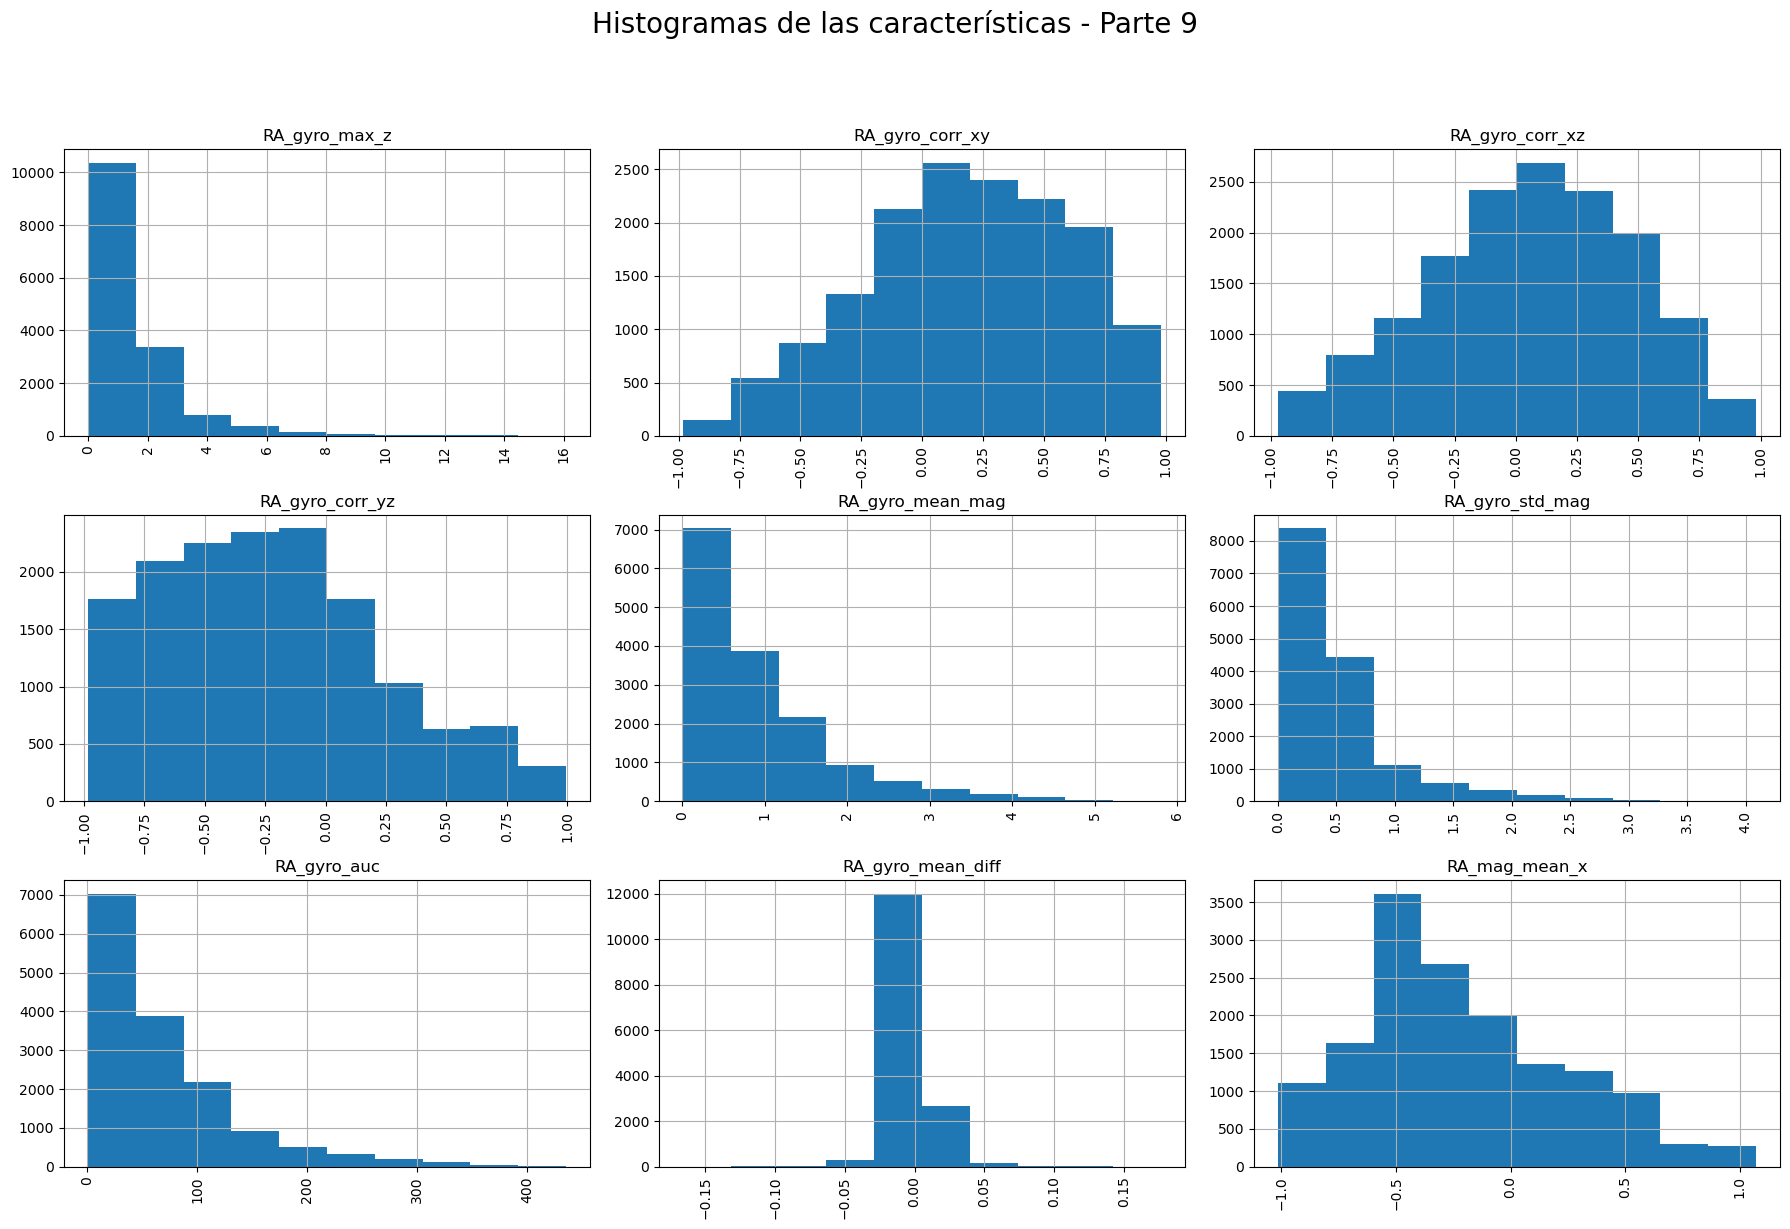

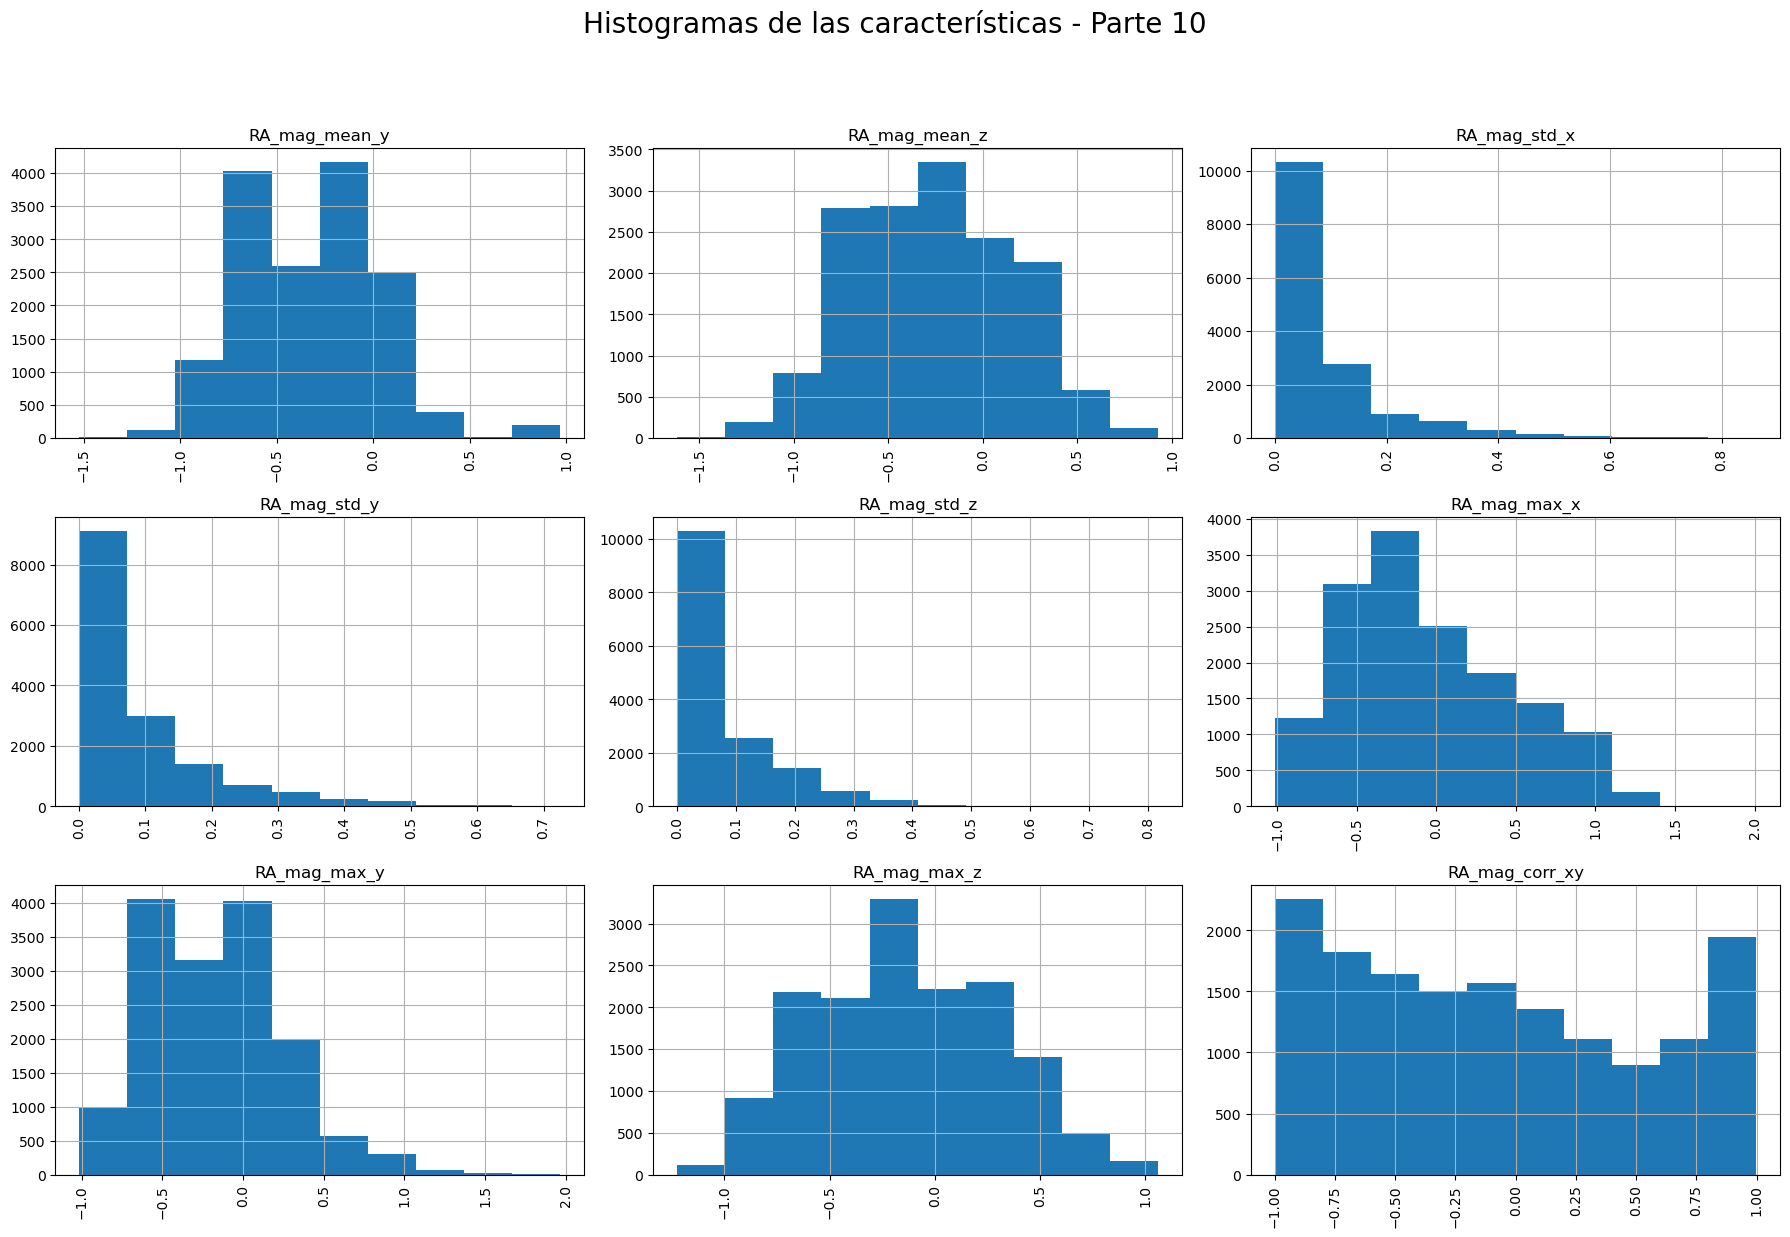

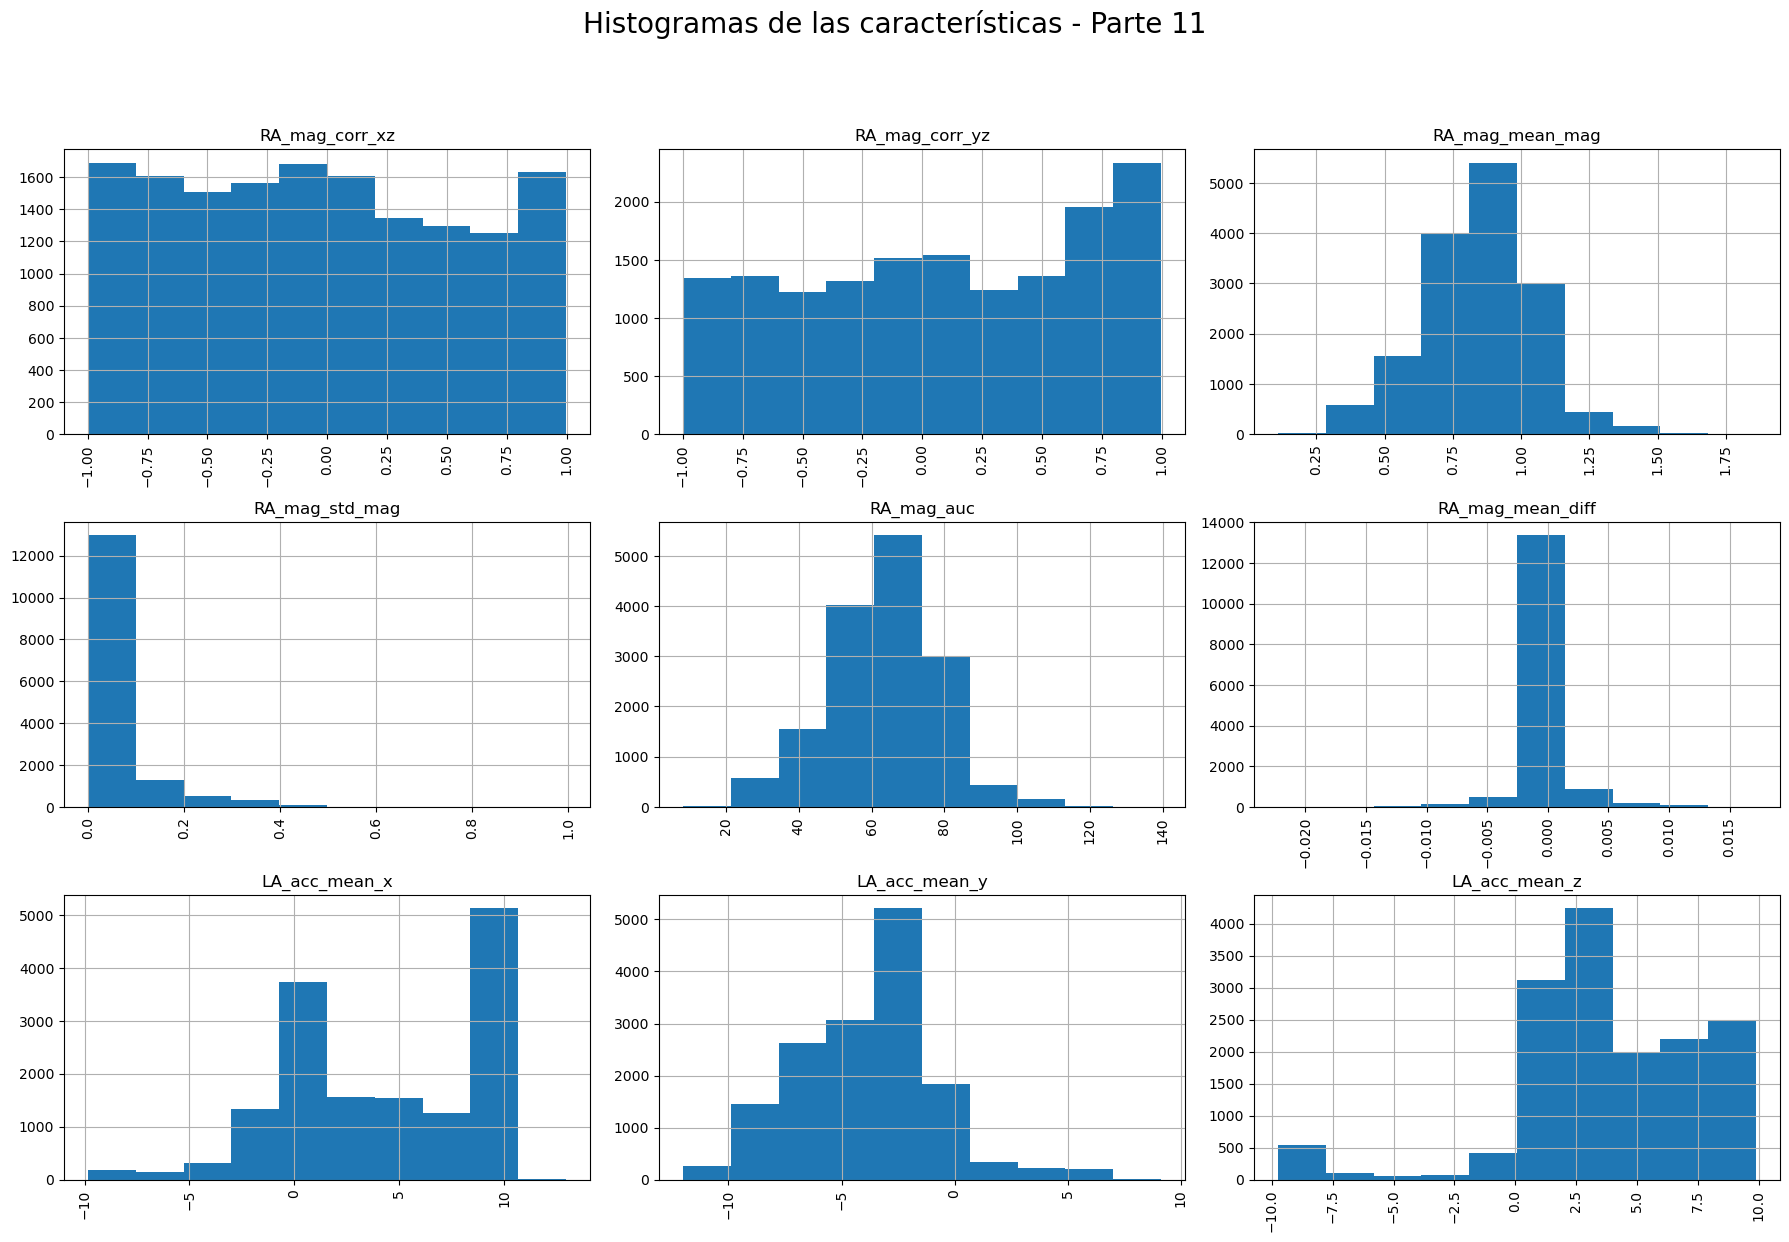

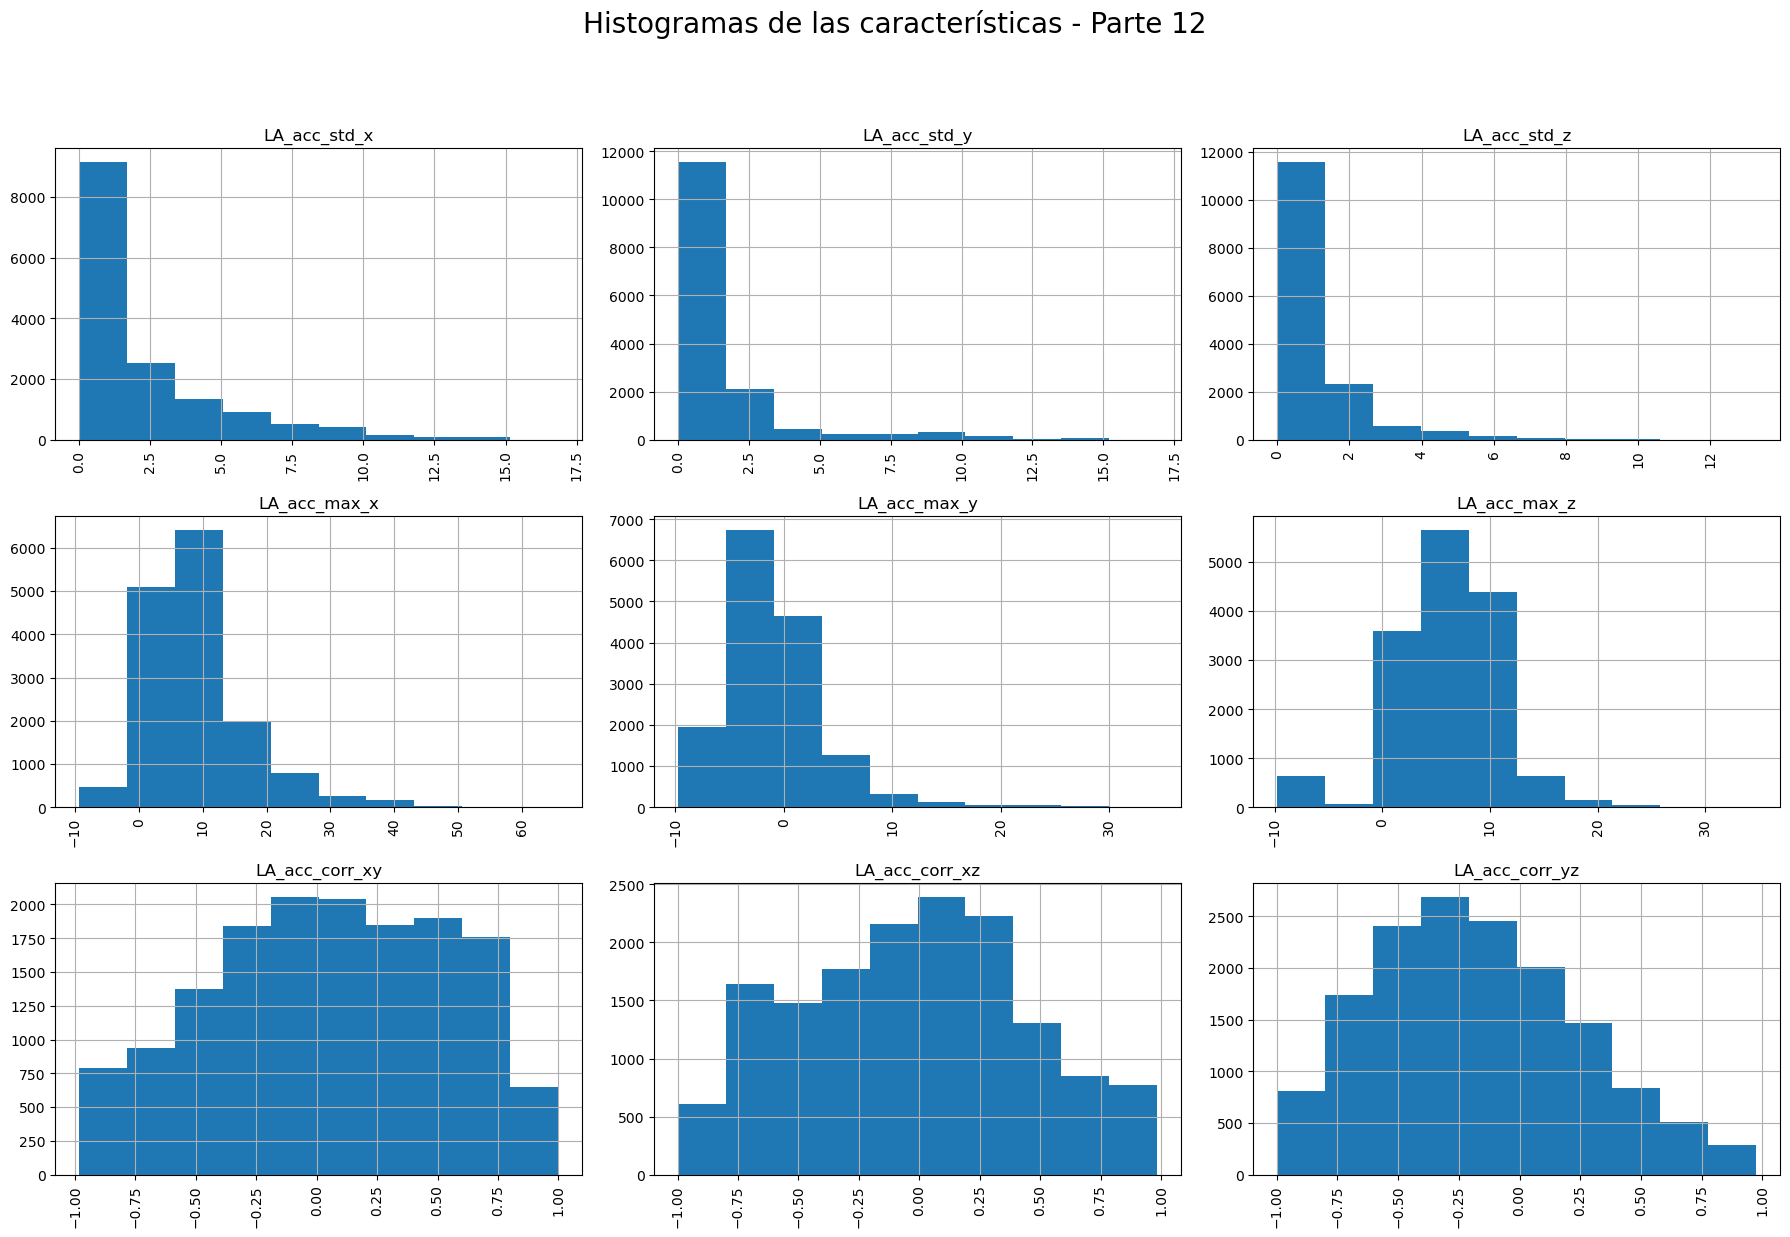

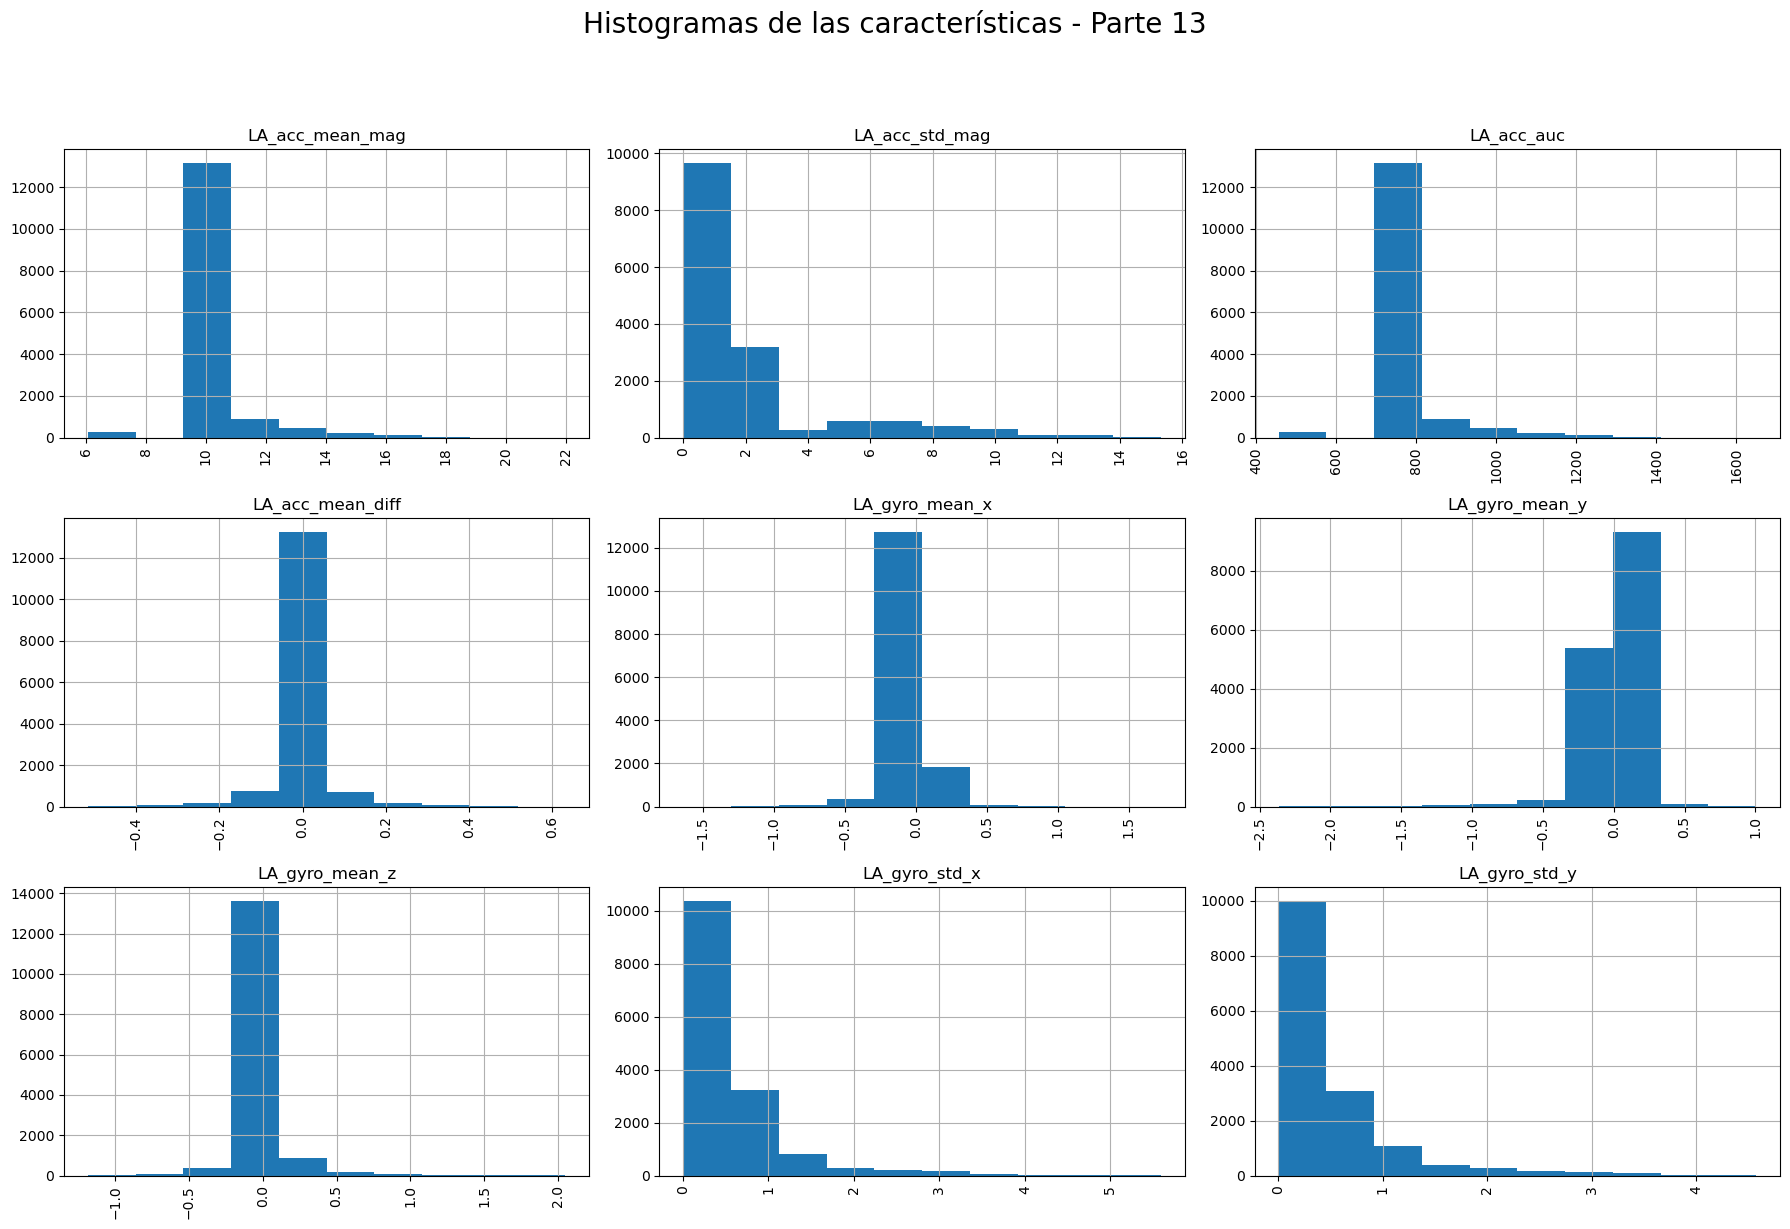

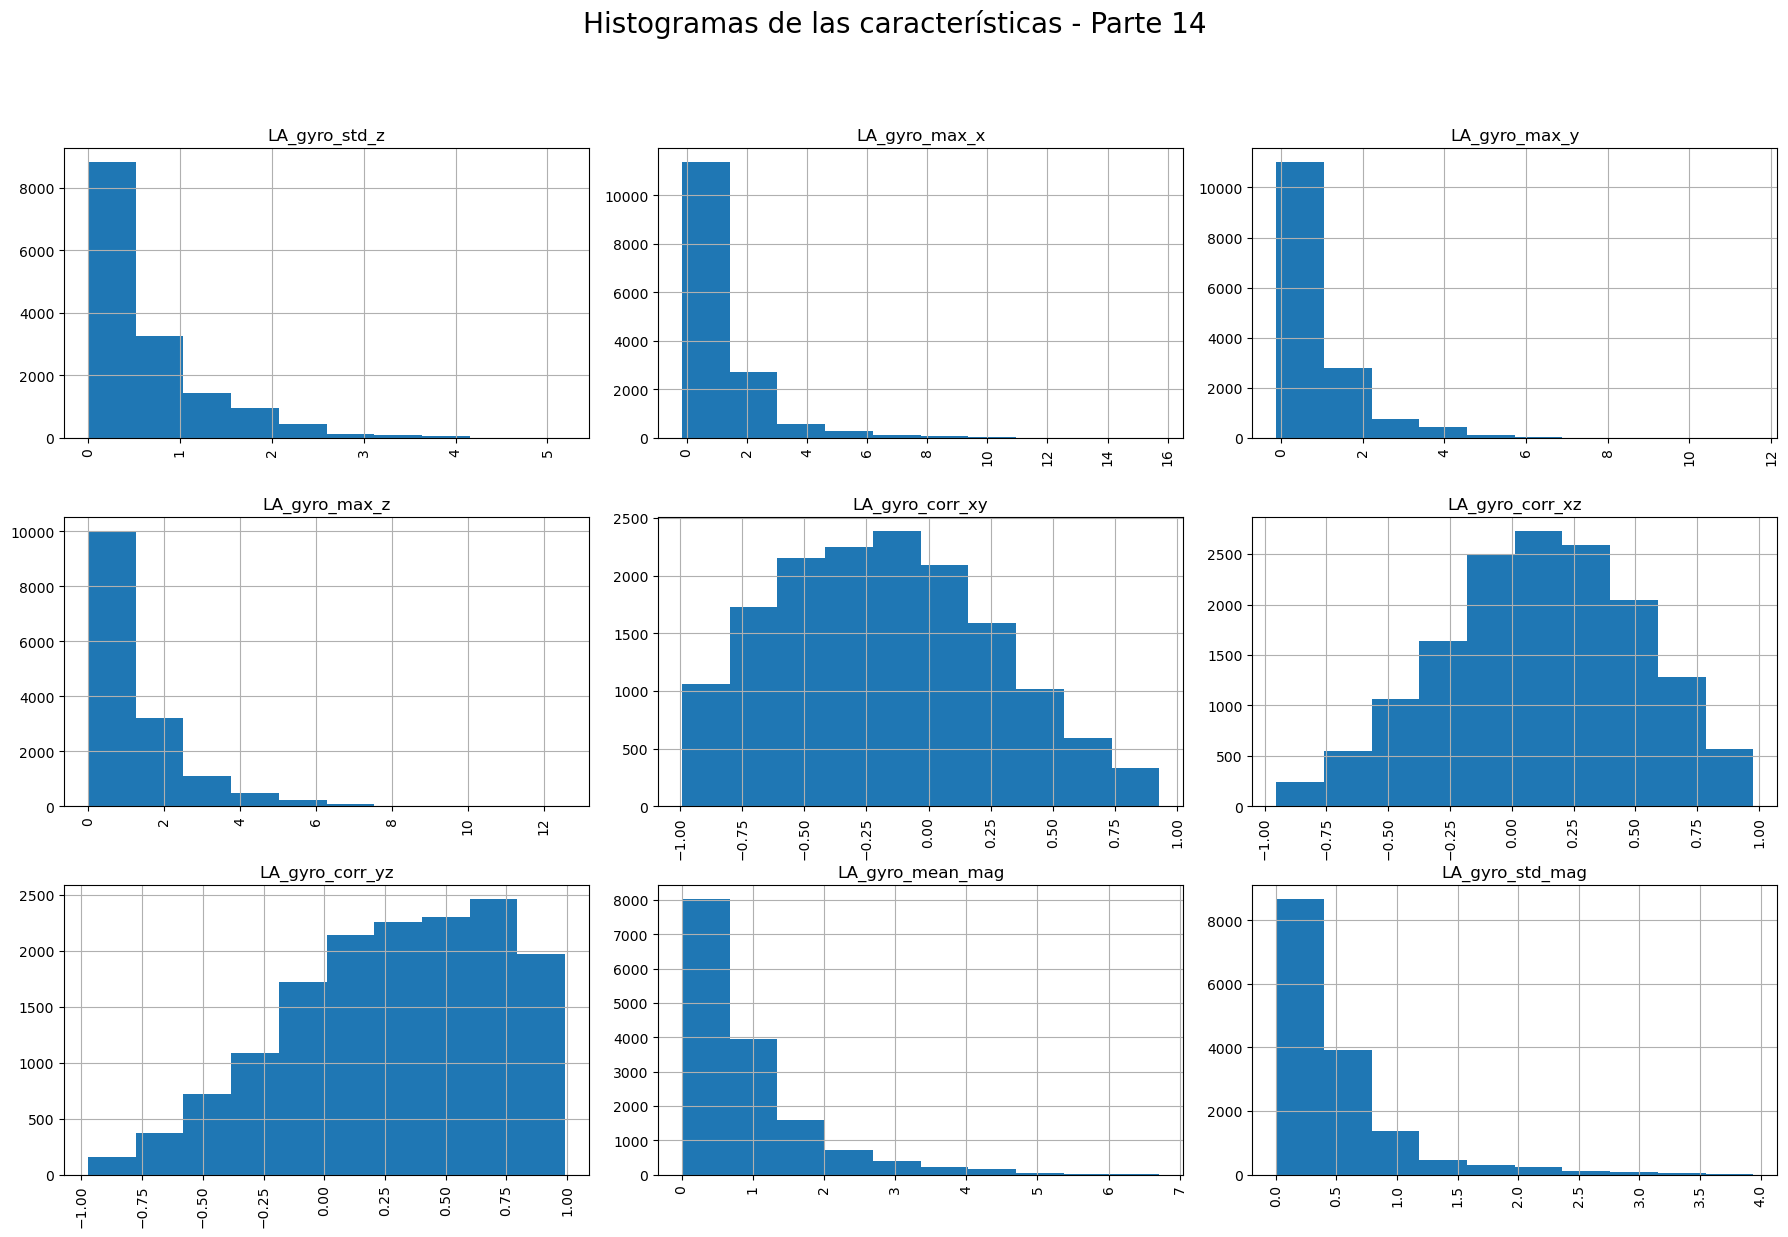

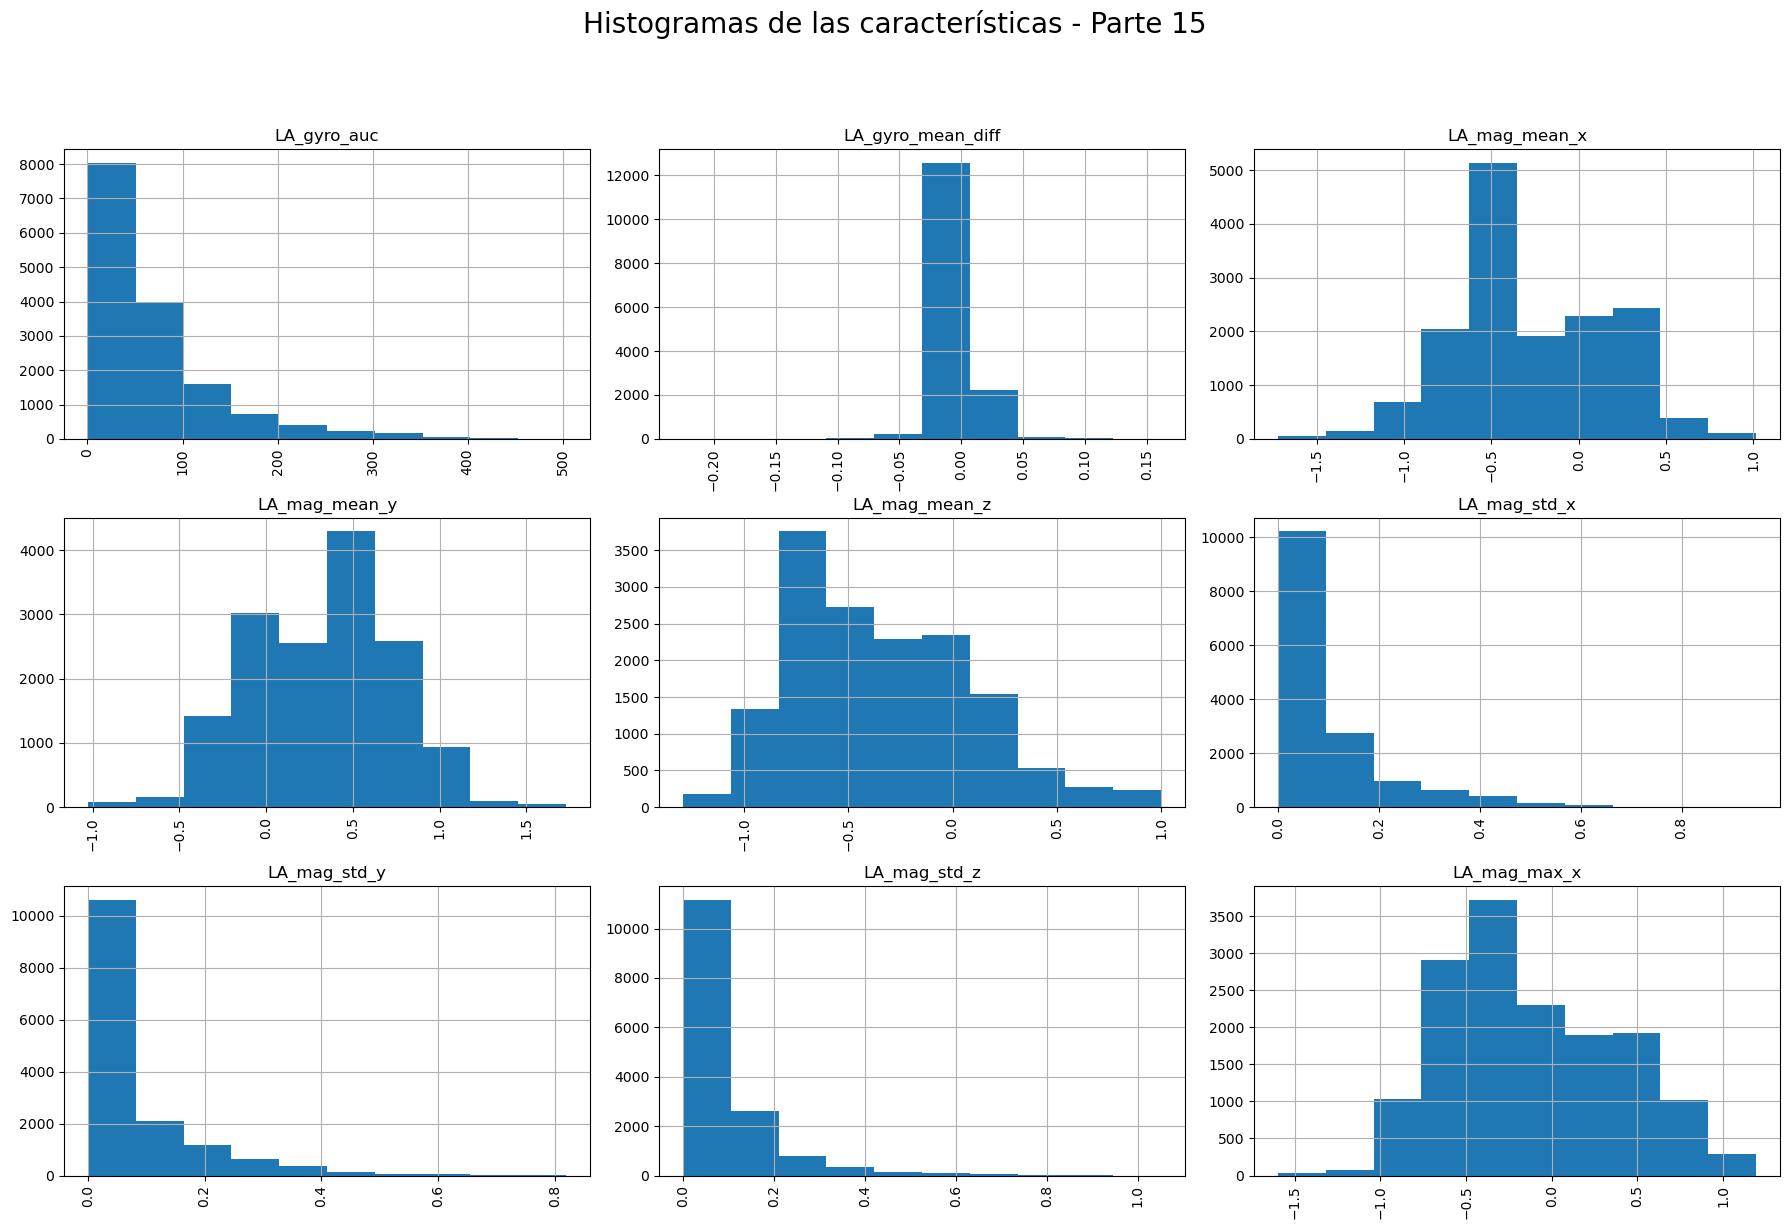

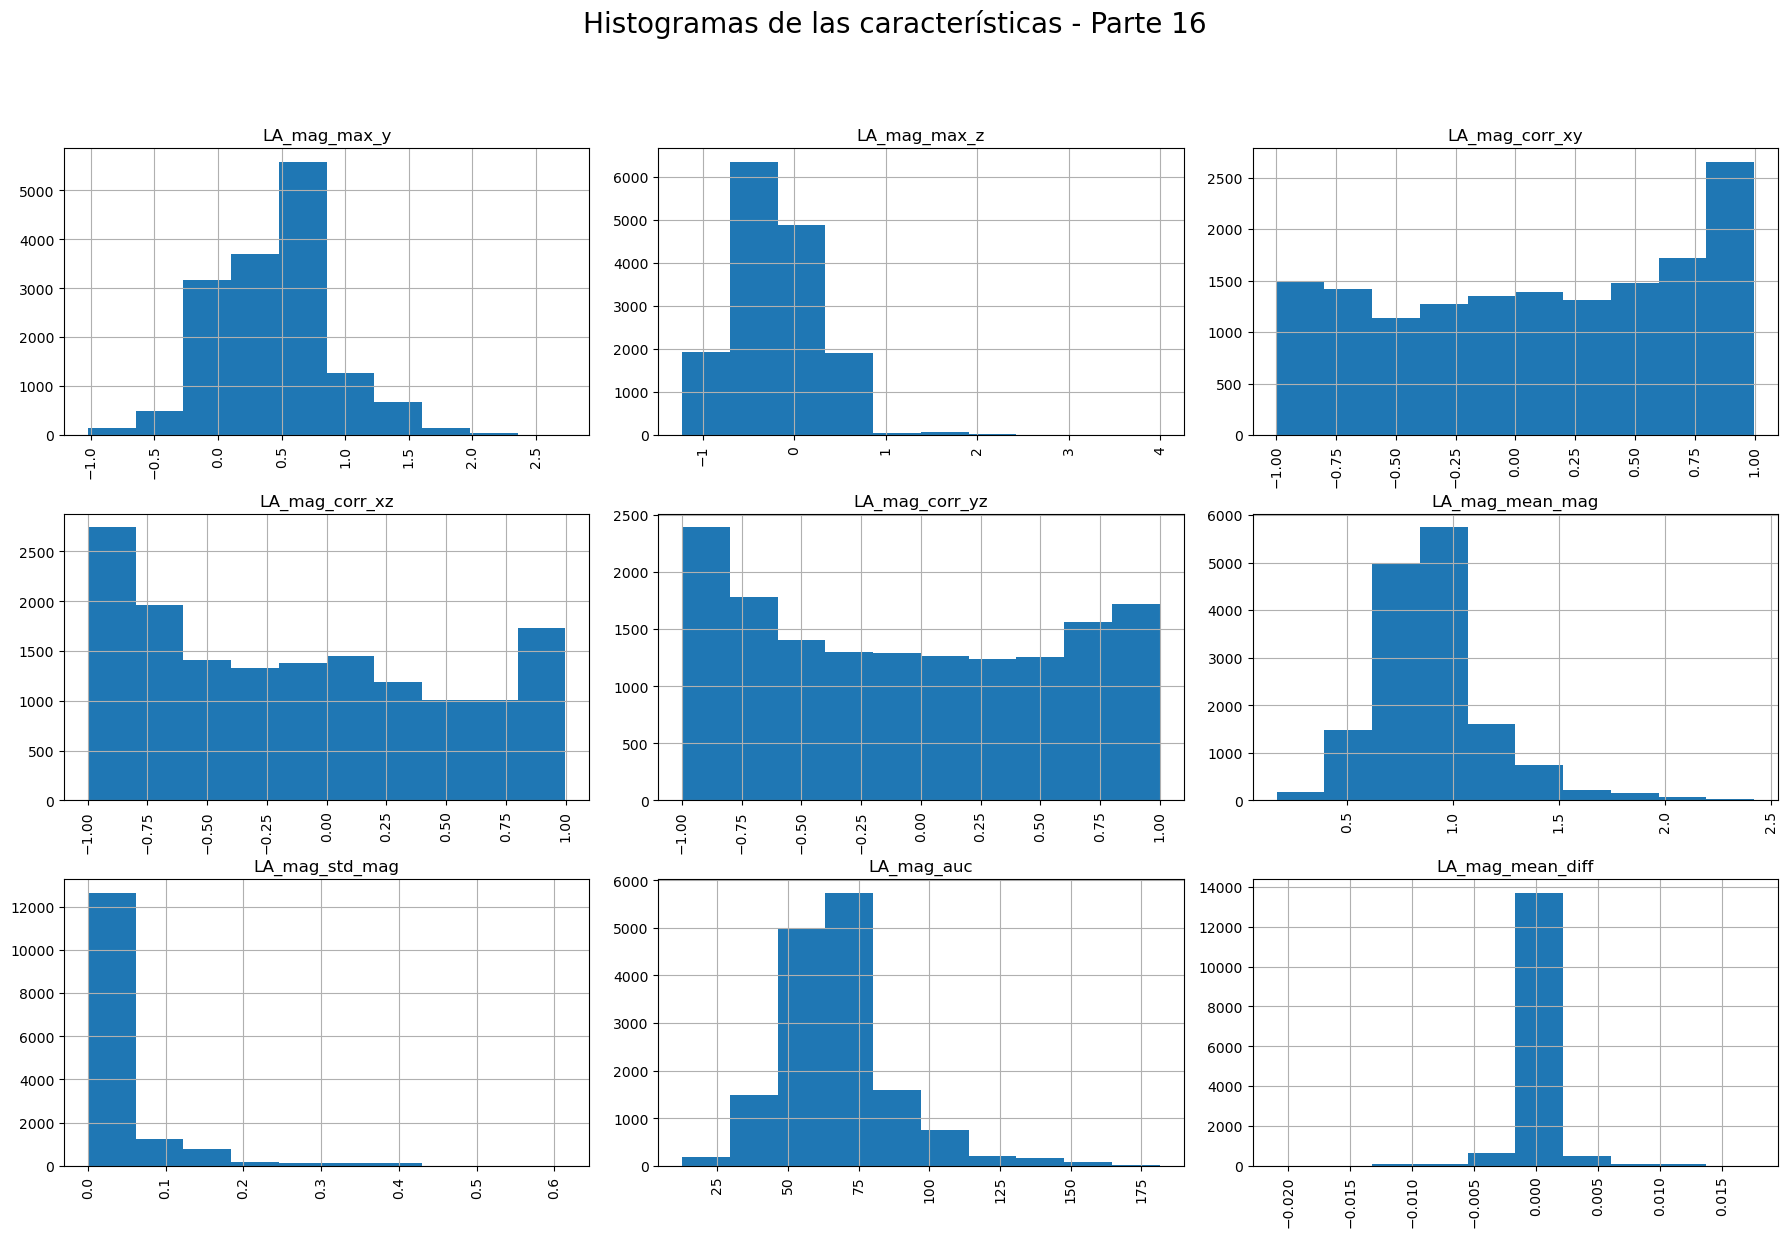

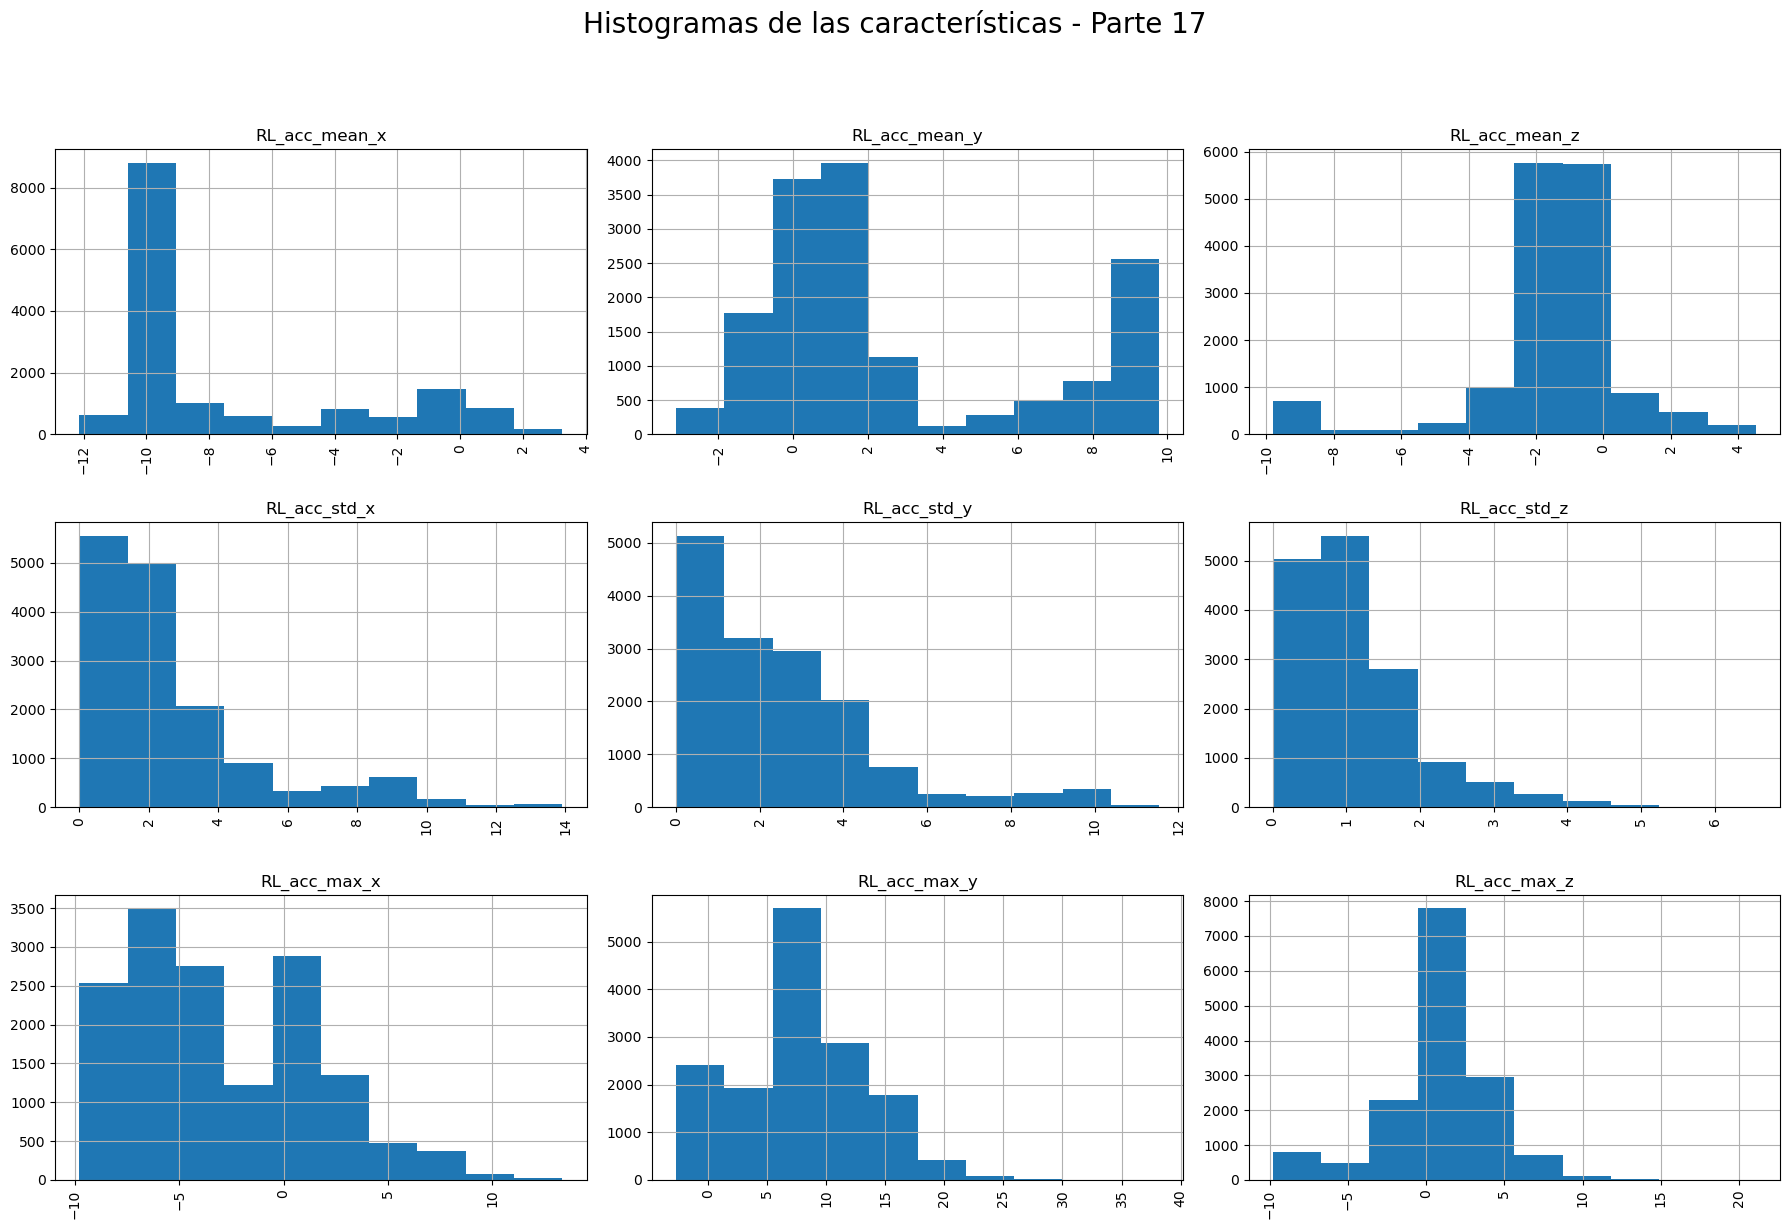

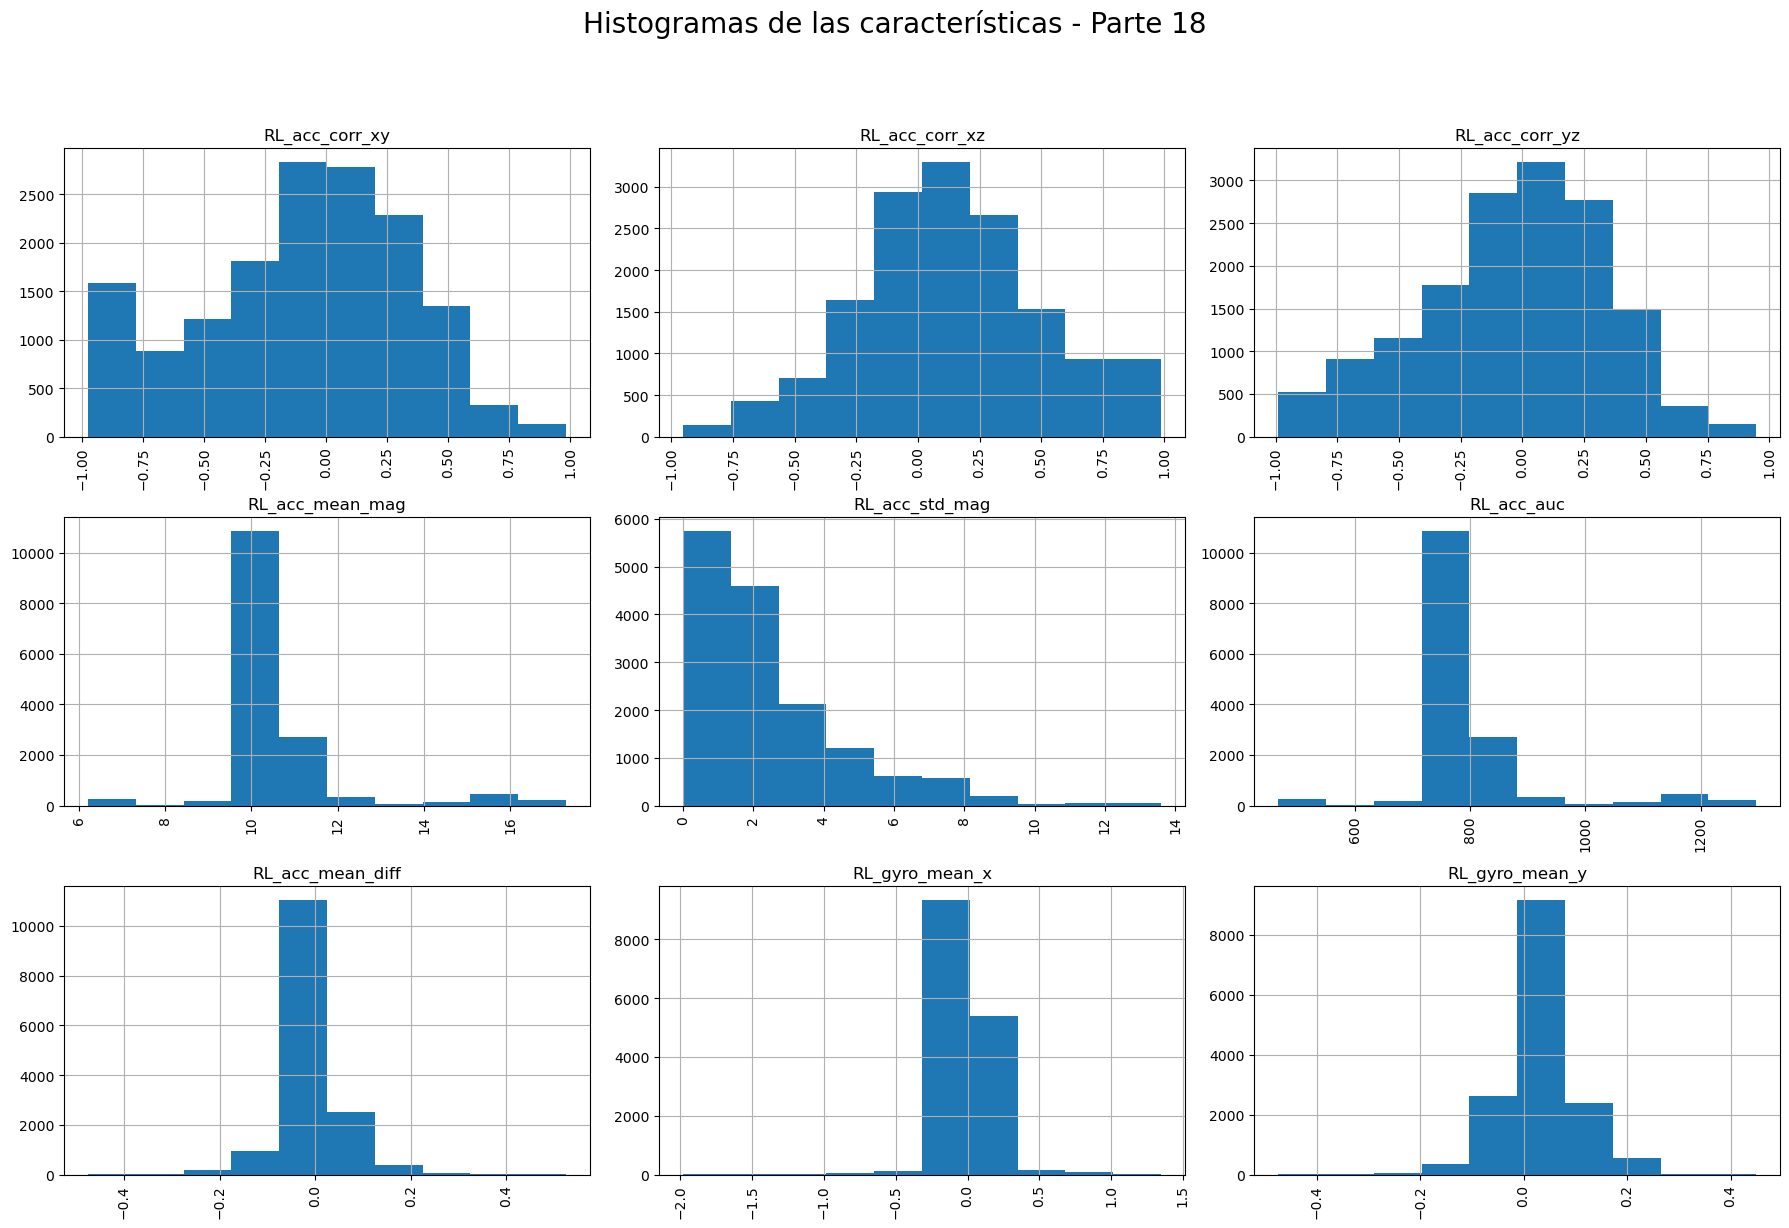

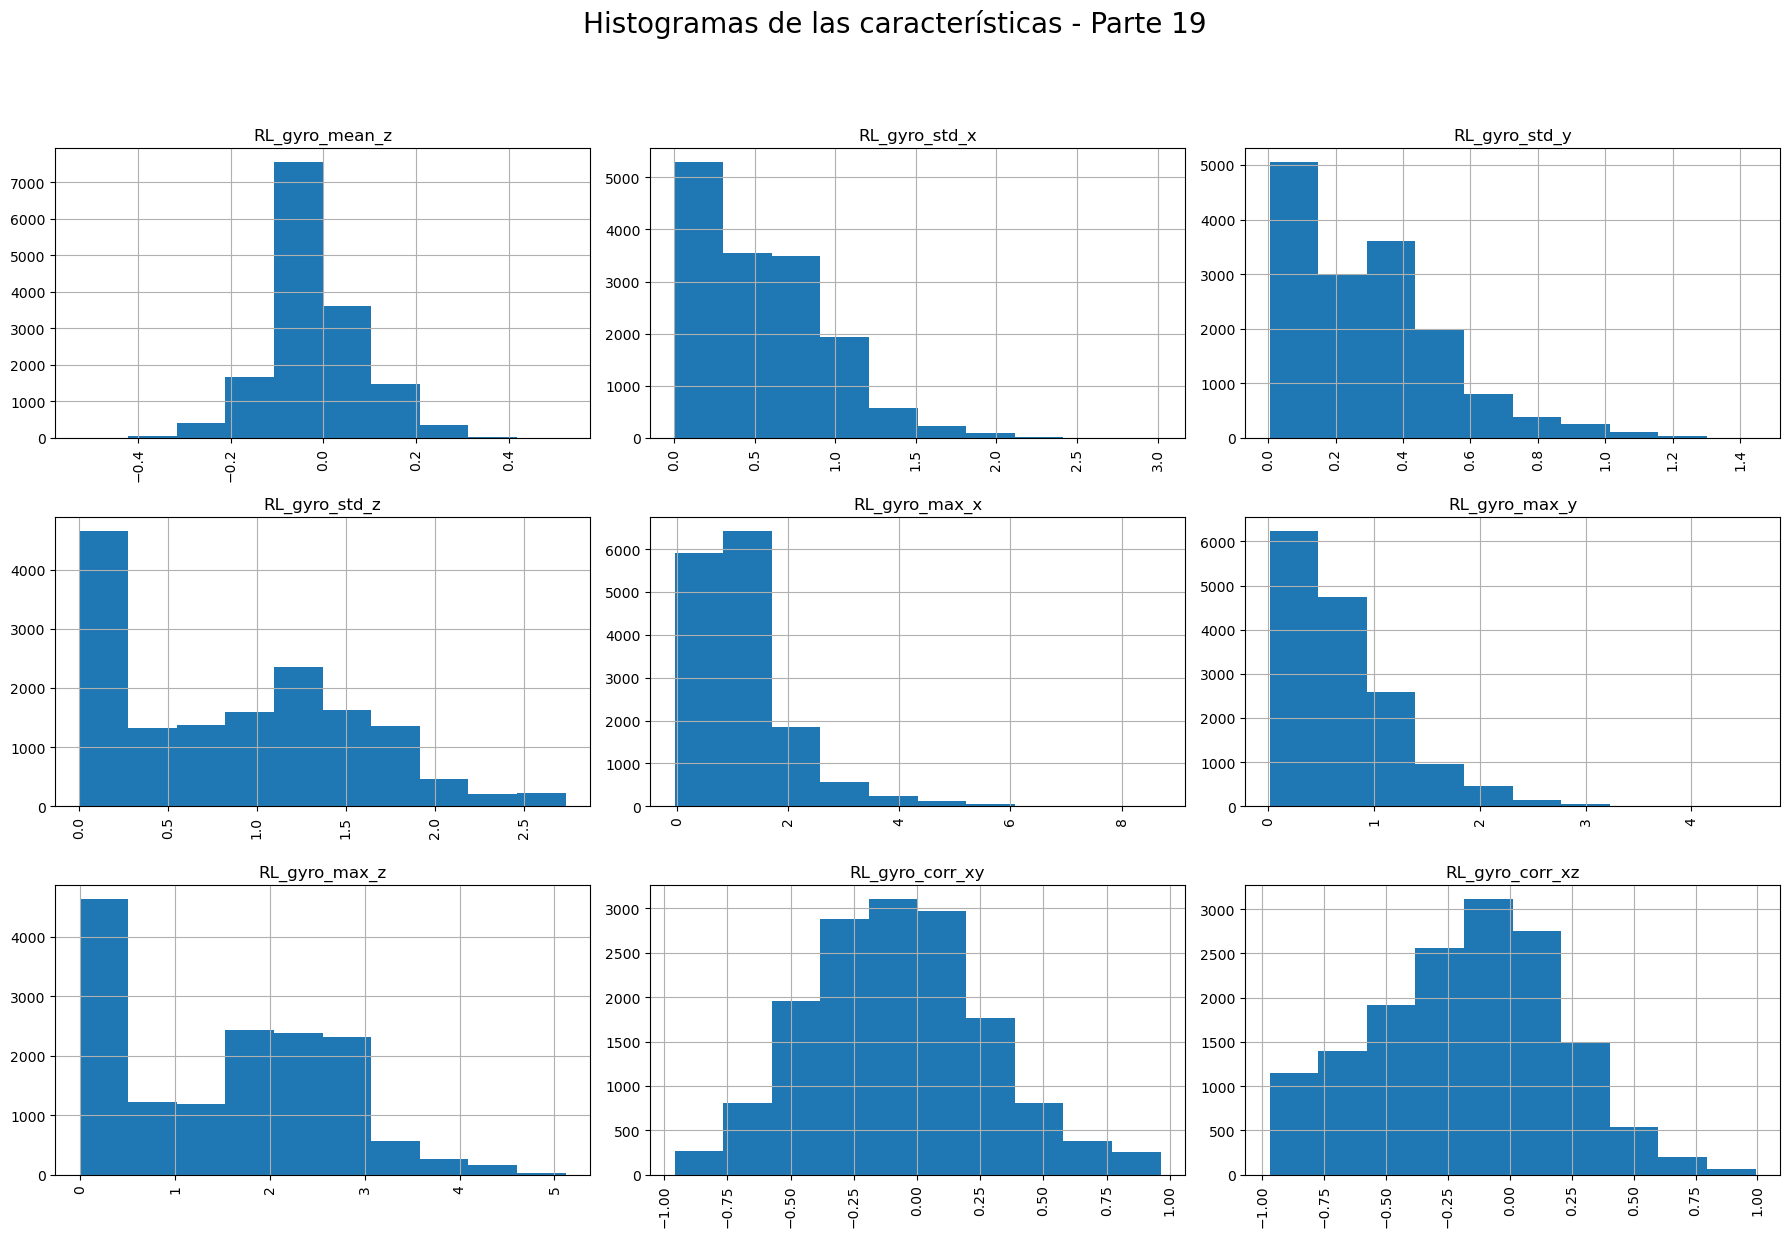

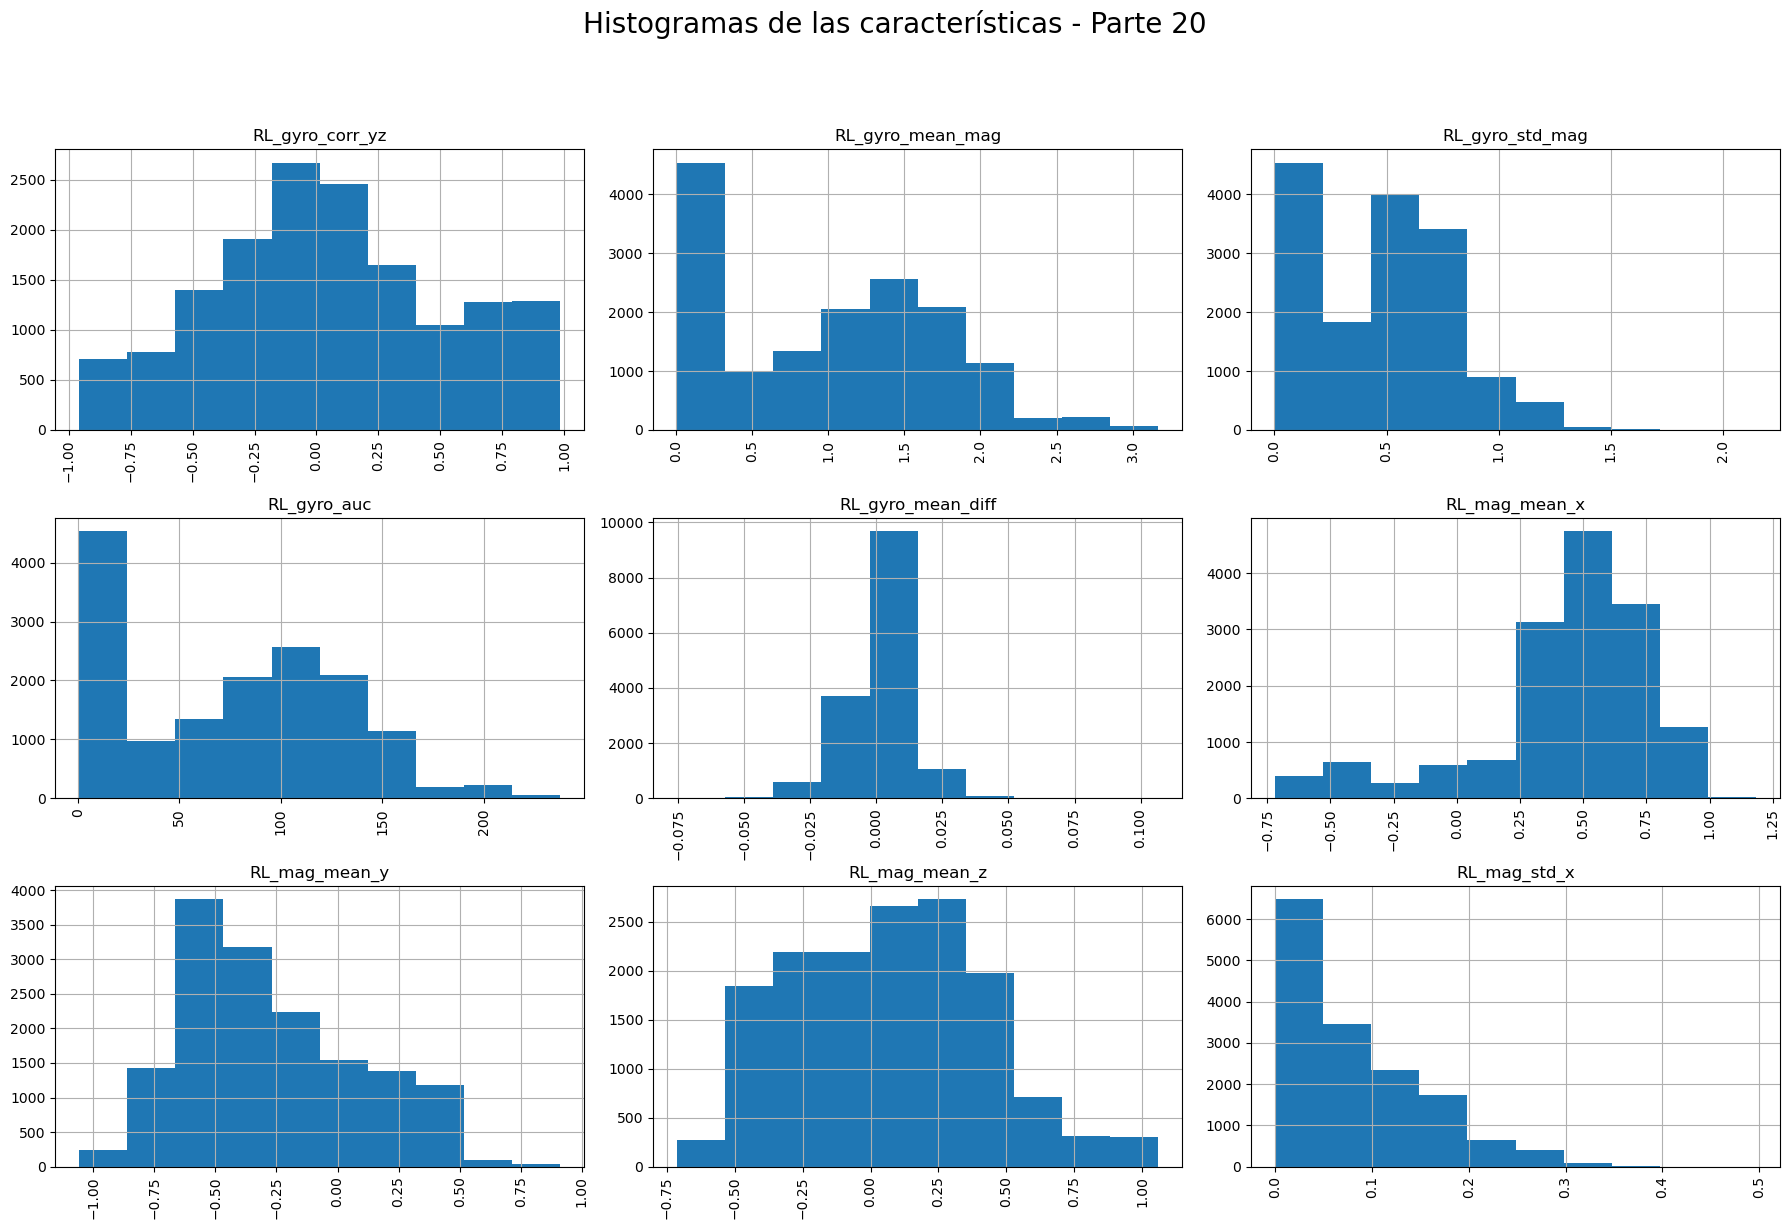

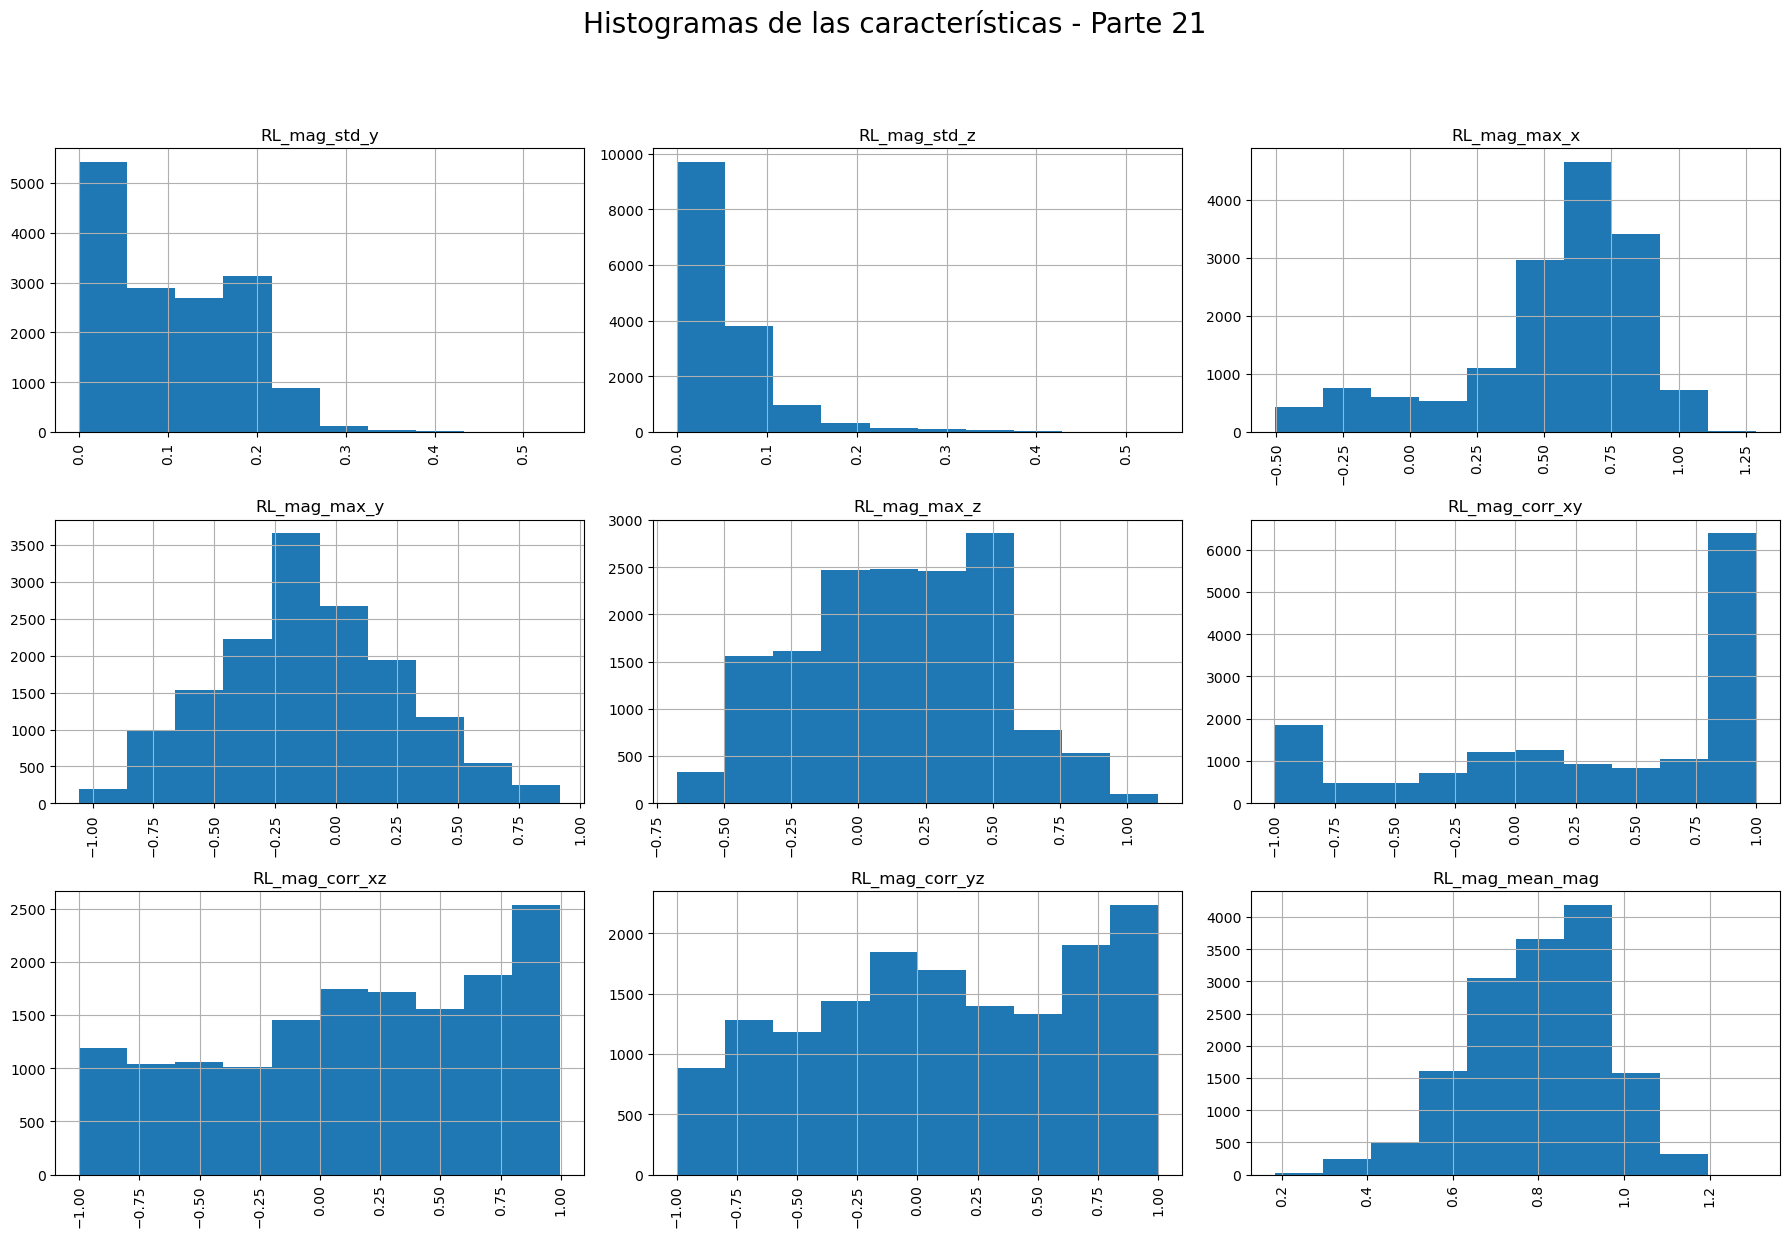

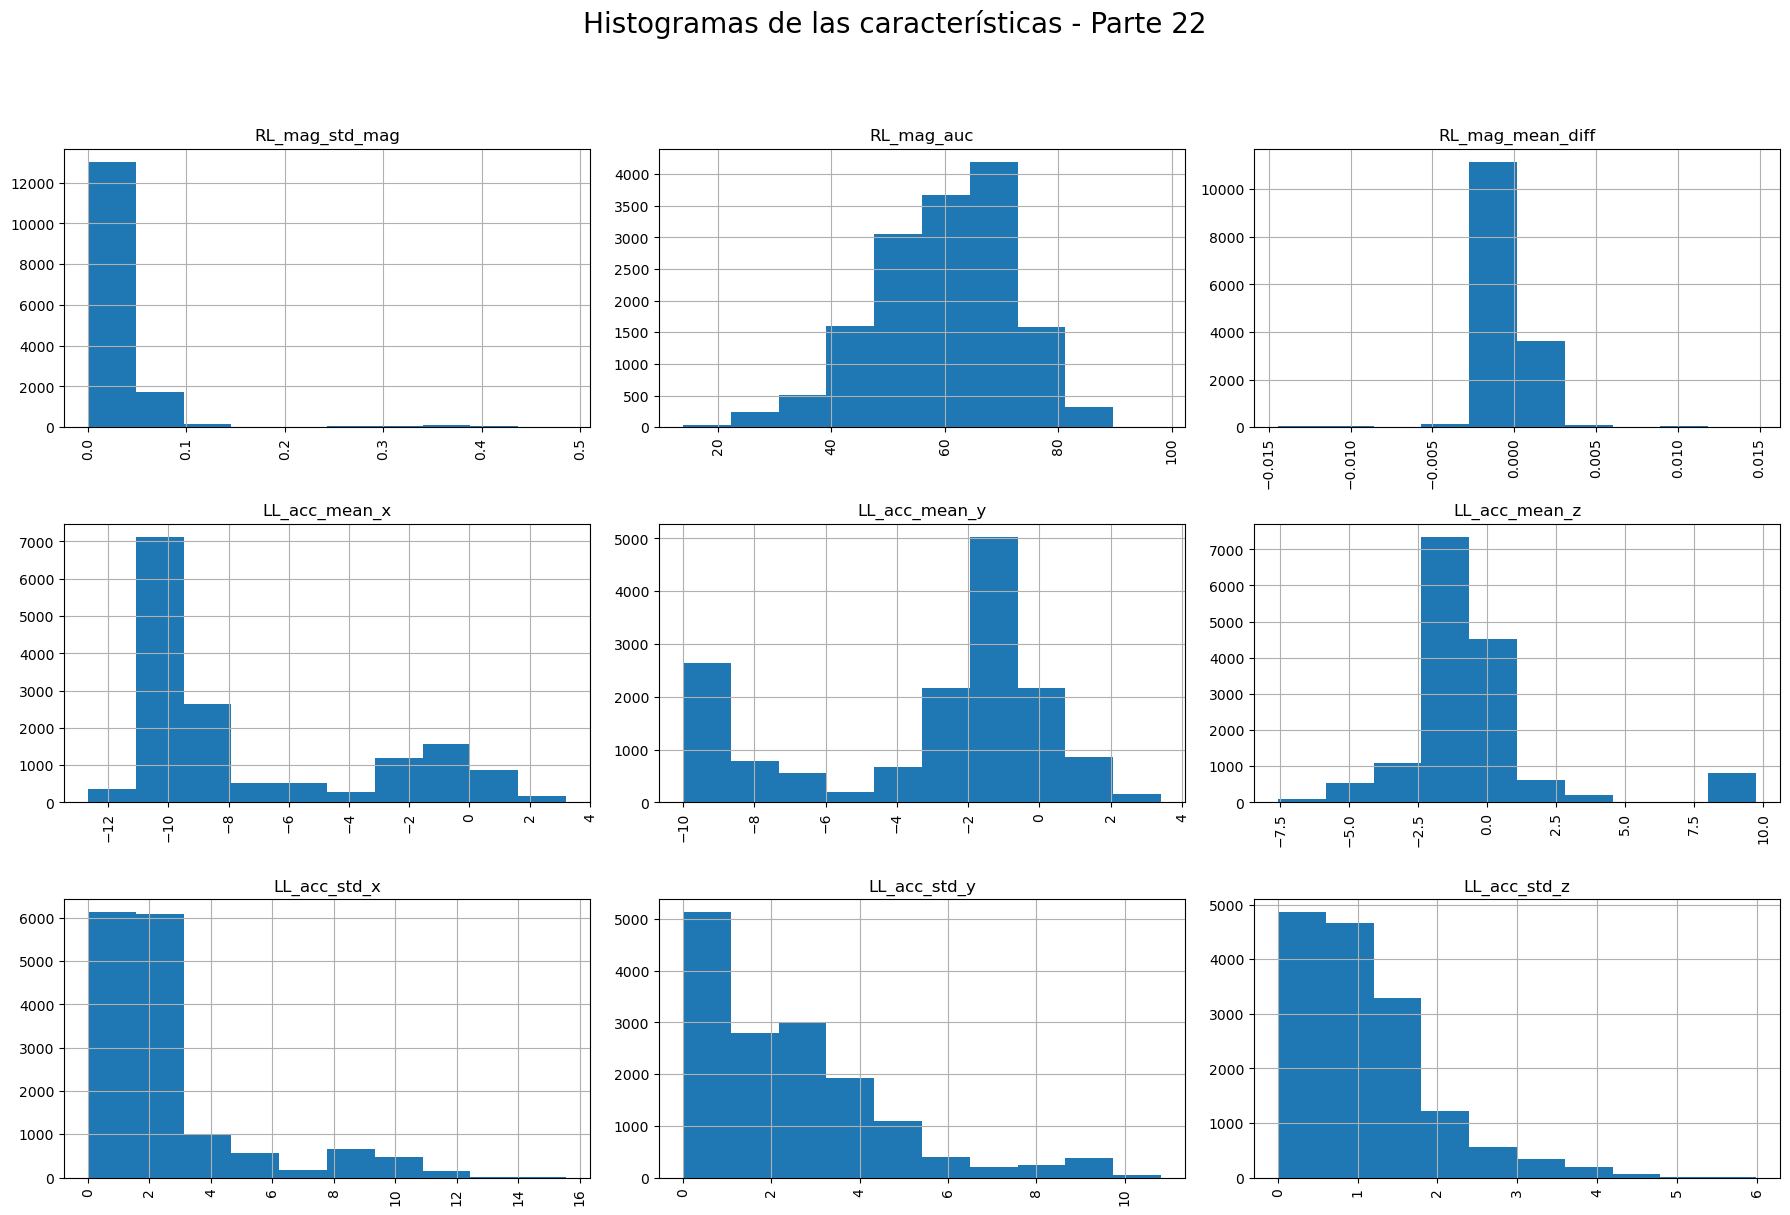

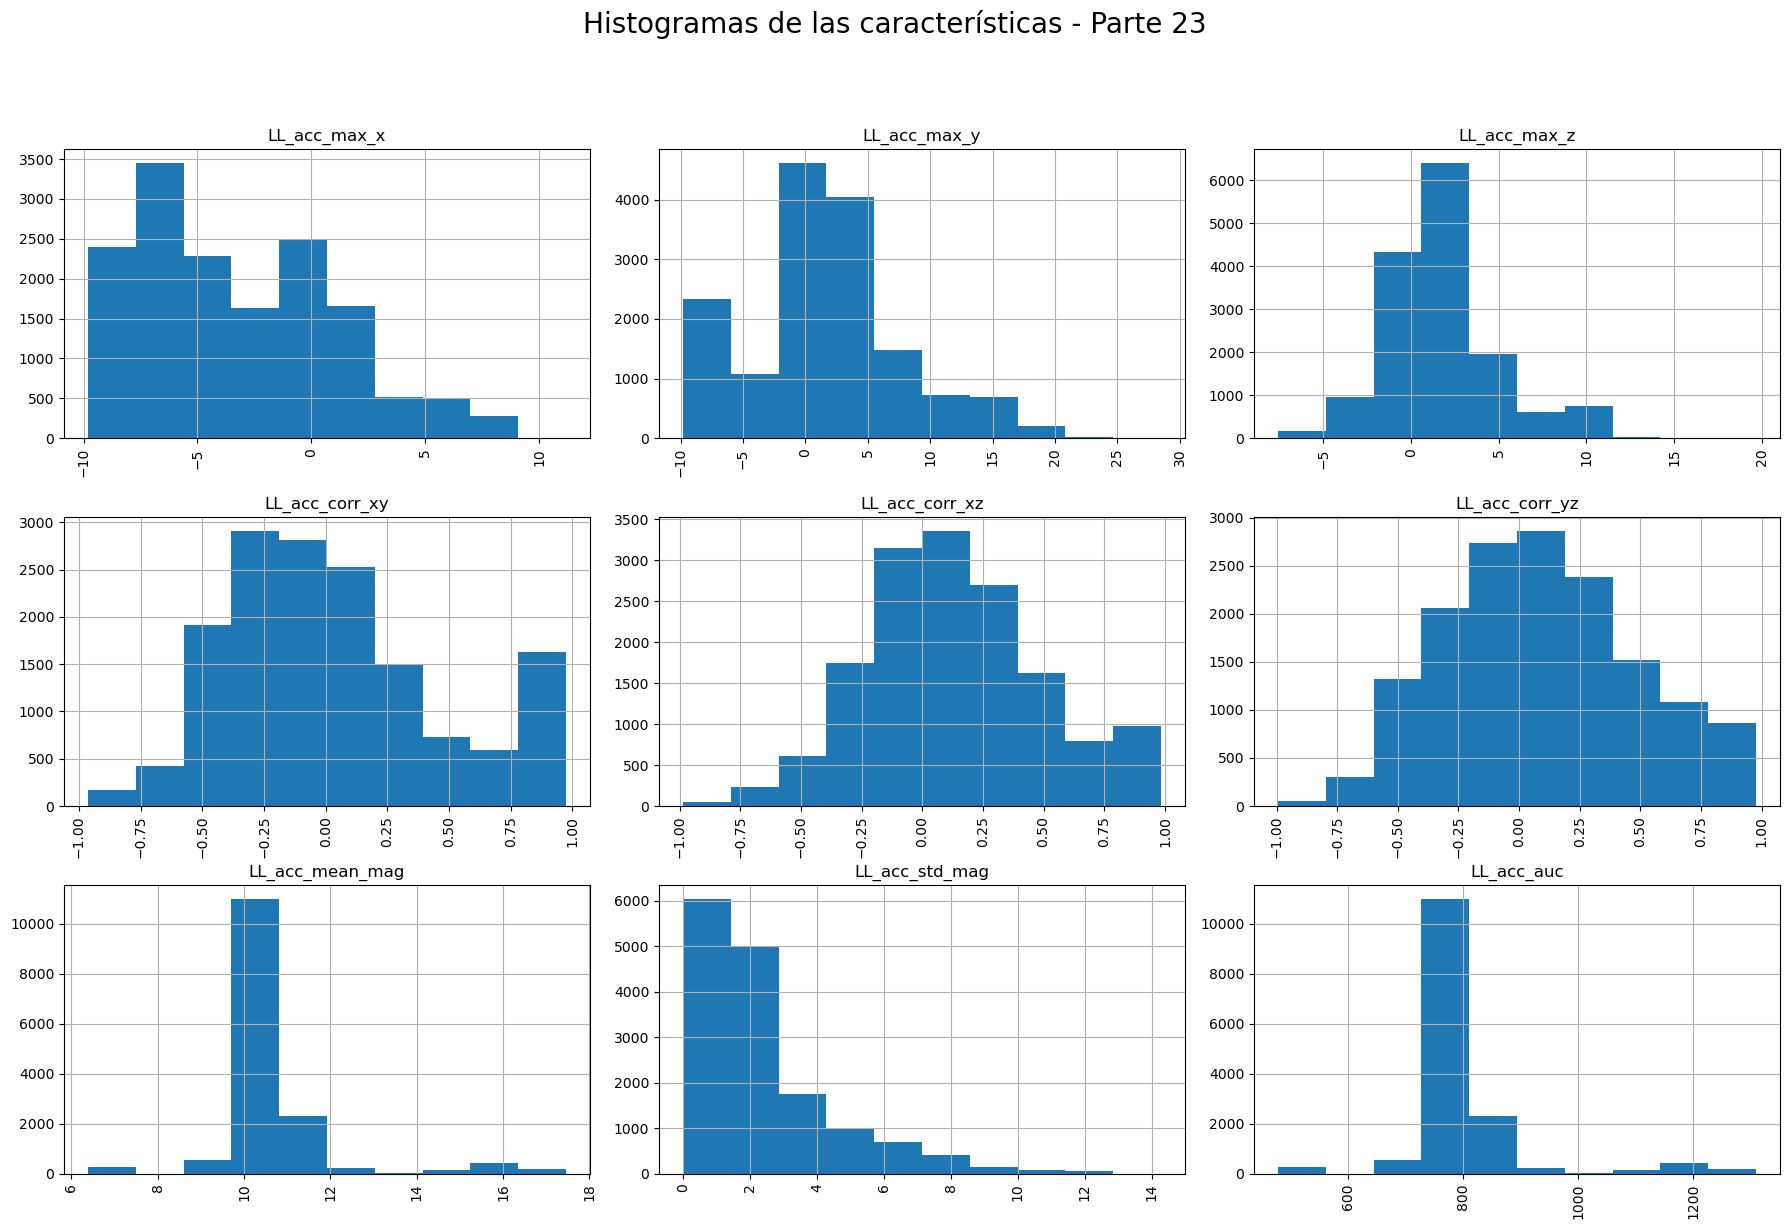

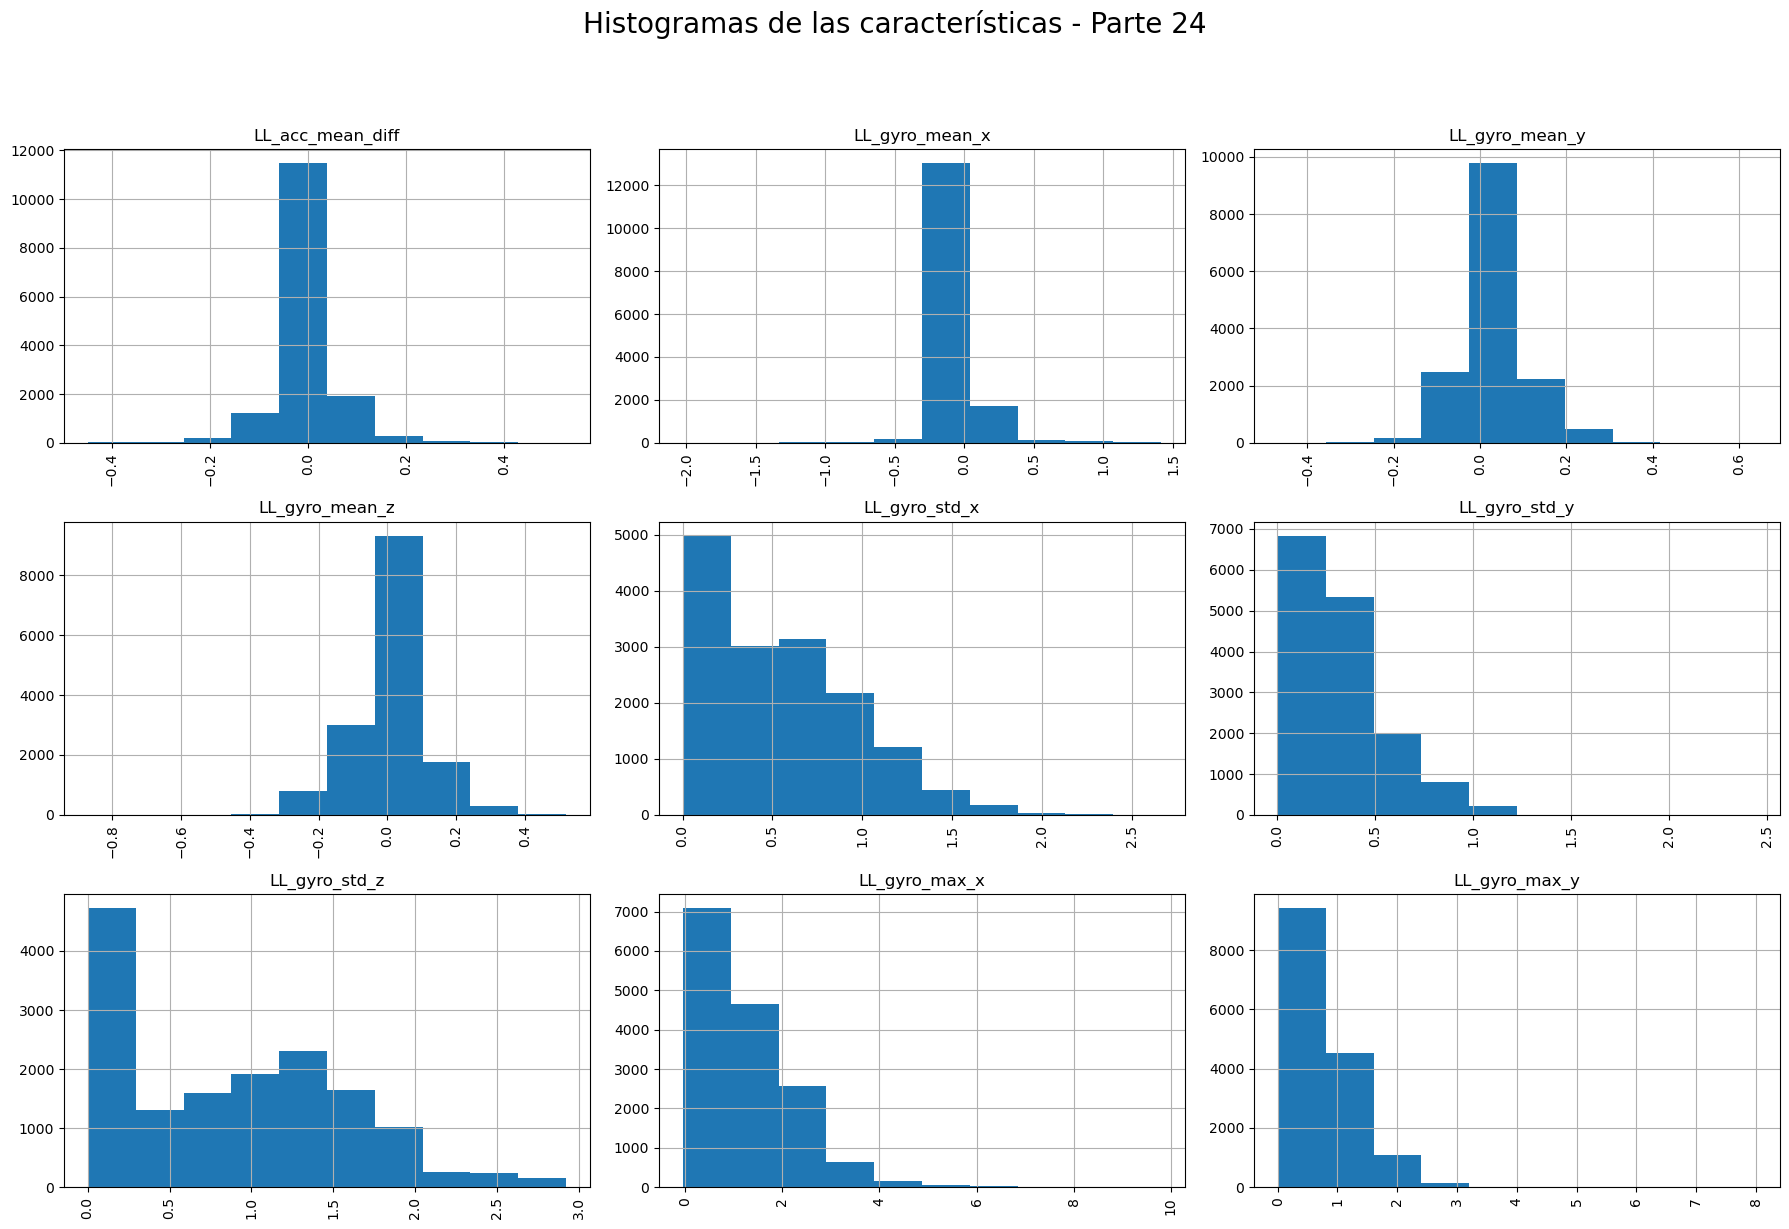

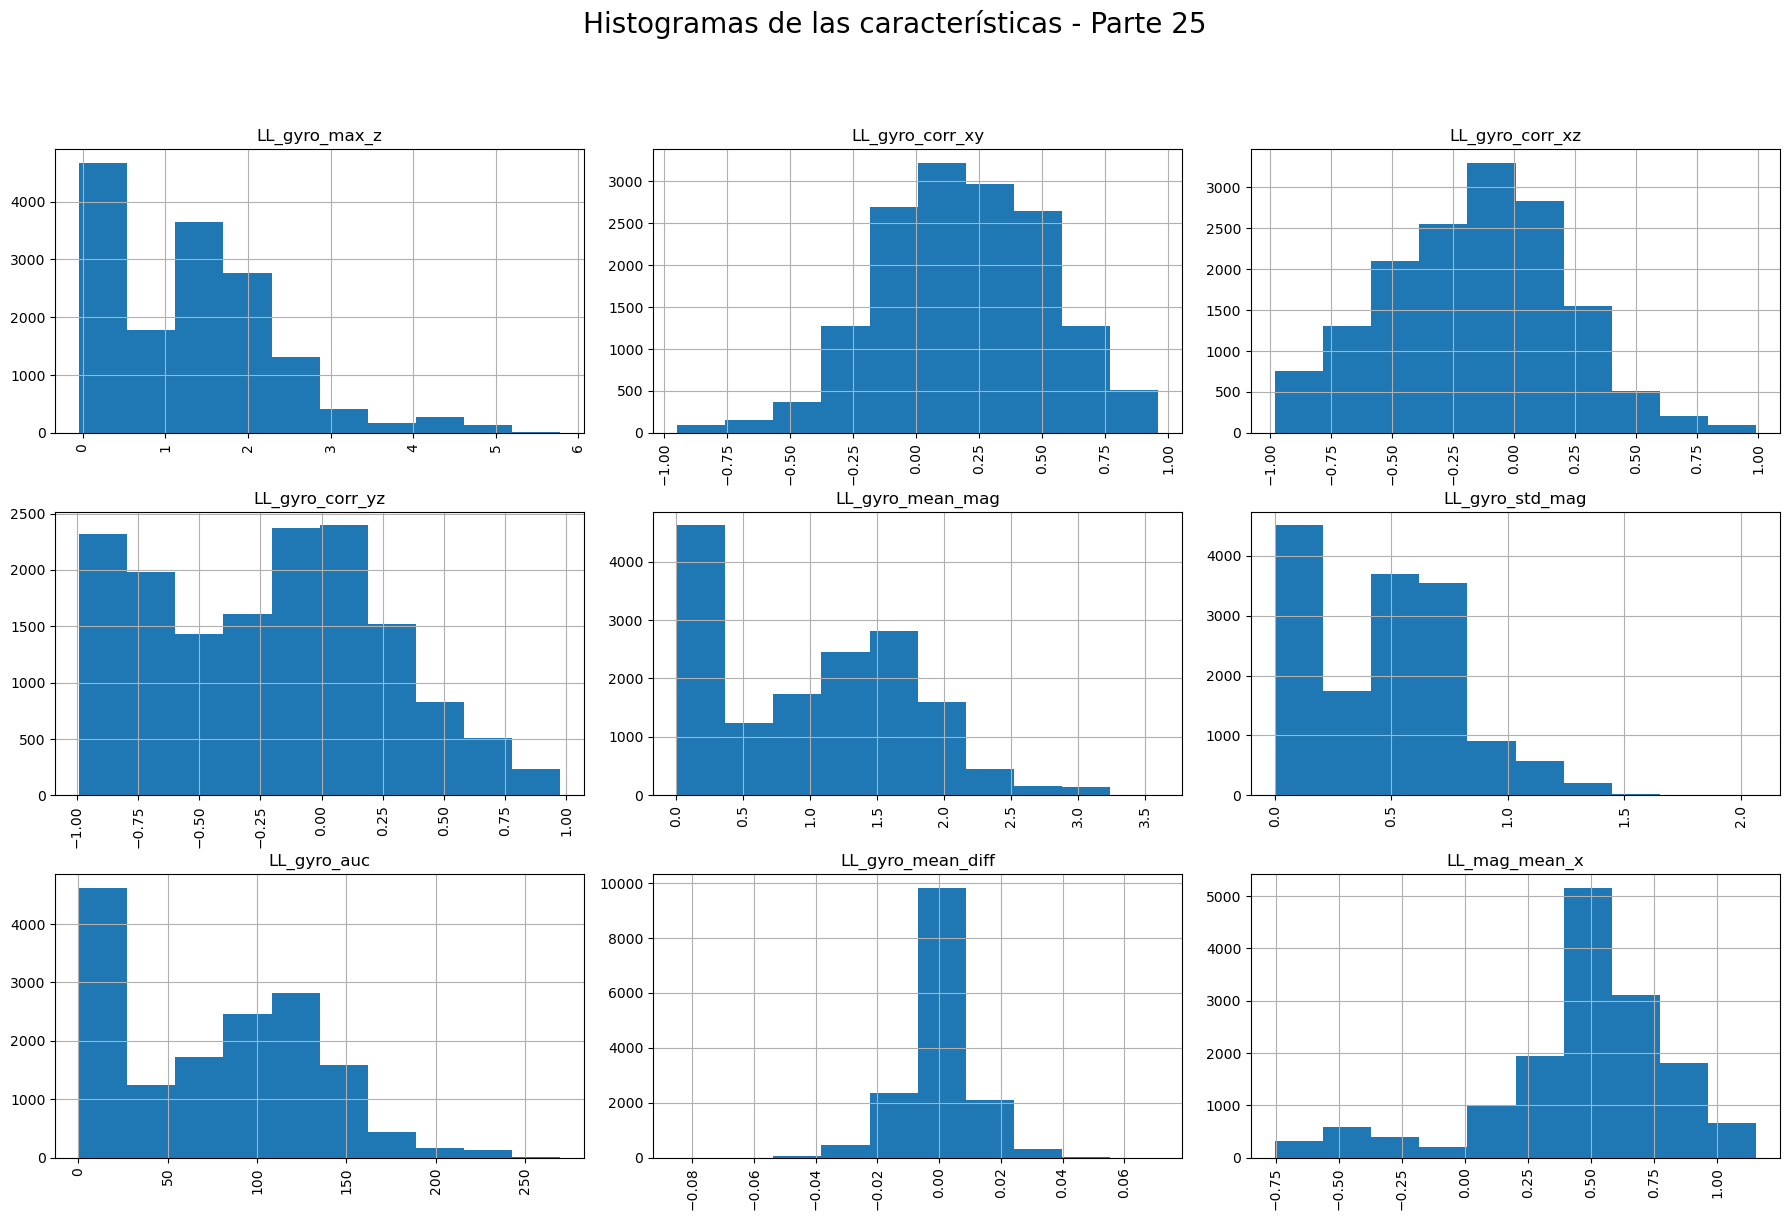

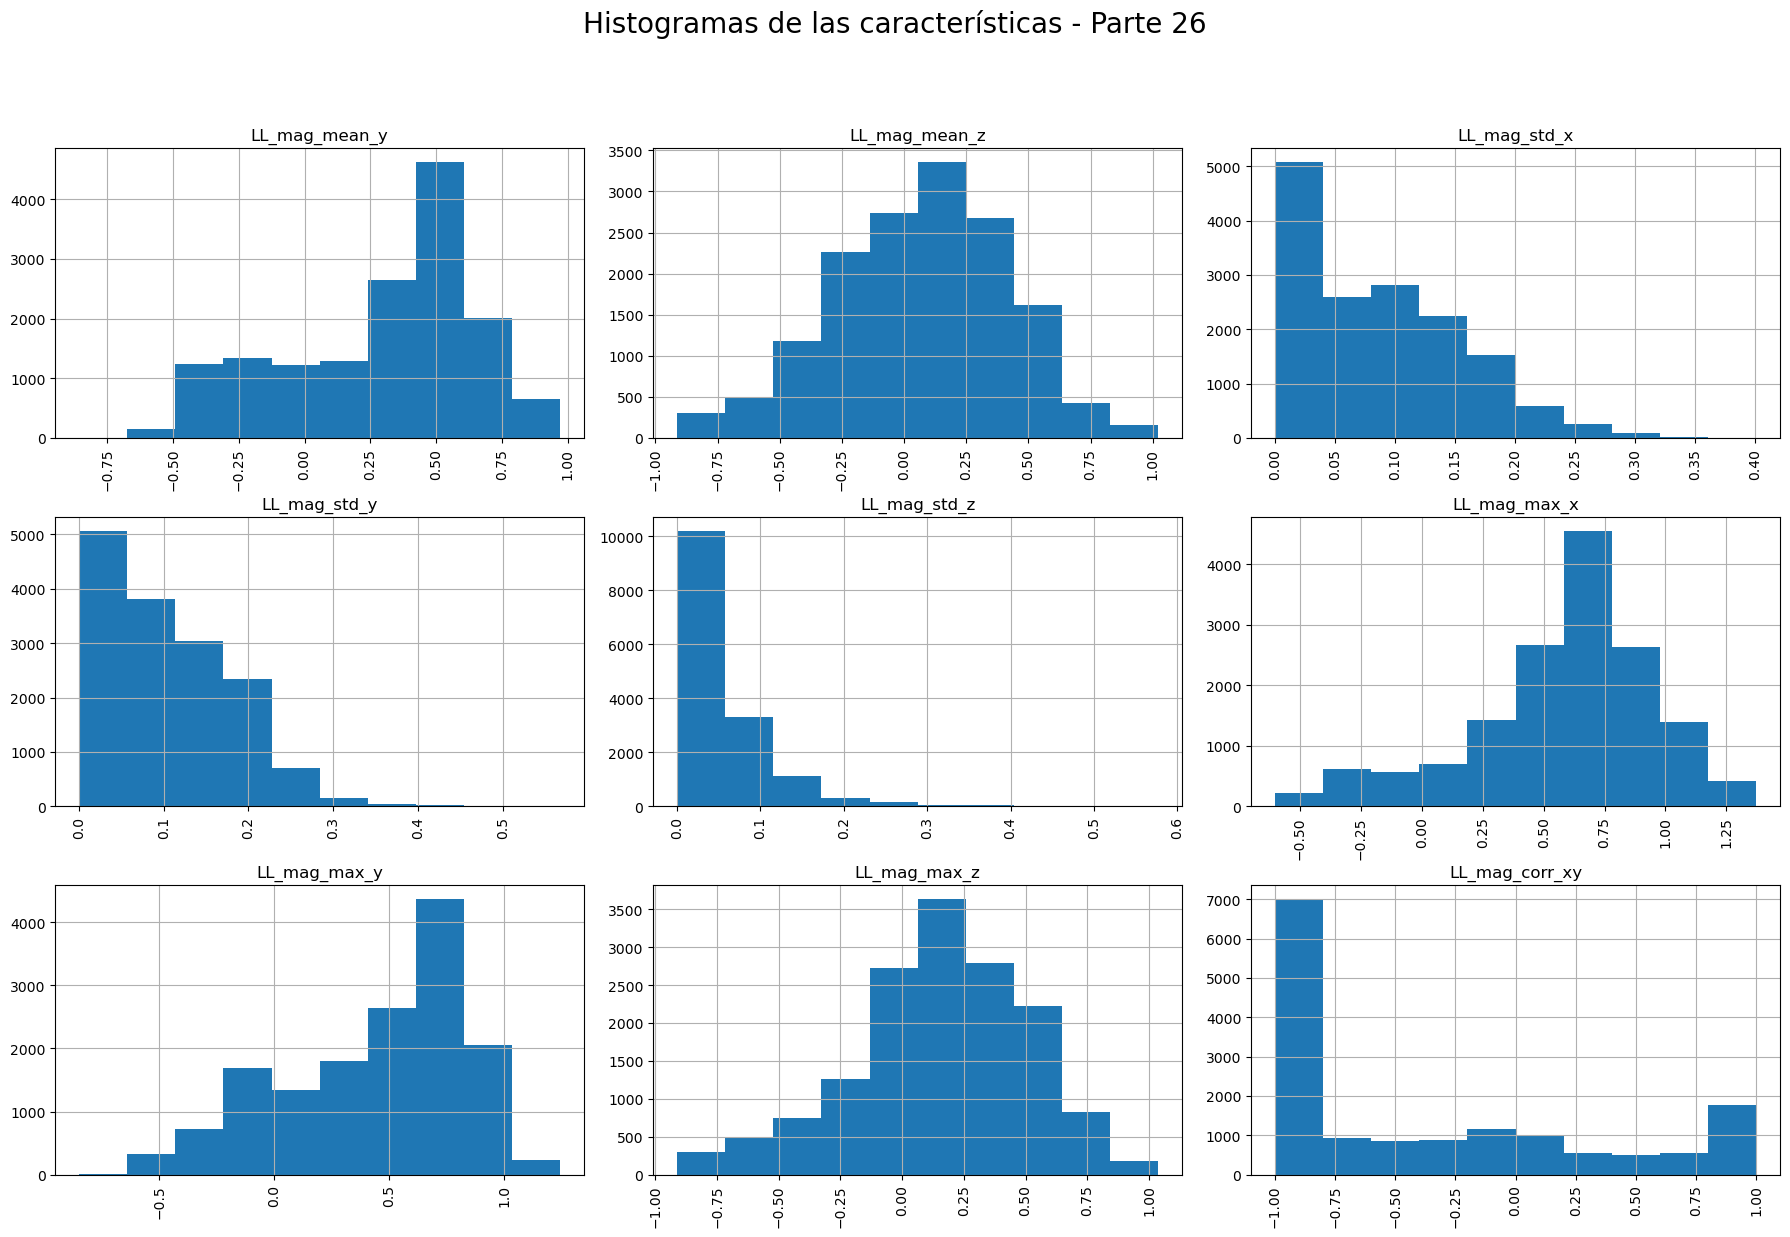

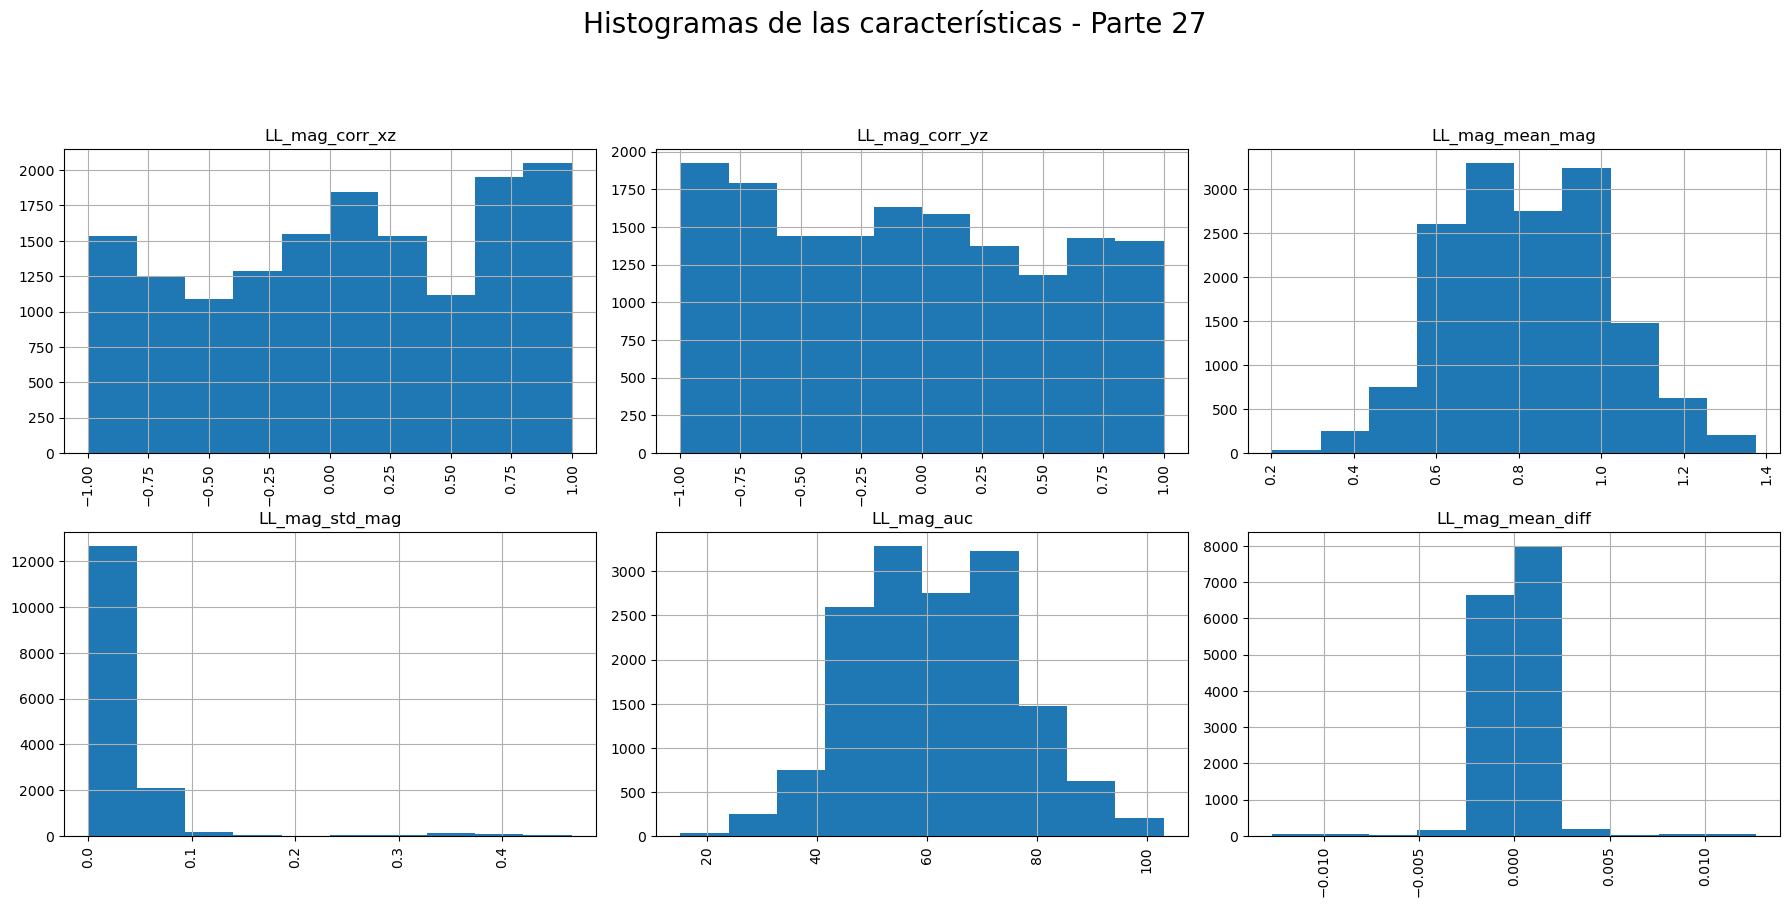

In [90]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Drop 'activity' column if it exists, keeping only numeric columns
examples_db_numeric = examples_db.drop(columns=["activity"], errors="ignore")

# Number of numeric columns
num_features = len(examples_db_numeric.columns)

# Number of features per figure (e.g., 9 for a 3x3 grid)
num_features_per_figure = 9
num_figures = math.ceil(num_features / num_features_per_figure)

# Loop through the features in chunks
for i in range(num_figures):
    # Determine the subset of features for this figure
    start_idx = i * num_features_per_figure
    end_idx = min((i + 1) * num_features_per_figure, num_features)
    features_subset = examples_db_numeric.columns[start_idx:end_idx]
    df_subset = examples_db_numeric[features_subset]
    
    # Calculate grid size for the subset
    n = math.ceil(math.sqrt(len(features_subset)))
    figsize = (6 * n, 4 * n)  # e.g., (18, 12) for n=3
    
    # Create the histograms
    axes = df_subset.hist(
        bins=10,
        figsize=figsize,
        layout=(n, n),
        sharex=False,
        sharey=False
    )
    
    # Flatten axes if it's a 2D array
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]
    
    # Adjust each subplot
    for ax in axes:
        ax.tick_params(axis='x', labelrotation=90, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)
        ax.set_title(ax.get_title(), fontsize=12)
    
    # Adjust spacing between subplots
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    
    # Add a main title
    plt.suptitle(f"Histogramas de las características - Parte {i+1}", fontsize=20, y=1.02)
    
    # Use tight_layout with a rect to prevent overlap
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

Usamos Group KFold para mantener los segmentos de ventanas de tiempo. Si no se usara las mediciones se mezclarían. Nótese que no es necesario utilizar Stratified debido a que las calses ya están balanceadas. 

## 2.3. Escalamiento, normalización o estandarización de características

In [91]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

Se utiliza **StandardScaler**. Pero es importante aplicarlo por separado en el set de entrenamiento y en el de prueba para evitar data leakage. Para tener mayor certeza en el desempeño del clasificador, se utilizará Cross Validation. Por todo esto es importante realizar el Cross Validation antes de aplicar la transformación.

## 2.4. Train/test split: cross validation

Usamos Group KFold para mantener los segmentos de ventanas de tiempo. Si no se usara las mediciones se mezclarían. Nótese que no es necesario utilizar Stratified debido a que las calses ya están balanceadas. 

In [92]:
from imblearn.pipeline import make_pipeline

Solo para probar que sí sirve, usamos un NB Gaussiano. Elejimos el NB gaussiano ya que es una forma rápida de hacer un modelo sencillo y rápido que no depende de la escala. Esto porque no puedo garantizar que las esclas estén bien después de usar MinMax porque no se probaron supuestos. 

In [93]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [94]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

Fitteamos el modelo

In [95]:
pipe1 = make_pipeline(
    scaler, 
    nb
)

In [96]:
pipe1.fit(X, y_encoded)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussiannb', GaussianNB())])

In [97]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
pca = PCA(n_components=0.95)
    
pipe = make_pipeline(scaler, pca, nb)
    
pipe.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('pca', PCA(n_components=0.95)), ('gaussiannb', GaussianNB())])

In [106]:
from sklearn.model_selection import cross_val_score

scorespipe = cross_val_score(pipe1, X, y_encoded, cv=10, scoring="f1_macro")
scorespipe

array([0.96031823, 0.96815303, 0.96419266, 0.93962648, 0.88531662,
       0.94782094, 0.96475503, 0.96074391, 0.94260619, 0.89032285])

In [107]:
np.average(scorespipe)

0.9423855935192215

# 3. Métodos de aprendizaje máquina

## 3.1. División Train/test

Este proceso se realizó en la sección **2.4. Train/test split: cross validation**

## 3.2. Entrenamiento con tres clasificadores

Definimos los datos a utilizar:

In [132]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Tomamos la misma pipeline que ya teníamos y solo cambiamos el clasificador. 

Definimos el código de la pipeline para que sea re-utilizable

In [136]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()

def pipeleanear(model, X, y): 
    pipe = make_pipeline(scaler, model)
    pipe.fit(X, y)
    scorespipe = cross_val_score(pipe, X, y, cv=10, scoring="f1_macro")
    print(scorespipe)
    print(np.average(scorespipe))
    return scorespipe

### 3.2.1. Bayes Ingenuo

In [138]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipeleanear(nb, X, y_encoded)

[0.95820842 0.95507744 0.95147087 0.9362876  0.90376967 0.94966713
 0.94944807 0.94659757 0.93080878 0.85924012]
0.9340575651108528


### 3.2.2. Regresión Logísitica

In [140]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_results = pipeleanear(lr, X, y_encoded)

[0.98486711 0.99404969 0.99004772 0.99142663 0.9927504  0.97915223
 0.98038959 0.99205547 0.96955461 0.95090826]
0.9825201705578003


### 3.2.2. Bosques aleatorios

In [141]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_results = pipeleanear(rf, X, y_encoded)

[0.98209929 0.99537642 0.99604939 0.99281032 0.98065388 0.98163139
 0.99212274 0.99736426 0.97849753 0.96790597]
0.9864511172881919


### 3.2.3. Perceptron

In [142]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_results = pipeleanear(perceptron, X, y_encoded)

[0.9888034  0.99276128 0.98668846 0.98590981 0.98501969 0.9729828
 0.95994417 0.99010817 0.9751636  0.94609336]
0.9783474733511384


### 3.2.4. Gradient Boosted Tree (XGBoost)

In [325]:
!pip install -q xgboost


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [143]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_results = pipeleanear(xgb, X, y_encoded)

[0.98022132 0.99538591 0.99472678 0.99476052 0.98680283 0.99670223
 0.99334518 0.99470285 0.97462284 0.97163562]
0.9882906060259625


## 3.3. Reducción de características

Definimos de nuevo los datos.

In [110]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

### 3.3.1. PCA

In [146]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

def pipelinear_with_pca(model, X, y):
    # Print the original number of features.
    print("Original feature count:", X.shape[1])
    
    # Initialize PCA to preserve 95% of variance.
    pca = PCA(n_components=0.95)
    
    # Create the pipeline; ensure 'scaler' is defined elsewhere.
    pipe = make_pipeline(scaler, pca, model)
    
    # Fit the pipeline on the data.
    pipe.fit(X, y)
    
    # After fitting, PCA computes the actual number of components needed.
    print("Feature count after PCA:", pca.n_components_)
    
    # Evaluate the pipeline using cross-validation.
    scorespipe = cross_val_score(pipe, X, y, cv=10, scoring="f1_macro")
    print("Cross-validation scores:", scorespipe)
    print("Average score:", np.average(scorespipe))

    return scorespipe

Naive Bayes

In [147]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_pca_results = pipelinear_with_pca(nb, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85
Cross-validation scores: [0.89396253 0.92749329 0.95128071 0.94100355 0.84050806 0.88689947
 0.92972664 0.94174063 0.91384822 0.85688181]
Average score: 0.9083344897434511


Regresión logística

In [148]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_pca_results = pipelinear_with_pca(lr, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85
Cross-validation scores: [0.97432062 0.99346666 0.98808674 0.9895056  0.98409006 0.97625643
 0.99071165 0.99470016 0.97094796 0.95784975]
Average score: 0.9819935624602933


Bosques aleatórios

In [149]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_pca_results = pipelinear_with_pca(rf, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85
Cross-validation scores: [0.97193905 0.9874842  0.97892193 0.98370549 0.96082935 0.9773249
 0.9799182  0.98595351 0.9736826  0.89743165]
Average score: 0.9697190876808275


Perceptron

In [150]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_pca_results = pipelinear_with_pca(perceptron, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85
Cross-validation scores: [0.94600762 0.97501057 0.97375872 0.96717355 0.95859862 0.96889176
 0.96660282 0.97162402 0.94929863 0.91170329]
Average score: 0.9588669598754584


XGBoost

In [151]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_pca_results = pipelinear_with_pca(xgb, X, y_encoded)

Original feature count: 240
Feature count after PCA: 85
Cross-validation scores: [0.96919216 0.99011614 0.97448418 0.9746662  0.97540969 0.97689628
 0.97851111 0.98813841 0.94209402 0.90237243]
Average score: 0.9671880632251261


Comparativa de los resultados:

In [152]:
import numpy as np
import pandas as pd

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_results),
        "Con PCA": np.mean(nb_pca_results)
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_results),
        "Con PCA": np.mean(lr_pca_results)
    },
    {
        "Clasificador": "Random Forest",
        "Sin PCA": np.mean(rf_results),
        "Con PCA": np.mean(rf_pca_results)
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_results),
        "Con PCA": np.mean(percep_pca_results)
    },
    {
        "Clasificador": "XGBoost",
        "Sin PCA": np.mean(xgb_results),
        "Con PCA": np.mean(xgb_pca_results)
    }
])


df.set_index("Clasificador", inplace=True)

df

,Sin PCA,Con PCA
Clasificador,,
Bayes Ingenuo,0.934,0.908
Regresión Logística,0.983,0.982
Random Forest,0.986,0.970
Perceptrón,0.978,0.959
XGBoost,0.988,0.967


In [238]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(df['Sin PCA'], df['Con PCA'])
print("Estadístico t:", t_stat)
print("Valor p:", p_value)

Estadístico t: 3.2815597484151136
Valor p: 0.030456044809234195


In [240]:
from scipy.stats import ttest_rel
alpha=0.05
results = []
classifiers = [
    ("Bayes Ingenuo", nb_results, nb_pca_results),
    ("Regresión Logística", lr_results, lr_pca_results),
    ("Random Forest", rf_results, rf_pca_results),
    ("Perceptrón", percep_results, percep_pca_results),
    ("XGBoost", xgb_results, xgb_pca_results)
]

for name, without, with_pca in classifiers:
    t_stat, p_val = ttest_rel(without, with_pca)
    significance = "Sí" if p_val < alpha else "No"
    results.append({
        "Clasificador": name,
        "Sin PCA": np.mean(without),
        "Con PCA": np.mean(with_pca),
        "p-valor": p_val,
        "Diferencia significativa": significance
    })

df = pd.DataFrame(results)
df.set_index("Clasificador", inplace=True)
df

,Sin PCA,Con PCA,p-valor,Diferencia significativa
Clasificador,,,,
Bayes Ingenuo,0.939,0.909,0.012,Sí
Regresión Logística,0.981,0.975,0.045,Sí
Random Forest,0.986,0.970,0.002,Sí
Perceptrón,0.969,0.964,0.389,No
XGBoost,0.989,0.965,0.001,Sí


### 3.3.2. PCA con Kernell

Definimos la función de PCA con kernell

In [164]:
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

def pipelinear_with_kernel_pca(model, X, y, n_components=62, kernel='rbf'):
    print("Original feature count:", X.shape[1])
    
    kpca = KernelPCA(n_components=n_components, kernel=kernel)
    
    pipe = make_pipeline(scaler, kpca, model)
    
    pipe.fit(X, y)
    
    print("Kernel PCA aplicado con n_components:", n_components)
    
    scorespipe = cross_val_score(pipe, X, y, cv=10, scoring="f1_macro")
    print("Cross-validation scores:", scorespipe)
    print("Average score:", np.average(scorespipe))
    
    return scorespipe

Definimos los valores con los que vamos a utilizar el PCA

In [166]:
X = examples_db.drop(columns=["activity"], errors="ignore")
y = examples_db.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Bayes Ingenuo

In [168]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_pca_kernell_results = pipelinear_with_kernel_pca(nb, X, y_encoded, n_components=62)

Original feature count: 240
Kernel PCA aplicado con n_components: 62



KeyboardInterrupt



Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr_pca_kernell_results = pipelinear_with_kernel_pca(lr, X, y_encoded, n_components=62)

Bosque Aleatorio

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf_pca_kernell_results = pipelinear_with_kernel_pca(rf, X, y_encoded, n_components=62)

Perceptrón

In [ ]:
from sklearn.linear_model import Perceptron
perceptron = Perceptron()
percep_pca_kernell_results = pipelinear_with_kernel_pca(perceptron, X, y_encoded, n_components=62)

XGBoost

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb_pca_kernell_results = pipelinear_with_kernel_pca(xgb, X, y_encoded, n_components=62)

In [ ]:
import numpy as np
import pandas as pd

df = pd.DataFrame([
    {
        "Clasificador": "Bayes Ingenuo",
        "Sin PCA": np.mean(nb_results),
        "Con PCA": np.mean(nb_pca_results),
        "PCA Kernell": np.mean(nb_pca_kernell_results)
    },
    {
        "Clasificador": "Regresión Logística",
        "Sin PCA": np.mean(lr_results),
        "Con PCA": np.mean(lr_pca_results),
        "PCA Kernell": np.mean(lr_pca_kernell_results)
    },
    {
        "Clasificador": "Bosques Aleatorios",
        "Sin PCA": np.mean(rf_results),
        "Con PCA": np.mean(rf_pca_results),
        "PCA Kernell": np.mean(rf_pca_kernell_results)
    },
    {
        "Clasificador": "Perceptrón",
        "Sin PCA": np.mean(percep_results),
        "Con PCA": np.mean(percep_pca_results),
        "PCA Kernell": np.mean(percep_pca_kernell_results)
    },
    {
        "Clasificador": "XGBoost",
        "Sin PCA": np.mean(xgb_results),
        "Con PCA": np.mean(xgb_pca_results),
        "PCA Kernell": np.mean(xgb_pca_kernell_results)
    }
])


df.set_index("Clasificador", inplace=True)

df